In [1]:
#Visualize env adaptation on phyloTree
#author: Sheng-Kai Hsu
#created: 2024.07.06
#last edited: 2024.08.21
rm(list=ls())


In [2]:
BiocManager::install("ggtree",force = T)


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.16 (BiocManager 1.30.22), R 4.2.2 (2022-10-31)

Installing package(s) 'ggtree'

Warning message in install.packages(...):
“installation of package ‘ggtree’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'abind', 'ade4', 'AlgDesign', 'aplot', 'asremlPlus',
  'bayestestR', 'BH', 'BiocManager', 'bitops', 'bookdown', 'boot', 'brew',
  'brio', 'broom', 'car', 'class', 'classInt', 'cli', 'cluster', 'codetools',
  'commonmark', 'corrplot', 'credentials', 'curl', 'dae', 'data.table',
  'datawizard', 'DBI', 'dbplyr', 'dendextend', 'DEoptimR', 'downlit', 'e1071',
  'effectsize', 'emmeans', 'estimability', 'expm', 'gert', 'ggfun',
  'ggnewscale', 'ggrepel', 'gh', 'gitcreds', 'httpuv', 'httr2', 'insight',
  'js

In [25]:
library(ape)
library(pheatmap)
library(limma)
library(parallel)
library(tidyverse)
# library(ggtree)
library(reshape2)
library(plyr)
library(geiger)
library(ggtree)

Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidytree
  rootnode.phylo      tidytree
  sibling.phylo       tidytree

ggtree v3.11.1 For help: https://yulab-smu.top/treedata-book/

If you use the ggtree package suite in published res

In [4]:
# from Charlie
plotTraitOnTree <- function(traits, taxa, tree, visible_tip_labels = FALSE, 
                            plot.title = NA, legend.title = "",col = c("red","white","blue"),
                            type = 'phylogram',direction = 'rightwards',fontsize = 1) {
  # Drop trait observations for taxa that are not present in tree
  taxaNotInTree <- taxa[!taxa %in% tree$tip.label]
  
  trait.df <- data.frame(cbind(traits, taxa)) %>%
    filter(!taxa %in% taxaNotInTree) %>%
    filter(!is.na(traits)) 
  trait.vec <- as.numeric(as.matrix(trait.df)[,1]) # Convert to vector to enable plotting
  names(trait.vec) <- trait.df$taxa
  # Drop tips that are not present in trait/taxa list
  tipsToDrop <- tree$tip.label[!tree$tip.label %in% trait.df$taxa]
  tree.pruned <- drop.tip(tree, tipsToDrop)
  # Set negative branch lengths to 0
  tree.pruned$edge.length[tree.pruned$edge.length < 0] <- 0
  # Check that names in tree match names in data matrix
  name.check(tree.pruned, trait.vec)
  # Determine whether tip labels are visible based on user arguments
  font.size <- c(0.00001,1)
  if(visible_tip_labels) {
    font.size <- c(fontsize,1)
  }
  # Generate plot
#   options(repr.plot.width=plot.dim[1], repr.plot.height=plot.dim[2])
  plot <- contMap(tree.pruned,trait.vec, plot = FALSE)
  plot <-setMap(plot, col)
  plot(plot, fsize = font.size,outline= F, title = plot.title,lwd = 2,type = type,direction = direction,
       leg.txt=legend.title)
  }

In [5]:
source("/workdir/sh2246/p_phyloGWAS/src/process_synthetic_fun.R")

In [6]:
#load metadata (assemblyID to species name)
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_2024.08.21.csv",header = T)
metadata$spTaxa = paste(metadata[,1],metadata[,3],sep = ":")

In [7]:
sum(grepl("PacBio|Nanopore",metadata$technology))
nrow(metadata)-sum(grepl("PacBio|Nanopore",metadata$technology))

[1] 172

[1] 635

In [8]:
# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral.nwk")
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

In [9]:
# load raw env. data
envTrait_range = read.delim('/workdir/sh2246/p_phyloGWAS/output/metadataFormalOut/formal_envData_20240820.txt',na.strings = "NA")
# envTrait_range1 = read.delim('/workdir/sh2246/p_phyloGWAS/output/tMetadata_testout/test_envData.txt',na.strings = "NA")
# envTrait_range2 = read.delim('/workdir/sh2246/p_phyloGWAS/output/tMetadata_testout2/test_envData.txt',na.strings = "NA")
# envTrait_range3 = read.delim('/workdir/sh2246/p_phyloGWAS/output/tMetadata_testout3/test_envData.txt',na.strings = "NA")
# envTrait_range = rbind(envTrait_range1,envTrait_range2,envTrait_range3)

In [10]:
colnames(metadata)[3] = "latest_name"

In [11]:
dim(envTrait_range)
dim(metadata)

[1] 254006    101

[1] 807  12

In [12]:
envTrait_range_merged = merge(metadata[,c(1,3)],envTrait_range,by = "latest_name")

In [13]:
setdiff(envTrait_range$latest_name,envTrait_range_merged$latest_name)

[1] "Anadelphia afzeliana"               "Andropogon appendiculatus"         
[3] "Andropogon brazzae"                 "Andropogon durifolius"             
[5] "Andropogon gayanus var. polycladus" "Andropogon mannii"

In [12]:
computing_quantitave_features <-
envTrait_range_merged %>%  # combined coordinates from BIEN and GBIF
  reshape2:::melt(
    id.vars=c("latest_name","assemblyID",
              "decimalLatitude","decimalLongitude","Elevation_m")) %>% 
  plyr::ddply(.(assemblyID , variable), summarise,
              quan10 = quantile(value,0.10, na.rm=T),            # bottom 10%
              quan50 = quantile(value,0.50, na.rm=T),            # median
              quan90 = quantile(value,0.90, na.rm=T)) %>%        # top 90%
  reshape2:::melt(variable.name='quantile',value.name = 'q_value') %>% 
  reshape2::acast(assemblyID ~ variable+quantile,value.var = 'q_value')

ePCs <- 
  computing_quantitave_features %>% 
  process_synthetic(n.synthetic = 40)   


Using assemblyID, variable as id variables

--------------------------------------------------------------------------

process_synthetic() - Generating Synthetic Traits from envirotypes and PCA

Based on missMDA::imputePCA and FactoMineR::PCA

-------------------------------------------------------------------------

Start at..............................Tue Aug 27 10:32:38 AM 2024


Number of Environmental Units ........766

Number of Environmental Features......291

Assumed Missing Rate..................5%


Filtered Features......................285

Imputing variables using missMDA.......[ x ]

Start Imputing......................



  |======================================================================| 100%


Generating Synthetic traits and metrics..

Done!..............................Tue Aug 27 10:33:13 AM 2024

Total Time.........................35.04s



In [93]:
saveRDS(ePCs,'/workdir/sh2246/p_phyloGWAS/output/ePC_20240827.rds')

In [14]:
ePCs = readRDS('/workdir/sh2246/p_phyloGWAS/output/ePC_20240827.rds')

Warning message in plot.window(...):
“"cex.label" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"cex.label" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"cex.label" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"cex.label" is not a graphical parameter”
Warning message in box(...):
“"cex.label" is not a graphical parameter”
Warning message in title(...):
“"cex.label" is not a graphical parameter”


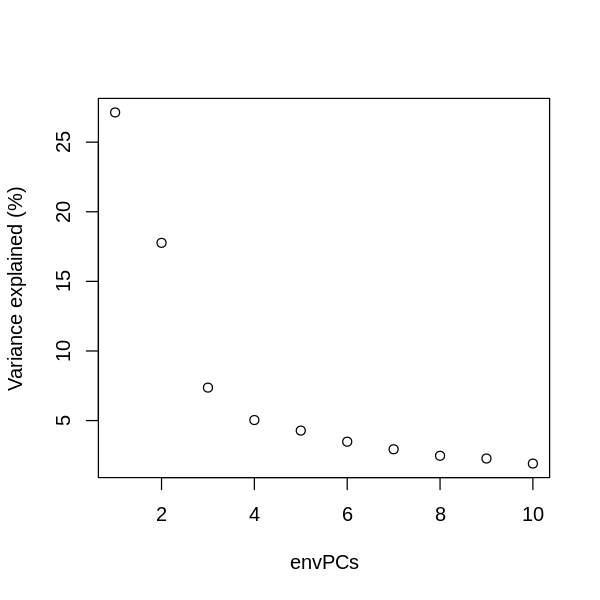

In [315]:
options(repr.plot.width=5, repr.plot.height=5)

plot(ePCs$variance.explained.by.eigen[1:10,2],xlab = 'envPCs',ylab = 'Variance explained (%)')

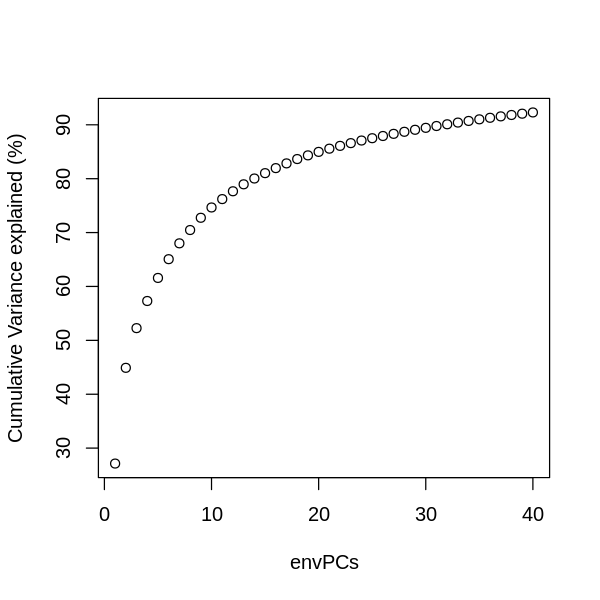

In [16]:
plot(ePCs$variance.explained.by.eigen[,3],xlab = 'envPCs',ylab = 'Cumulative Variance explained (%)')

In [17]:
ePCs$variance.explained.by.eigen

,eigenvalue,explained_variance,cumulative_explained_variance
,<dbl>,<dbl>,<dbl>
envPC_1,76.5173566,27.1338144,27.13381
envPC_2,50.0971546,17.7649485,44.89876
envPC_3,20.7745231,7.3668522,52.26562
envPC_4,14.2035098,5.0367056,57.30232
envPC_5,12.0689615,4.2797736,61.58209
envPC_6,9.8175847,3.4814130,65.06351
envPC_7,8.2872822,2.9387526,68.00226
envPC_8,6.9663599,2.4703404,70.47260
envPC_9,6.4109554,2.2733884,72.74599


In [14]:
dim(ePCs$environmental.features)

[1] 766 325

png 
  2

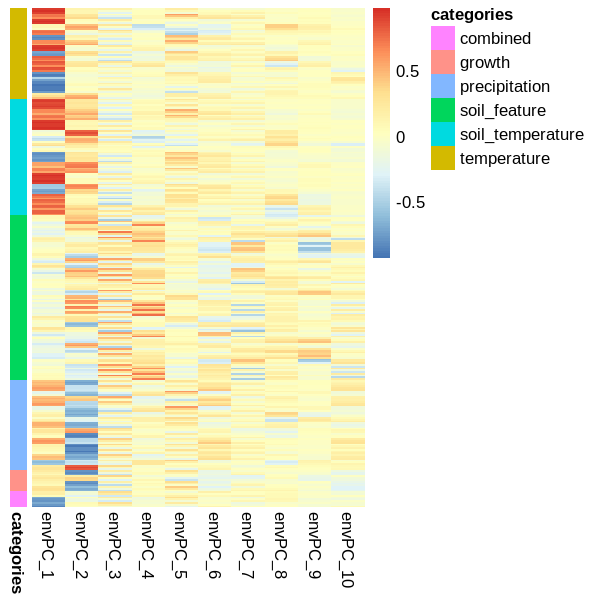

png 
  2

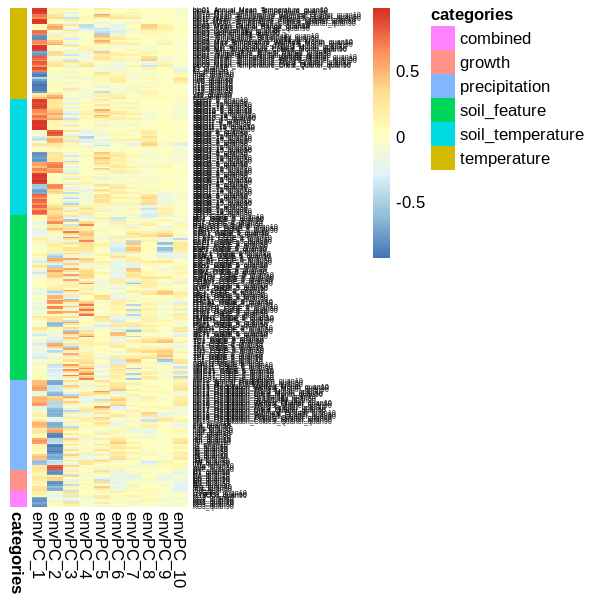

In [15]:
env_metadata = read.table("/workdir/sh2246/p_phyloGWAS/data/env_metadata.txt",sep ="\t",header = T)
ePC_loading_labels = data.frame(categories = rep(env_metadata[,3],each = 3))
rownames(ePC_loading_labels) = paste(rep(env_metadata[,1],each = 3),c("quan10","quan50","quan90"),sep = "_")
envp = pheatmap(na.omit(ePCs$variable.correlation[order(ePC_loading_labels$categories,decreasing = T),1:10]),cluster_rows = F,cluster_cols = F,show_rownames = F,annotation_row = ePC_loading_labels)

png("/workdir/sh2246/p_phyloGWAS/output/envPC_loading.png",width = 16,height = 16, units = "cm",res = 600,pointsize = 8)
envp
dev.off()

envp2 = pheatmap(na.omit(ePCs$variable.correlation[order(ePC_loading_labels$categories,decreasing = T),1:10]),cluster_rows = F,cluster_cols = F,show_rownames = T,annotation_row = ePC_loading_labels,fontsize_row = 4)
png("/workdir/sh2246/p_phyloGWAS/output/envPC_loading_withName.png",width = 20,height = 30, units = "cm",res = 600,pointsize = 8)
envp2
dev.off()

 [1] "bio01_Annual_Mean_Temperature_quan50"         
 [2] "bio11_Mean_Temperature_Coldest_Quarter_quan50"
 [3] "ndr_quan50"                                   
 [4] "ri2_quan50"                                   
 [5] "rid_quan50"                                   
 [6] "wde_quan50"                                   
 [7] "SBIO11_5_quan50"                              
 [8] "SBIO11_15_quan50"                             
 [9] "SBIO2_5_quan50"                               
[10] "SBIO6_5_quan50"                               
 [1] "CEC1_GSDE_5_quan10"   "CLAY1_GSDE_5_quan10"  "PHCA1_GSDE_5_quan90" 
 [4] "PHH2O1_GSDE_5_quan90" "PHK1_GSDE_5_quan90"   "VMC11_GSDE_5_quan10" 
 [7] "VMC21_GSDE_5_quan10"  "VMC21_GSDE_5_quan90"  "VMC31_GSDE_5_quan10" 
[10] "VMC31_GSDE_5_quan90" 


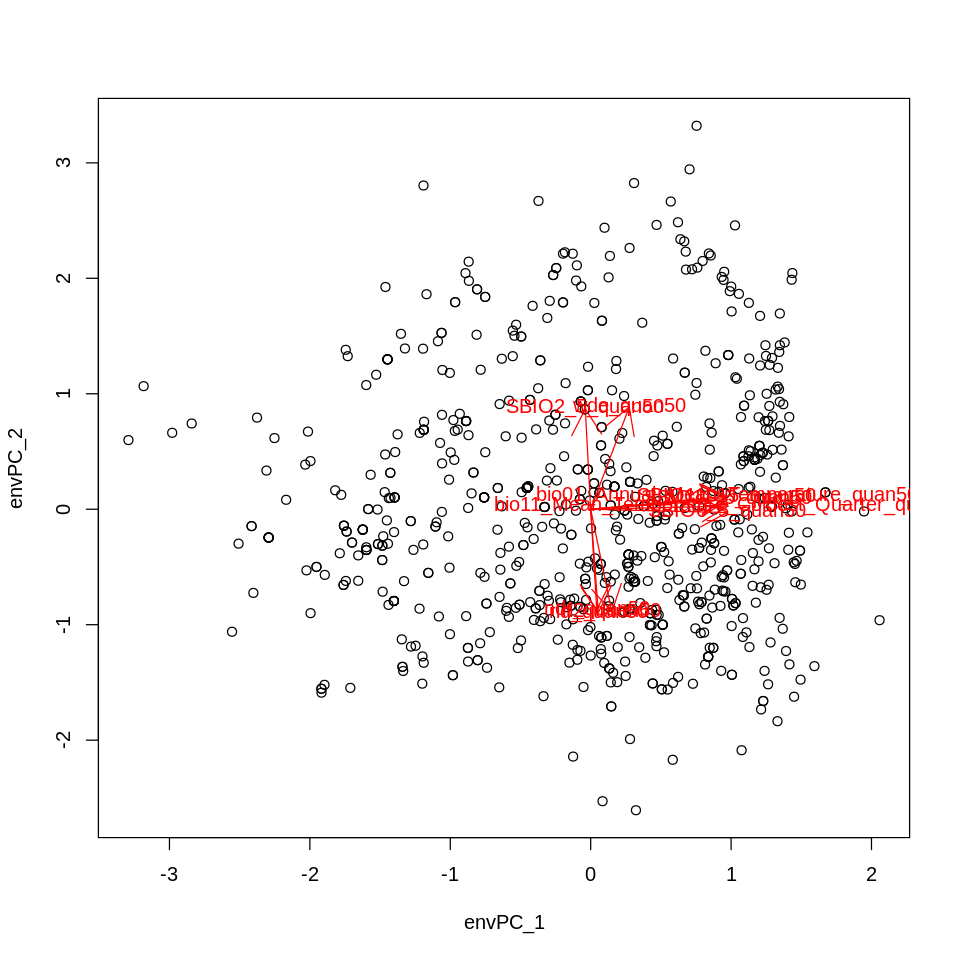

 [1] "bio10_Mean_Temperature_Warmest_Quarter_quan10"
 [2] "bio13_Precipitation_Wettest_Month_quan90"     
 [3] "bio14_Precipitation_Driest_Month_quan10"      
 [4] "bio16_Precipitation_Wettest_Quarter_quan90"   
 [5] "bio17_Precipitation_Driest_Quarter_quan10"    
 [6] "bio05_Max_Temperature_Warmest_Month_quan10"   
 [7] "rfm_quan90"                                   
 [8] "SBIO10_5_quan10"                              
 [9] "SILT1_GSDE_5_quan10"                          
[10] "SILT1_GSDE_5_quan50"                          


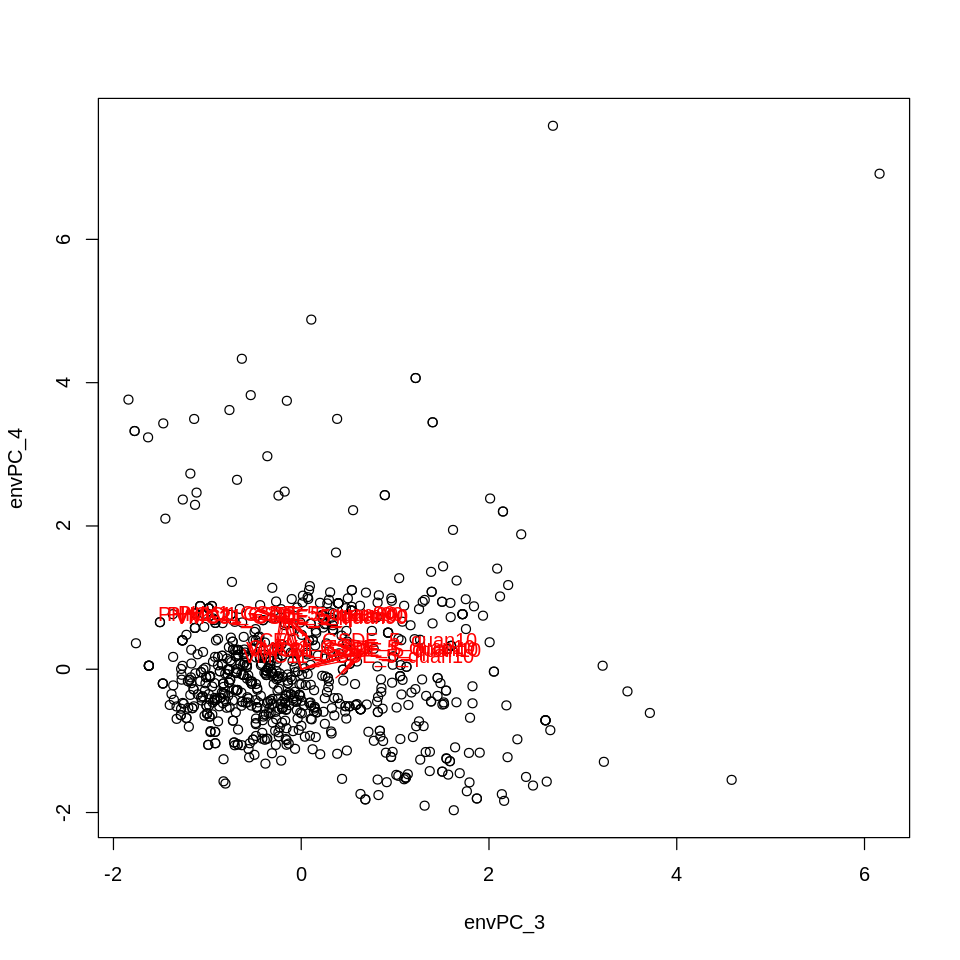

 [1] "bio19_Precipitation_Coldest_Quarter_quan90"   
 [2] "bio02_Mean_Diurnal_Range_quan10"              
 [3] "bio02_Mean_Diurnal_Range_quan50"              
 [4] "bio08_Mean_Temperature_Wettest_Quarter_quan90"
 [5] "SBIO9_5_quan90"                               
 [6] "GRAV1_GSDE_5_quan90"                          
 [7] "SAND1_GSDE_5_quan90"                          
 [8] "VMC11_GSDE_5_quan90"                          
 [9] "VMC21_GSDE_5_quan90"                          
[10] "VMC31_GSDE_5_quan90"                          


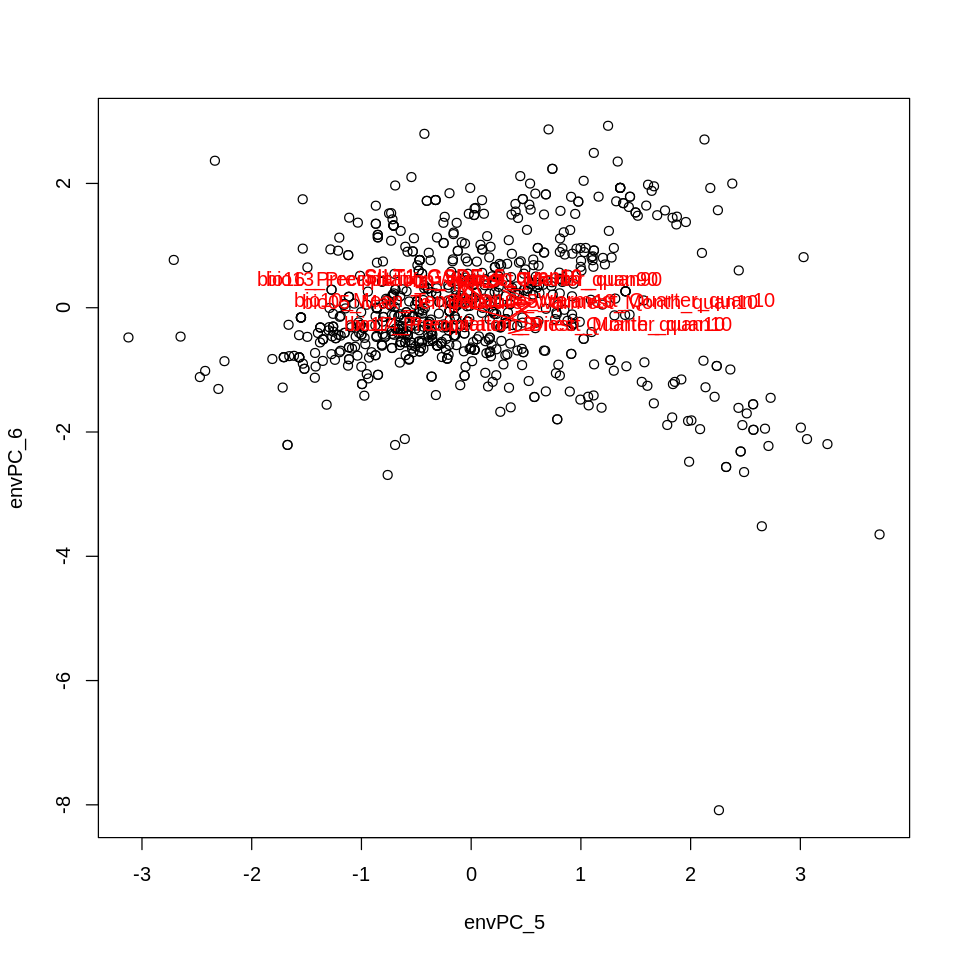

 [1] "SBIO3_5_quan90"      "CLAY1_GSDE_5_quan50" "ECE1_GSDE_5_quan10" 
 [4] "ECE1_GSDE_5_quan50"  "ESP1_GSDE_5_quan10"  "ESP1_GSDE_5_quan50" 
 [7] "TS1_GSDE_5_quan10"   "VMC11_GSDE_5_quan50" "VMC21_GSDE_5_quan50"
[10] "VMC31_GSDE_5_quan50"


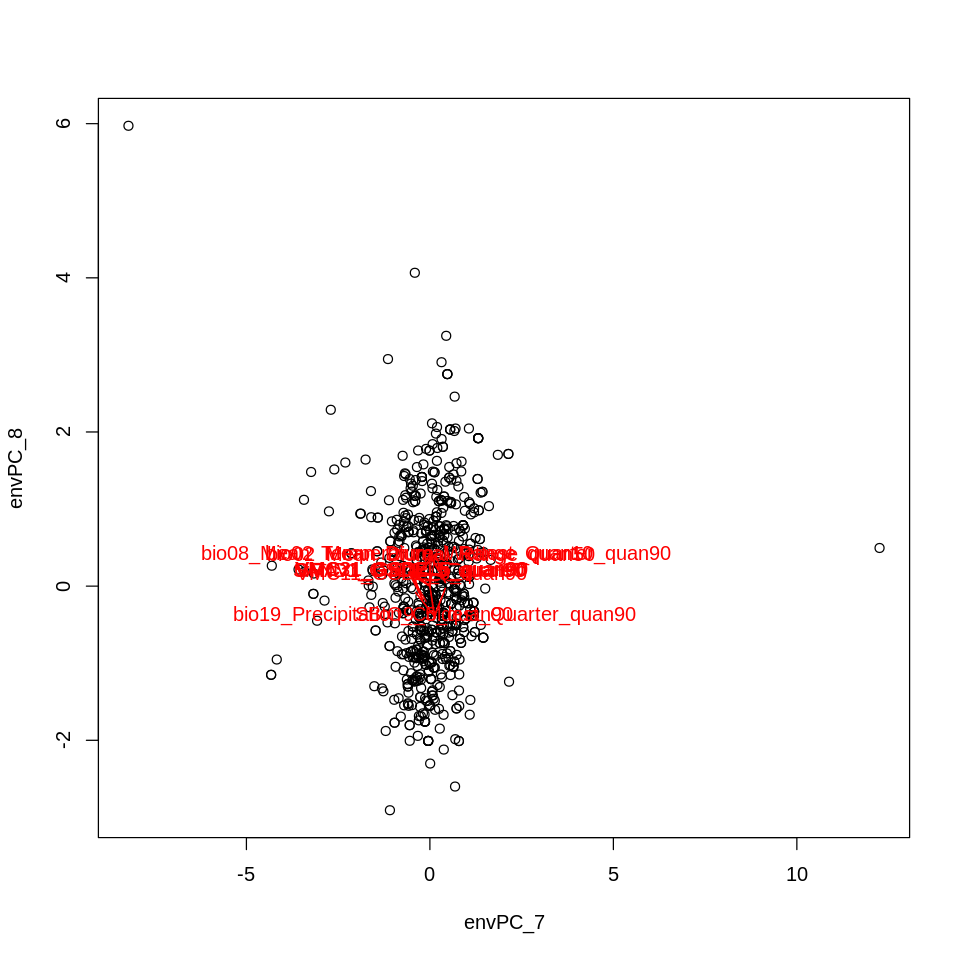

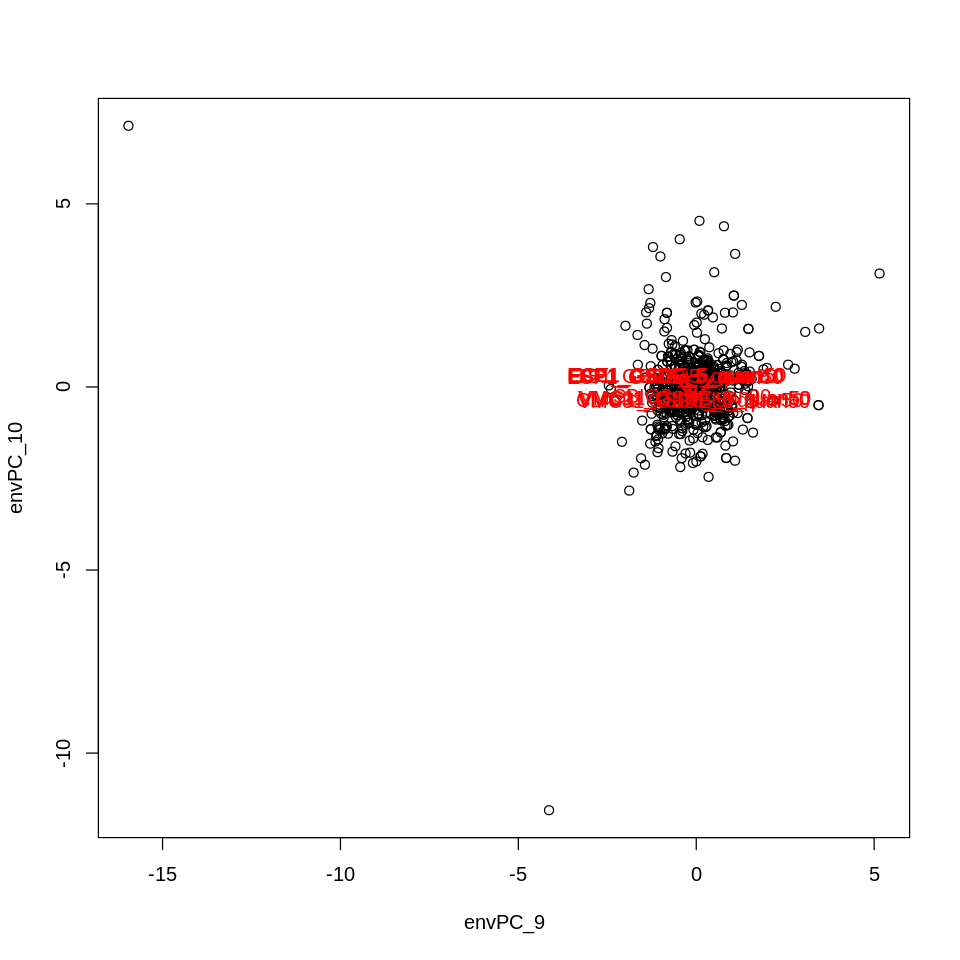

In [47]:
options(repr.plot.width=8, repr.plot.height=8)

for(i in seq(1,9,2)){
    topVar = which(rank(ePCs$variable.correlation[,i]^2,na.last = F) > 280 |rank(ePCs$variable.correlation[,i+1]^2,na.last = F) > 280)
    print(rownames(ePCs$variable.correlation)[topVar])
    plot(ePCs$synthetic.environmental.traits[,i:(i+1)])
    arrows(x0 = rep(0,length(topVar)),y0 = rep(0,length(topVar)),
           x1 = ePCs$variable.components[topVar,i],
           y1 = ePCs$variable.components[topVar,i+1],col = "red")
    text(ePCs$variable.components[topVar,i:(i+1)],
         rownames(ePCs$variable.correlation)[topVar],col = "red")
}


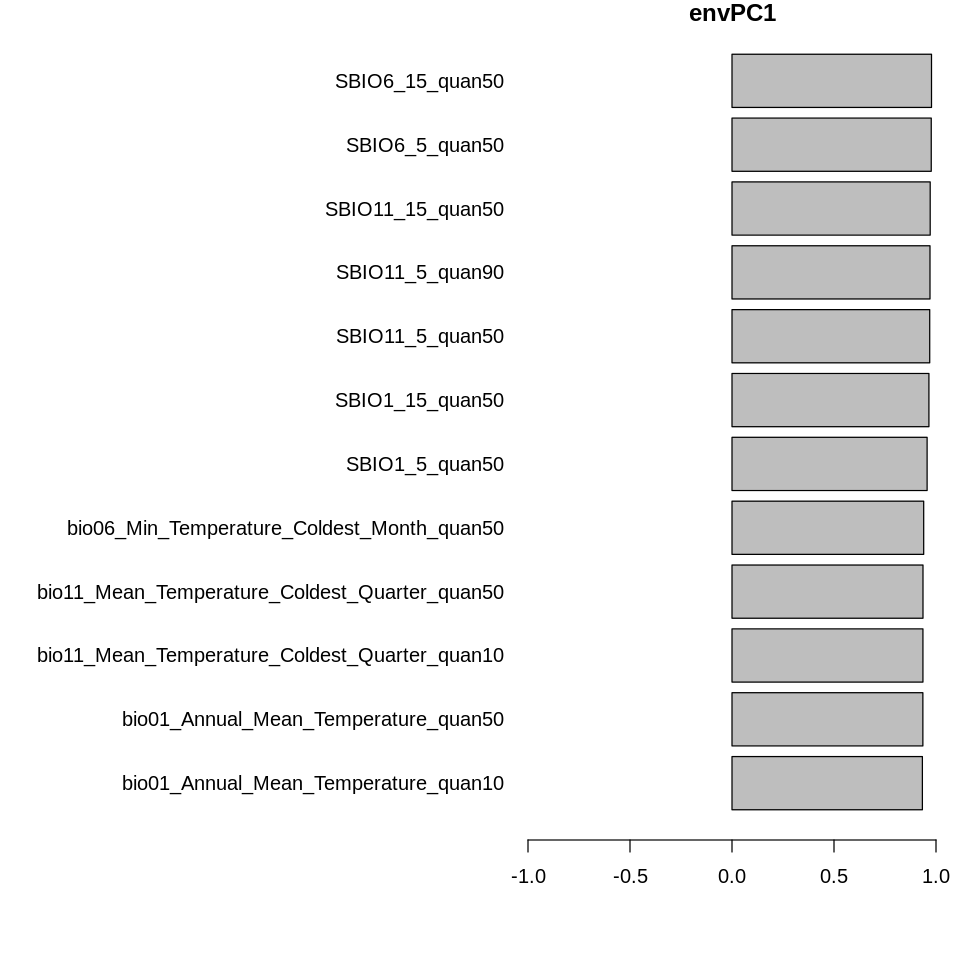

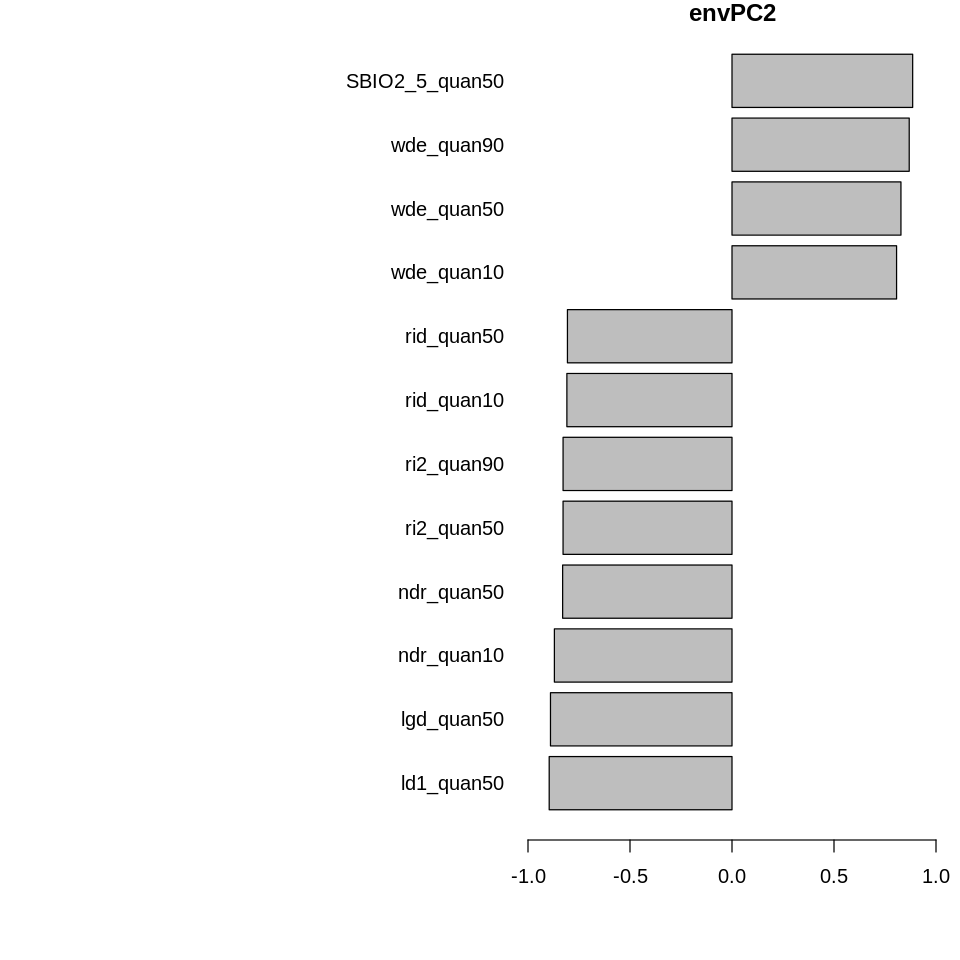

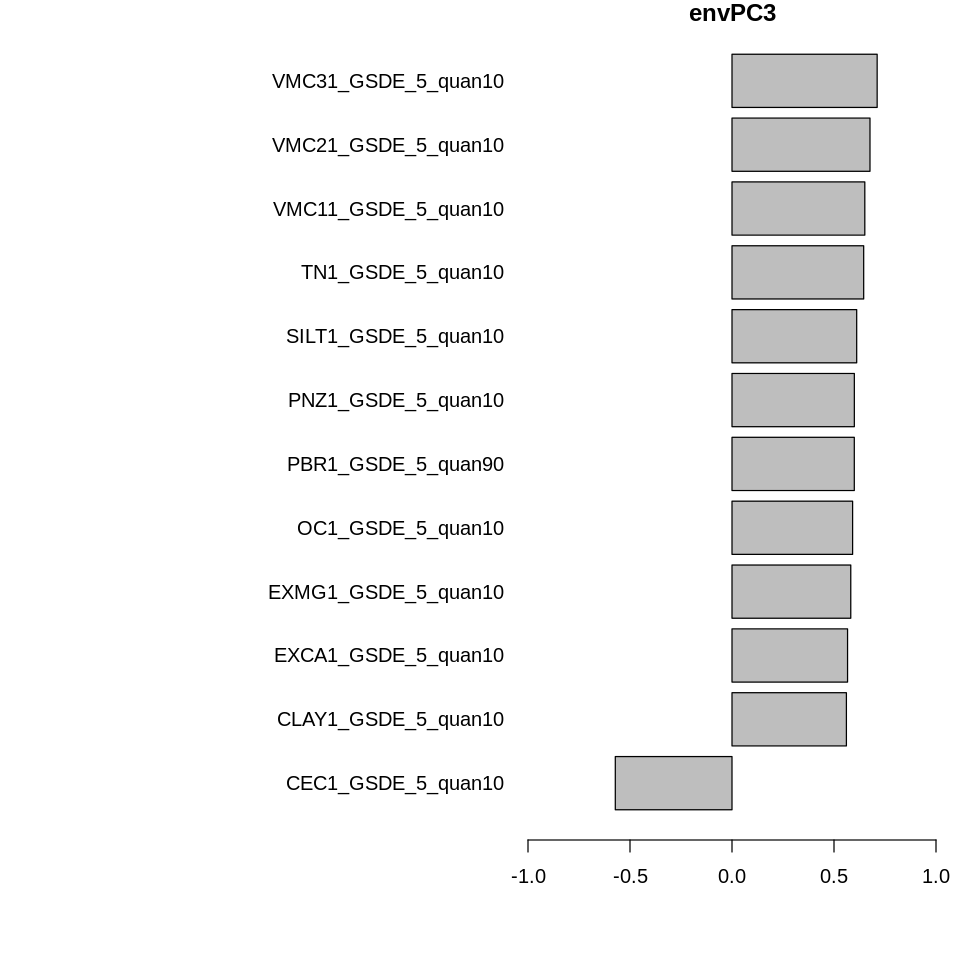

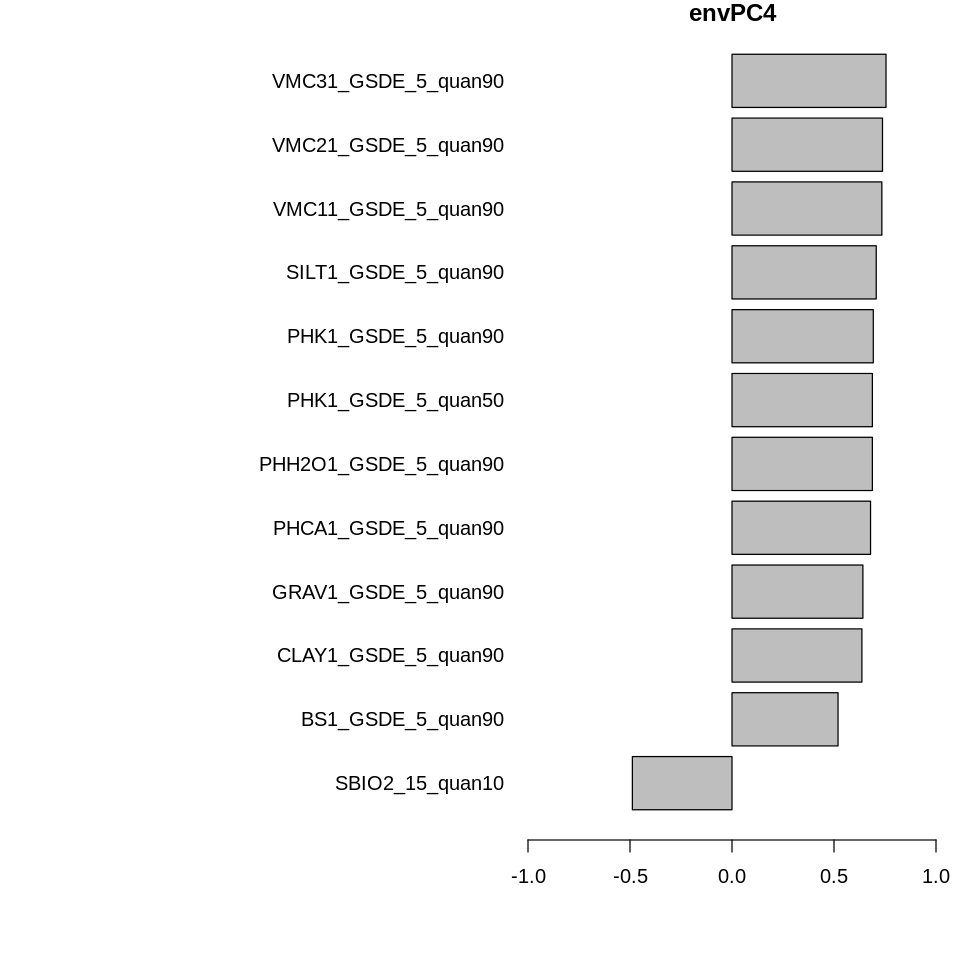

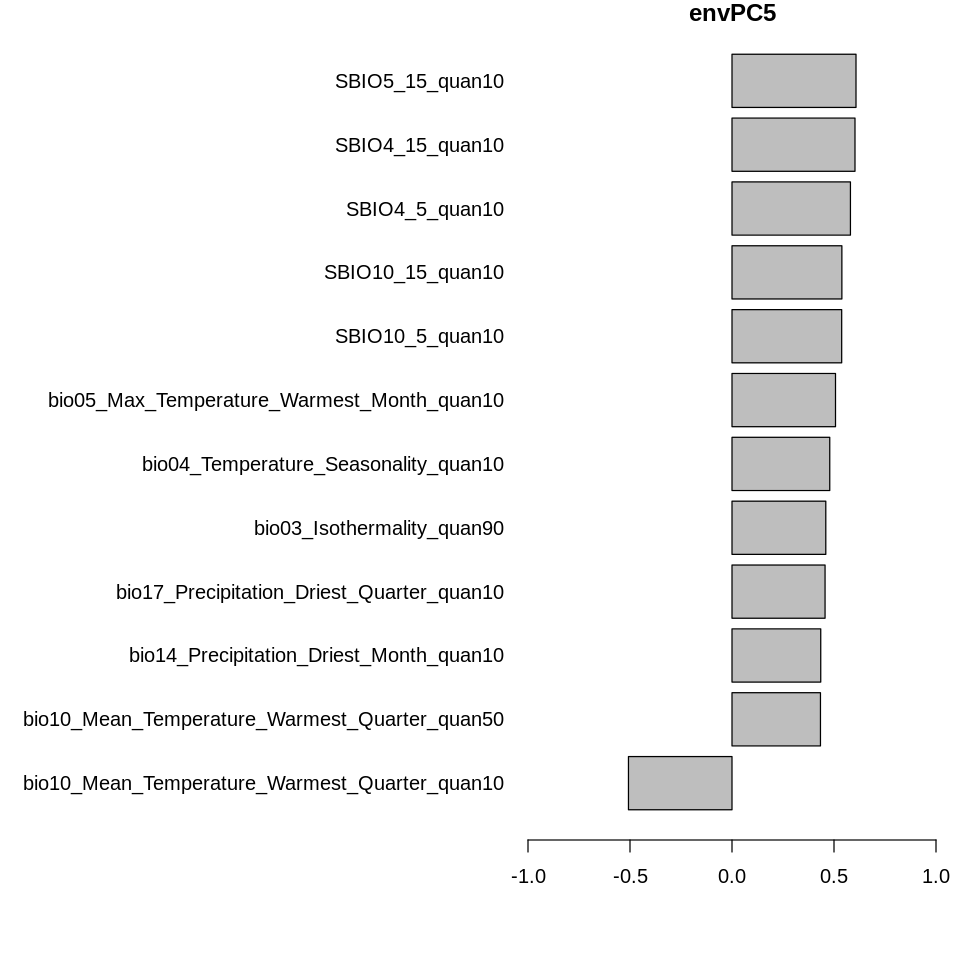

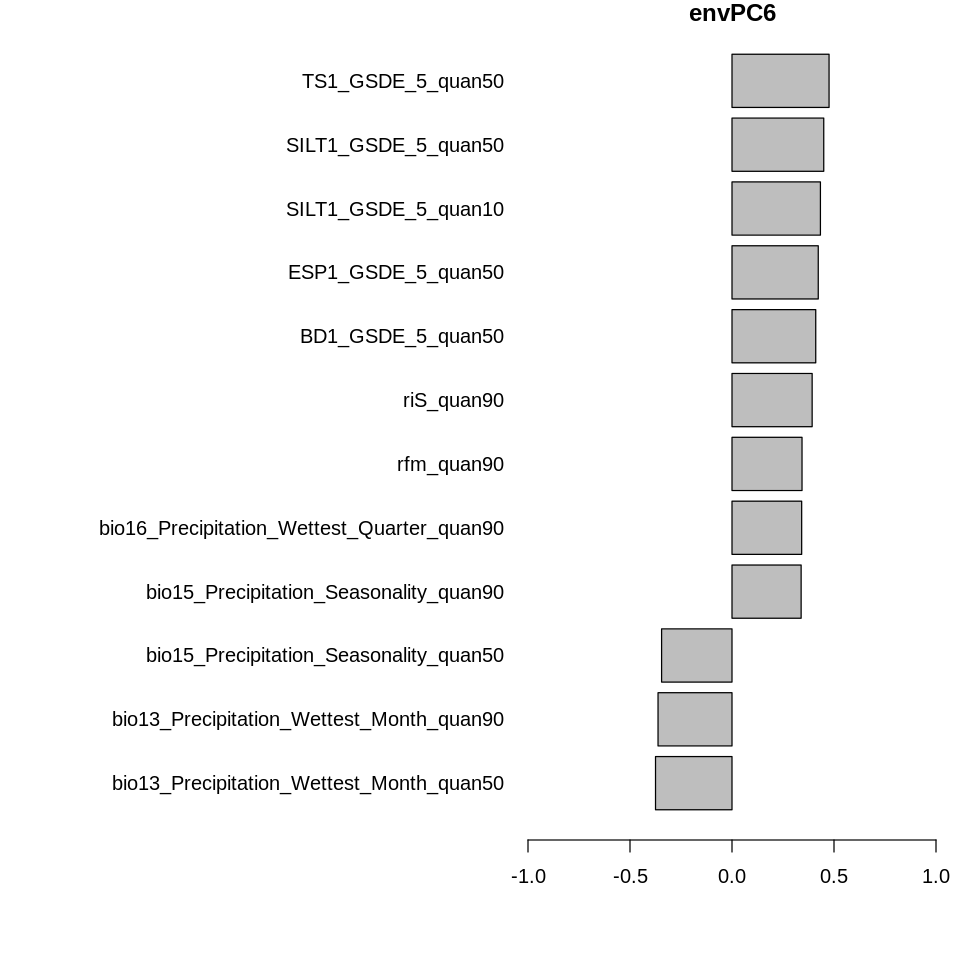

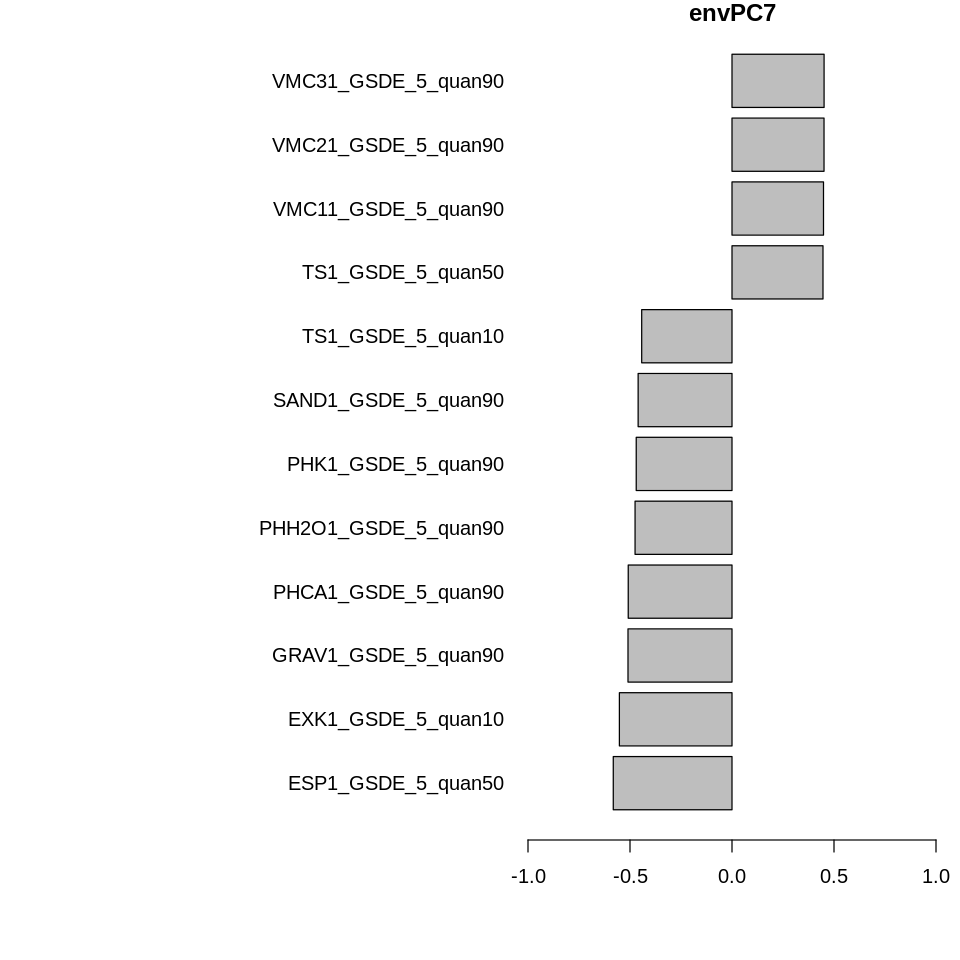

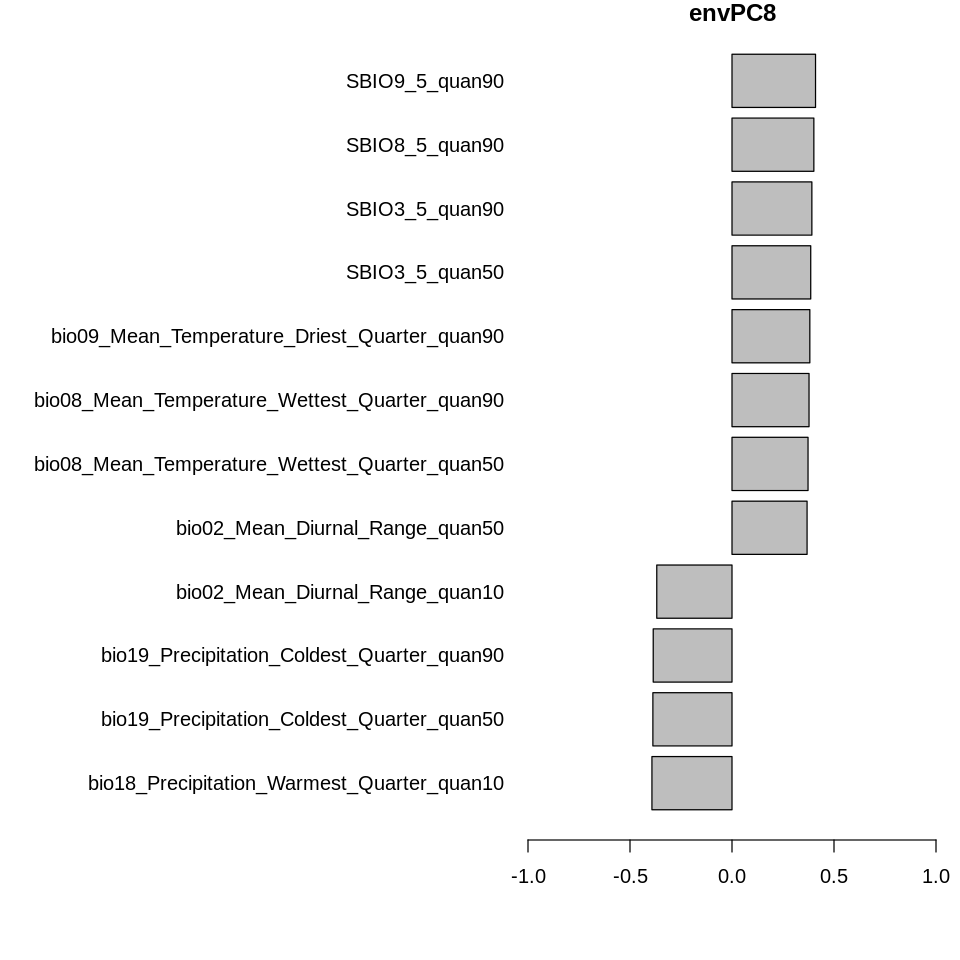

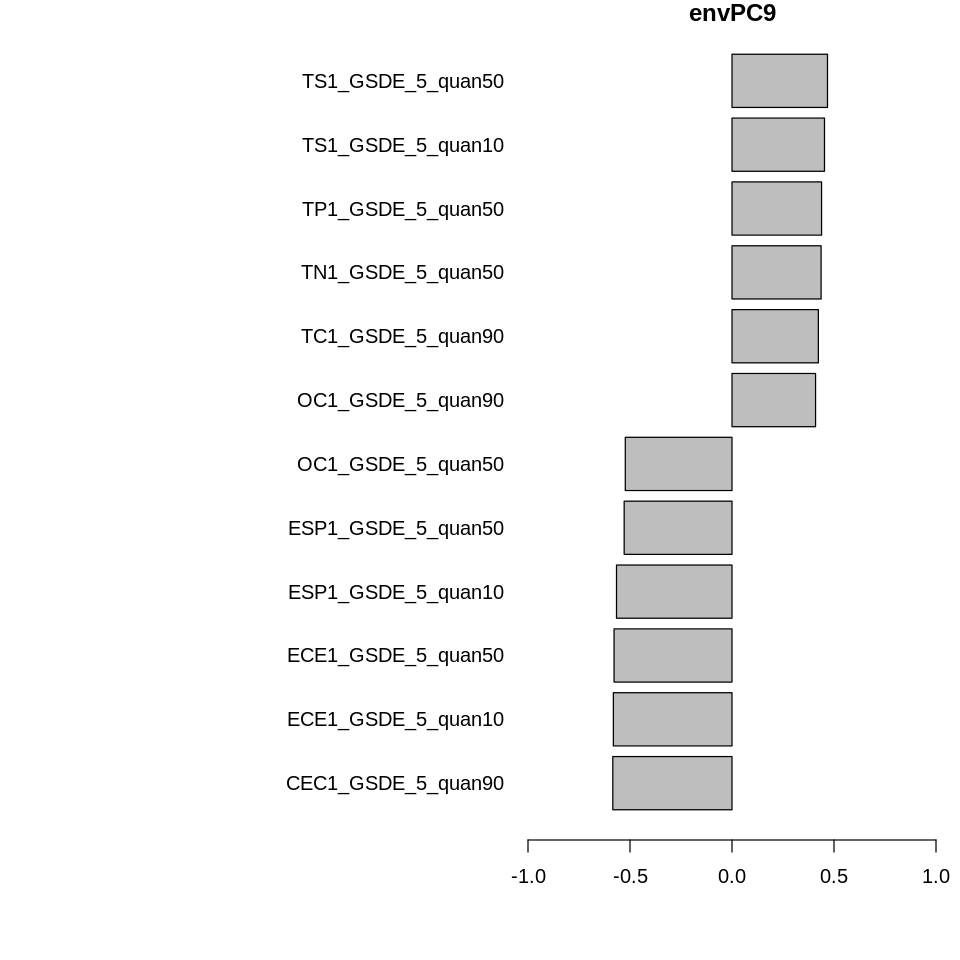

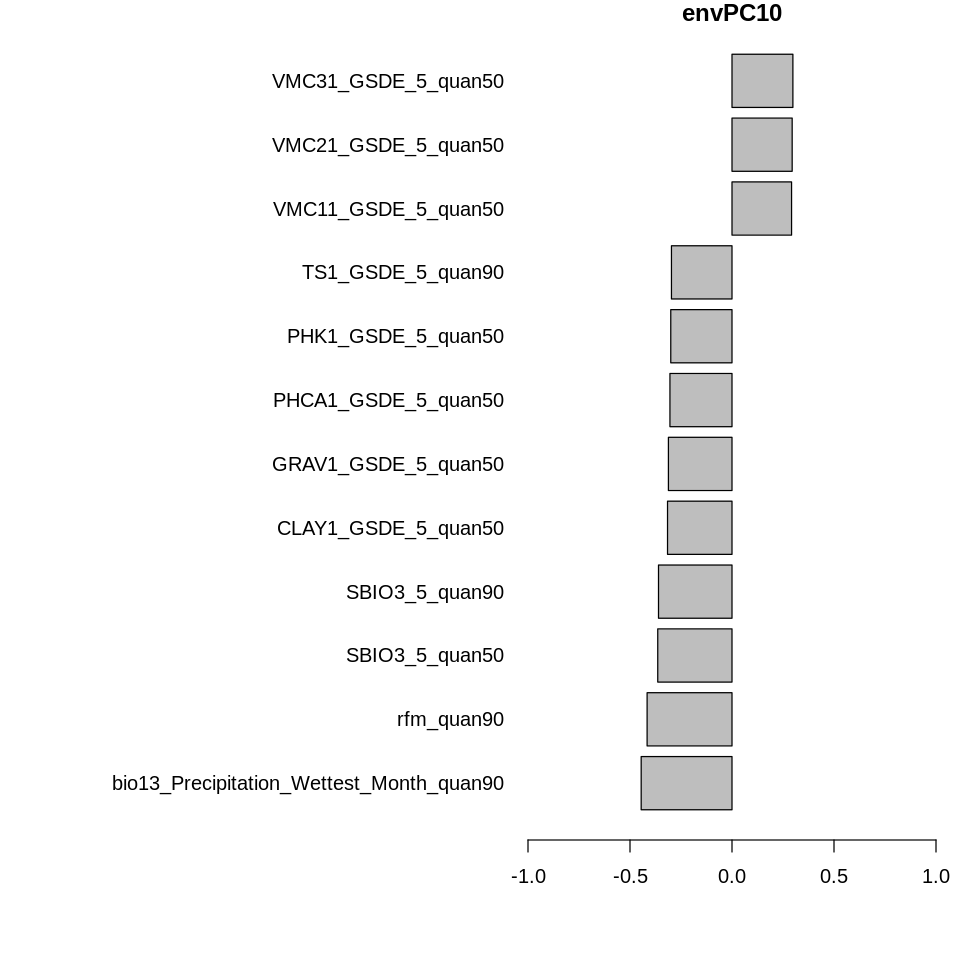

In [92]:
options(repr.plot.width=8, repr.plot.height=8)
par(mar = c(5,22,1,1))
for(i in 1:10){
    topVar = which(rank(ePCs$variable.correlation[,i]^2,na.last = F) > 273)
    barplot(sort(ePCs$variable.components[topVar,i]),main = paste0("envPC",i),horiz = T,
            names.arg = rownames(ePCs$variable.correlation)[topVar],las =1,xlim = c(-1,1))
}


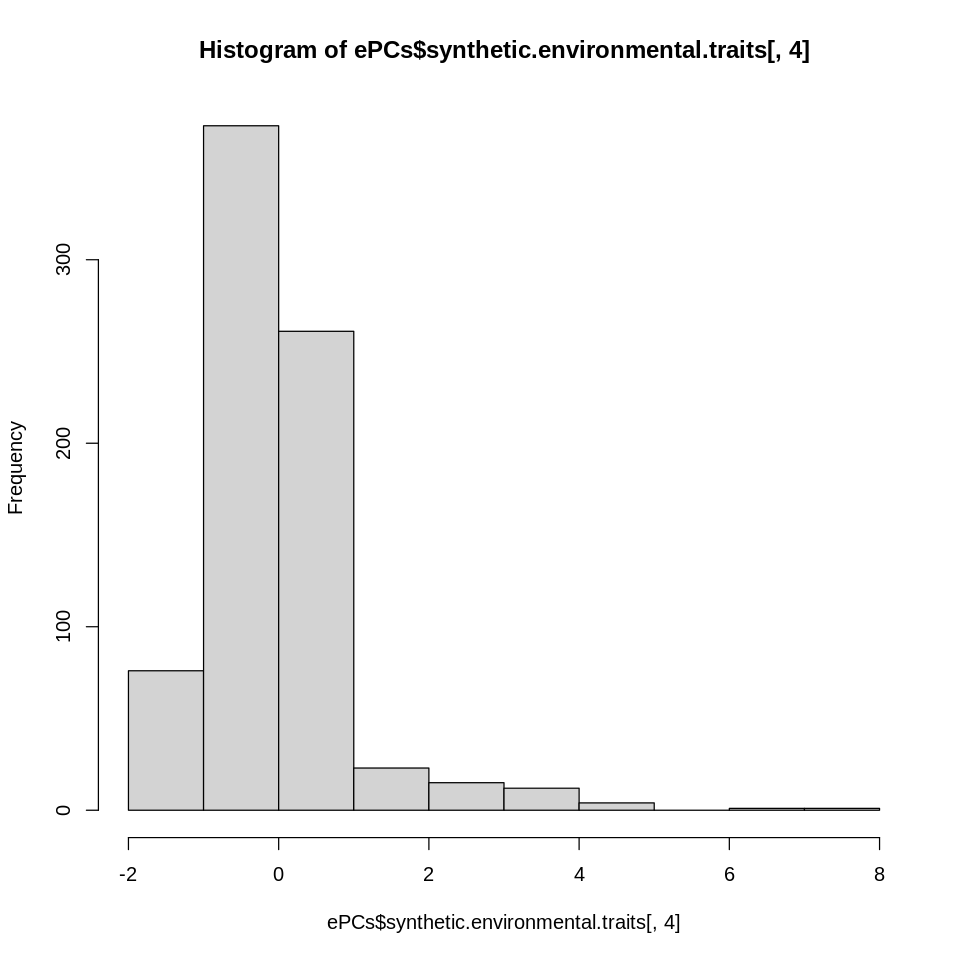

In [51]:
hist(ePCs$synthetic.environmental.traits[,4])

In [41]:
sort(ePCs$variable.correlation[,1]^2)
ePCs$variable.correlation[,1][rank(ePCs$variable.correlation[,1]^2)>280]

[1] 0.0000063001 0.0000197136 0.0000198025 0.0001006009 0.0001630729
  [6] 0.0001737124 0.0002059225 0.0002114116 0.0002408704 0.0002948089
 [11] 0.0003161284 0.0003359889 0.0003367225 0.0003467044 0.0004405801
 [16] 0.0004622500 0.0005602689 0.0006180196 0.0007236100 0.0011316496
 [21] 0.0012446784 0.0013126129 0.0013315201 0.0014699556 0.0014984641
 [26] 0.0018766224 0.0019377604 0.0022534009 0.0022553001 0.0024970009
 [31] 0.0024990001 0.0025070049 0.0027196225 0.0029593600 0.0031640625
 [36] 0.0032421636 0.0035141184 0.0035366809 0.0036324729 0.0036372961
 [41] 0.0044435556 0.0048094225 0.0053949025 0.0055428025 0.0058216900
 [46] 0.0058430736 0.0059136100 0.0061214976 0.0071791729 0.0072114064
 [51] 0.0077810041 0.0078765625 0.0078818884 0.0090801841 0.0093760489
 [56] 0.0095374756 0.0096079204 0.0097752769 0.0099062209 0.0100460529
 [61] 0.0102394161 0.0106131204 0.0111915241 0.0115175824 0.0119508624
 [66] 0.0120362841 0.0131492089 0.0136936804 0.0137053849 0.0137522529
 [71] 0.0141491025 0.0143496441 0.0148376761 0.0157276681 0.0159668496
 [76] 0.0162205696 0.0164839921 0.0169885156 0.0173949721 0.0178703424
 [81] 0.0186759556 0.0187881849 0.0189805729 0.0191656336 0.0192044164
 [86] 0.0209033764 0.0217621504 0.0227346084 0.0228191236 0.0245548900
 [91] 0.0245862400 0.0250209124 0.0259660996 0.0268861609 0.0270372249
 [96] 0.0276823044 0.0280998169 0.0282105616 0.0285136996 0.0295496100
[101] 0.0314211076 0.0316697616 0.0318444025 0.0324828529 0.0326163600
[106] 0.0357285604 0.0366607609 0.0368832025 0.0383298084 0.0383415561
[111] 0.0387341761 0.0393585921 0.0397683364 0.0399000625 0.0410953984
[116] 0.0412090000 0.0414244609 0.0430853049 0.0459888025 0.0470933401
[121] 0.0472323289 0.0476941921 0.0546390625 0.0602997136 0.0650403009
[126] 0.0650913169 0.0653824900 0.0665640000 0.0687750625 0.0717061284
[131] 0.0718561636 0.0754326225 0.0762753924 0.0764080164 0.0766016329
[136] 0.0771061824 0.0772172944 0.0839724484 0.0841696144 0.0951722500
[141] 0.1009459984 0.1024640100 0.1028100096 0.1055015361 0.1078794025
[146] 0.1080765625 0.1108623616 0.1147041424 0.1230395929 0.1344835584
[151] 0.1425817600 0.1462297600 0.1826194756 0.1869178756 0.1872639076
[156] 0.2020412601 0.2038612801 0.2062613056 0.2071615225 0.2124472464
[161] 0.2140265169 0.2171746404 0.2206086961 0.2469891204 0.2560866025
[166] 0.2615197321 0.2618573584 0.2635384896 0.2707016841 0.2728495225
[171] 0.2792171281 0.2859896484 0.2871352225 0.2880361561 0.2905102201
[176] 0.2952944281 0.2983016689 0.2996029696 0.3083247729 0.3132640900
[181] 0.3259496464 0.3270352969 0.3447098944 0.3452620081 0.3475927849
[186] 0.3540012004 0.3696153616 0.3791726929 0.3844248004 0.4022603776
[191] 0.4042925056 0.4085510724 0.4154962681 0.4176132129 0.4247650276
[196] 0.4351249296 0.4415203809 0.4455162009 0.4485516676 0.4641833161
[201] 0.4652467681 0.4682664900 0.4809006409 0.4828721121 0.5007119121
[206] 0.5010233089 0.5041568016 0.5058054400 0.5082264100 0.5148206001
[211] 0.5253205441 0.5283836100 0.5313681025 0.5363951121 0.5422702321
[216] 0.5468010916 0.5547419361 0.5642563689 0.5643465129 0.5672349225
[221] 0.5705989444 0.5743214656 0.5809945729 0.5814062500 0.5827337569
[226] 0.5841544900 0.5895014841 0.5940555625 0.6064048384 0.6067007881
[231] 0.6115865616 0.6218426449 0.6266463921 0.6347786929 0.6357510756
[236] 0.6377619600 0.6411525184 0.6440062500 0.6471237136 0.6473972521
[241] 0.6592465636 0.6661497924 0.6990130449 0.7001840329 0.7005020416
[246] 0.7021434436 0.7198164964 0.7203086641 0.7445964100 0.7613260516
[251] 0.7664827401 0.7683574336 0.7684801569 0.7724652100 0.7737841225
[256] 0.7894500201 0.7962528289 0.7971632656 0.8232477289 0.8279362081
[261] 0.8347015044 0.8462160100 0.8464552009 0.8492359716 0.8508033121
[266] 0.8537944801 0.8609056225 0.8638029481 0.8666865216 0.8705636416
[271] 0.8709742276 0.8754596356 0.8760772801 0.8765266129 0.8829609156
[276] 0.9147583449 0.9318233961 0.9393680241 0.9420061249 0.9438899716
[281] 0.9539819584 0.95642

[1] 0.97797     NaN     NaN     NaN 0.97672

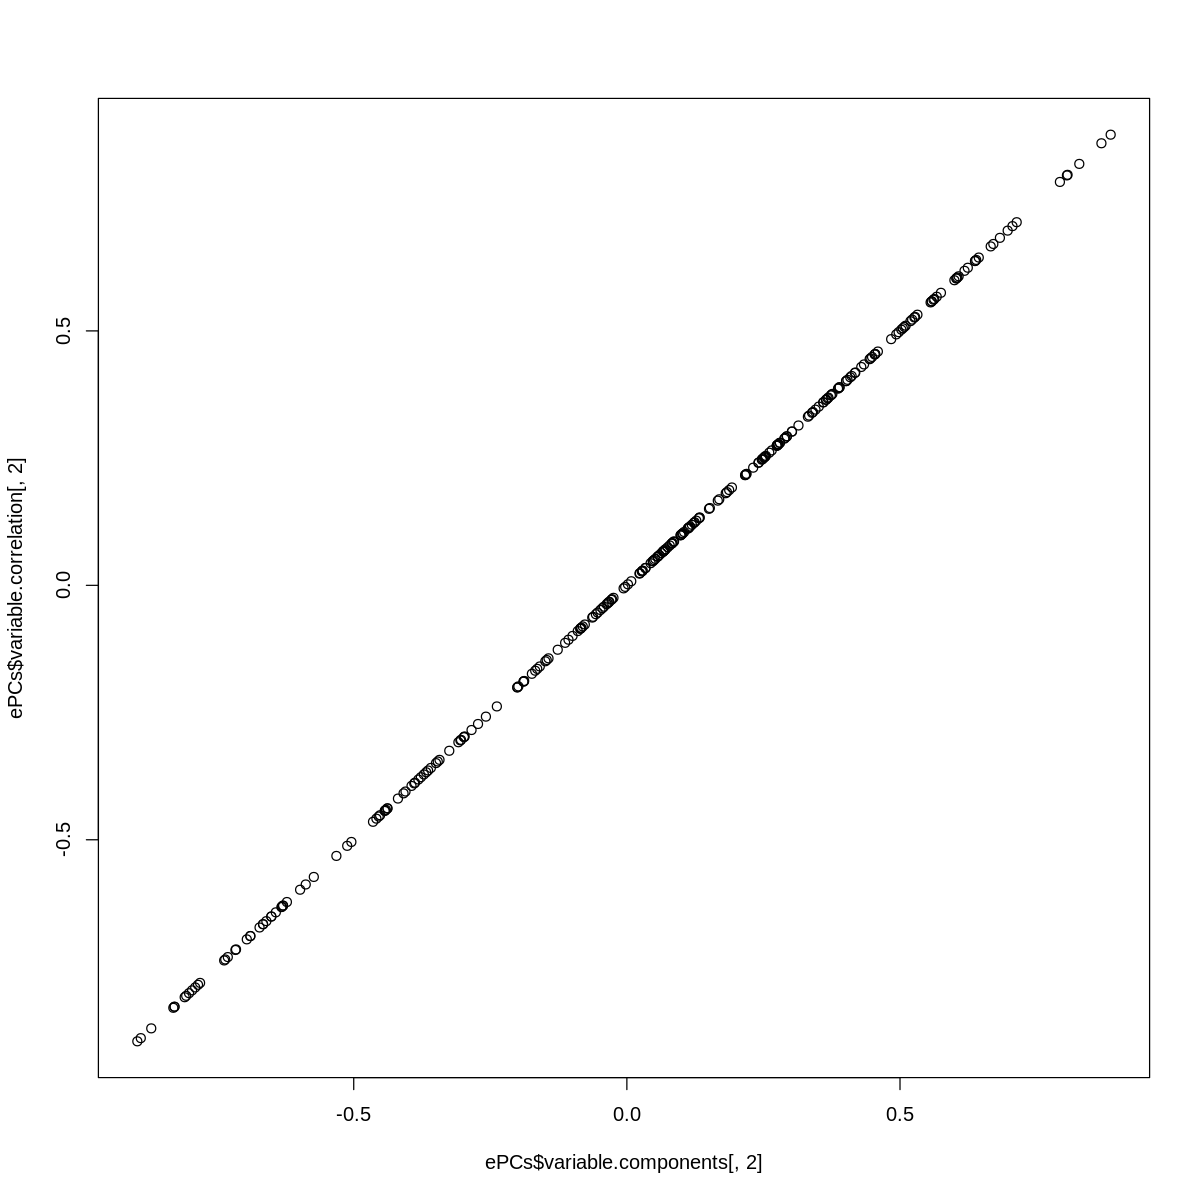

In [20]:
plot(ePCs$variable.components[,2],ePCs$variable.correlation[,2])

In [23]:
ePCs$variable.contribution[order(ePCs$variable.correlation[,2]^2,decreasing = T),1:4]

,envPC_1,envPC_2,envPC_3,envPC_4
,<dbl>,<dbl>,<dbl>,<dbl>
rid_quan50,0.00387,1.60296,0.00573,0.01302
ri2_quan50,0.02971,1.58046,0.02093,0.00225
wde_quan50,0.09858,1.56561,0.03910,0.01772
ndr_quan50,0.00245,1.51311,0.02139,0.11261
SBIO2_5_quan50,0.00192,1.50640,0.00003,0.34734
lgd_quan50,0.01849,1.37585,0.11152,0.06269
wde_quan90,0.10975,1.36915,0.22694,0.00149
ld1_quan50,0.03209,1.36903,0.09433,0.04558
ndr_quan10,0.02154,1.36885,0.29278,0.00447


In [18]:
commonID = intersect(spTre.rooted$tip.label,rownames(ePCs$environmental.features))
eTraits_filtered = as.data.frame(ePCs$environmental.features[commonID,])
spTre.rooted.filtered = keep.tip(spTre.rooted,commonID)

In [65]:
write.tree(spTre.rooted.filtered,"/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral_filtered_20240821.nwk")

In [19]:
table(metadata[metadata[,1]%in%commonID,]$lifeHistory)


             annual annual or perennial           perennial 
                244                   6                 482 

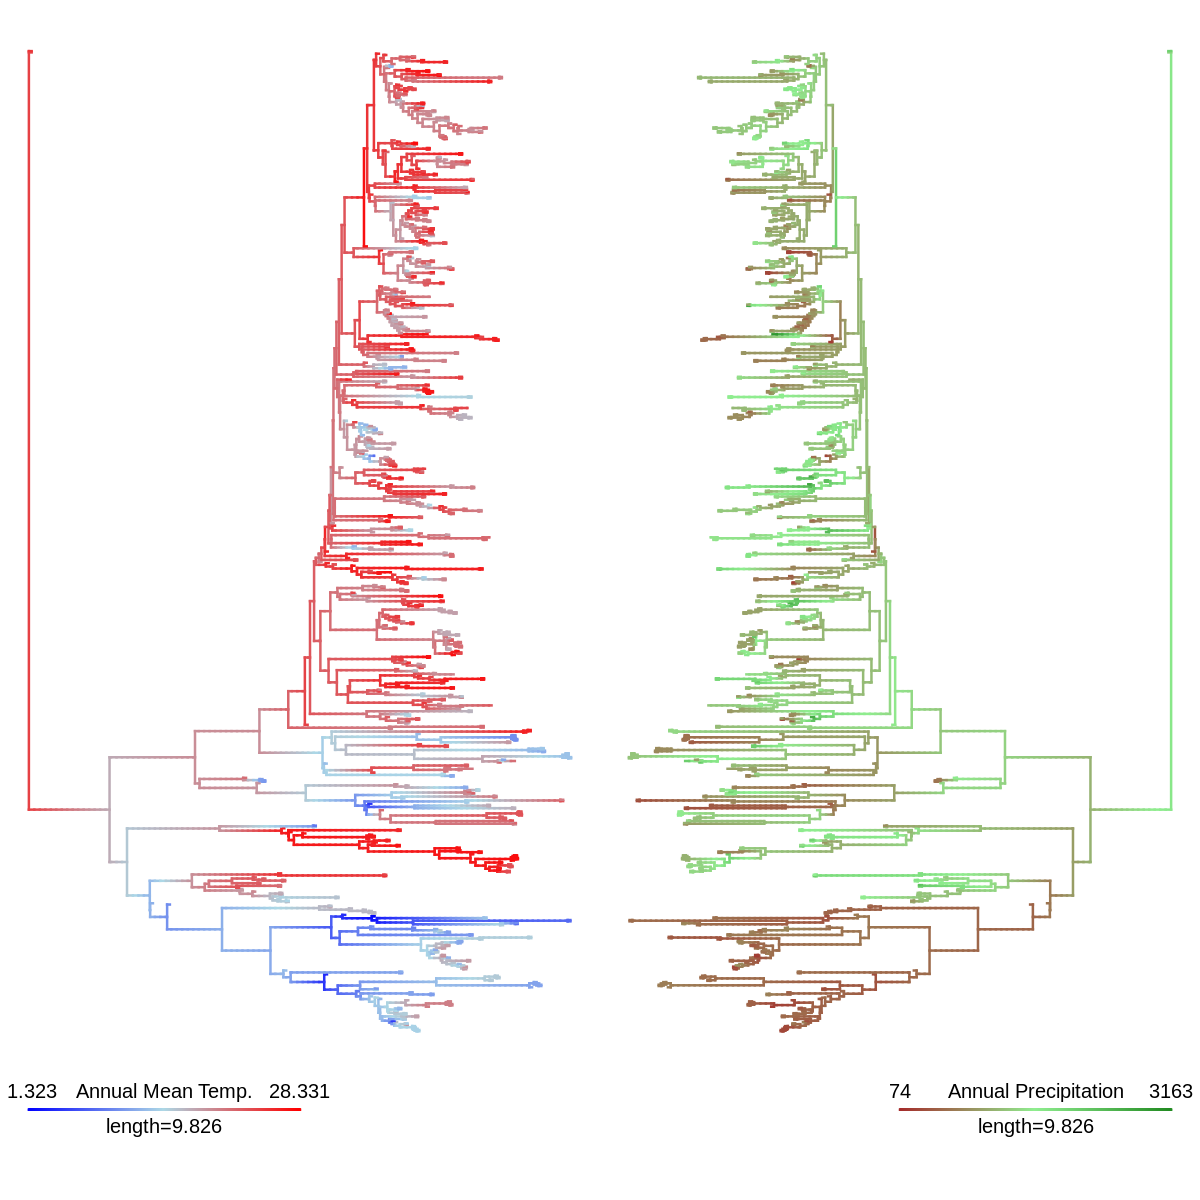

In [20]:
options(repr.plot.width=10, repr.plot.height=10)

par(mfrow = c(1,2))
plotTraitOnTree(eTraits_filtered$bio01_Annual_Mean_Temperature_quan50,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "Annual Mean Temp.",col = c("blue","lightblue","red"))
plotTraitOnTree(eTraits_filtered$bio12_Annual_Precipitation_quan50,
                commonID,spTre.rooted.filtered,visible_tip_labels = F,direction = 'leftwards',
                legend.title = "Annual Precipitation",col = c("brown","lightgreen","forestgreen"))


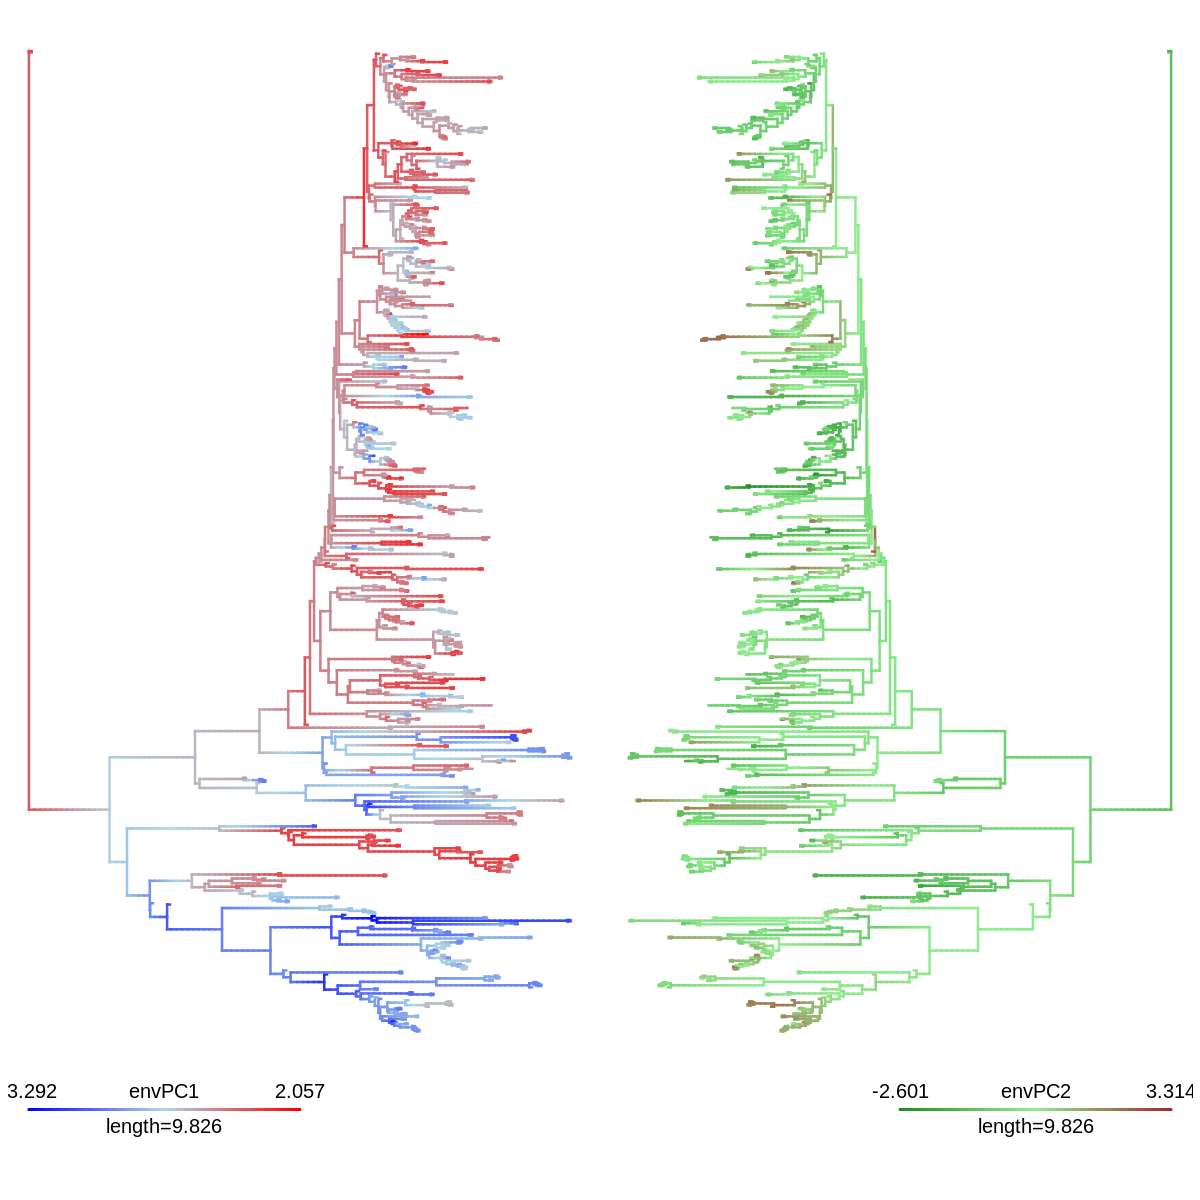

In [58]:
options(repr.plot.width=10, repr.plot.height=10)

par(mfrow = c(1,2))
plotTraitOnTree(ePCs$synthetic.environmental.traits[commonID,1],
                commonID,spTre.rooted.filtered,visible_tip_labels = F,
                legend.title = "envPC1",col = c("blue","lightblue","red"))
plotTraitOnTree(scale(ePCs$synthetic.environmental.traits[commonID,2],center = T,scale = T),
                commonID,spTre.rooted.filtered,visible_tip_labels = F,direction = 'leftwards',
                legend.title = "envPC2",col = c("forestgreen","lightgreen","brown"))


In [61]:
png("/workdir/sh2246/p_phyloGWAS/output/envAdapt_Bio1Quan50_PhyloTree.png",width = 20,height = 80,units = "cm",res = 600,pointsize = 6)
plotTraitOnTree(eTraits_filtered$bio01_Annual_Mean_Temperature_quan50,
                commonID,spTre.rooted.filtered,visible_tip_labels = T,
                legend.title = "Annual Mean Temp.",col = c("blue","lightblue","red"),fontsize = .5)
dev.off()

png 
  2

In [58]:
png("/workdir/sh2246/p_phyloGWAS/output/envAdapt_Bio12Quan50_PhyloTree.png",width = 20,height = 80,units = "cm",res = 600,pointsize = 6)
plotTraitOnTree(eTraits_filtered$bio12_Annual_Precipitation_quan50,
                commonID,spTre.rooted.filtered,visible_tip_labels = T,
                legend.title = "Annual Mean Temp.",col = c("brown","lightgreen","forestgreen"),fontsize = .5)
dev.off()

png 
  2

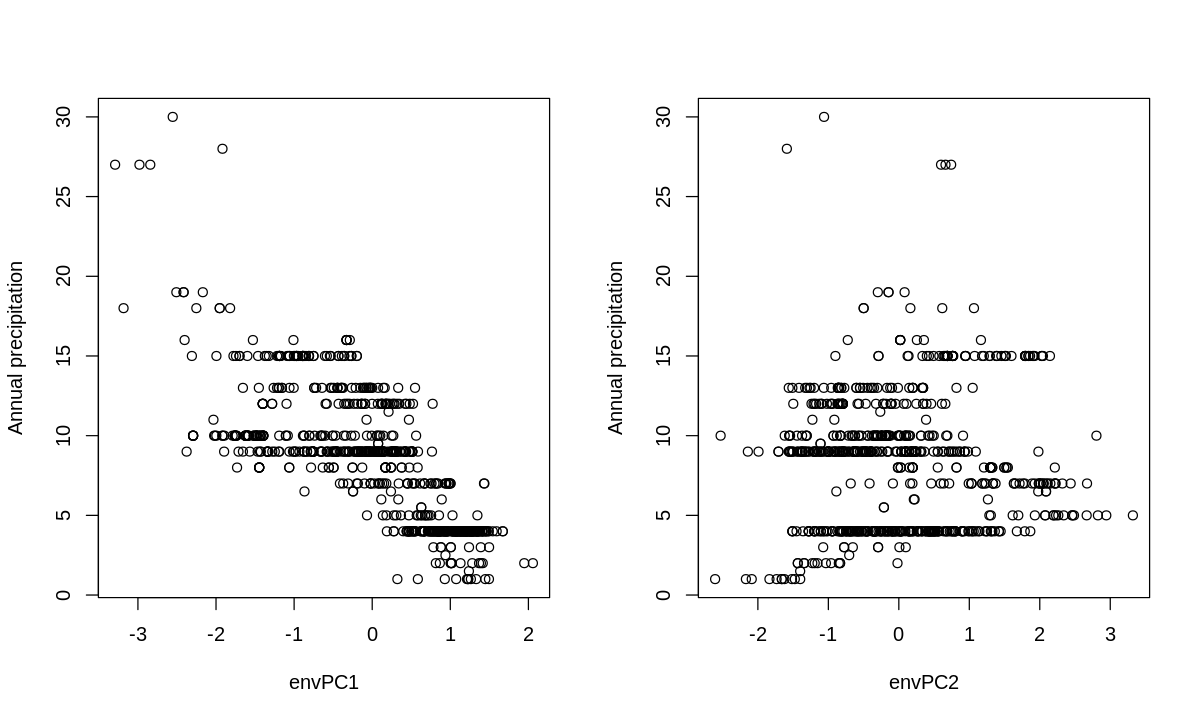

In [61]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
plot(ePCs$synthetic.environmental.traits[,1],
     as.data.frame(ePCs$environmental.features)$KG3_quan50,
     xlab = "envPC1",ylab = "Annual precipitation")
plot(ePCs$synthetic.environmental.traits[,2],
     as.data.frame(ePCs$environmental.features)$KG3_quan50,
     xlab = "envPC2",ylab = "Annual precipitation")

In [71]:
KG3_class = as.data.frame(ePCs$environmental.features)$KG3_quan50

In [74]:
KG3_class[!KG3_class%in%seq(1,31,1)] = NA

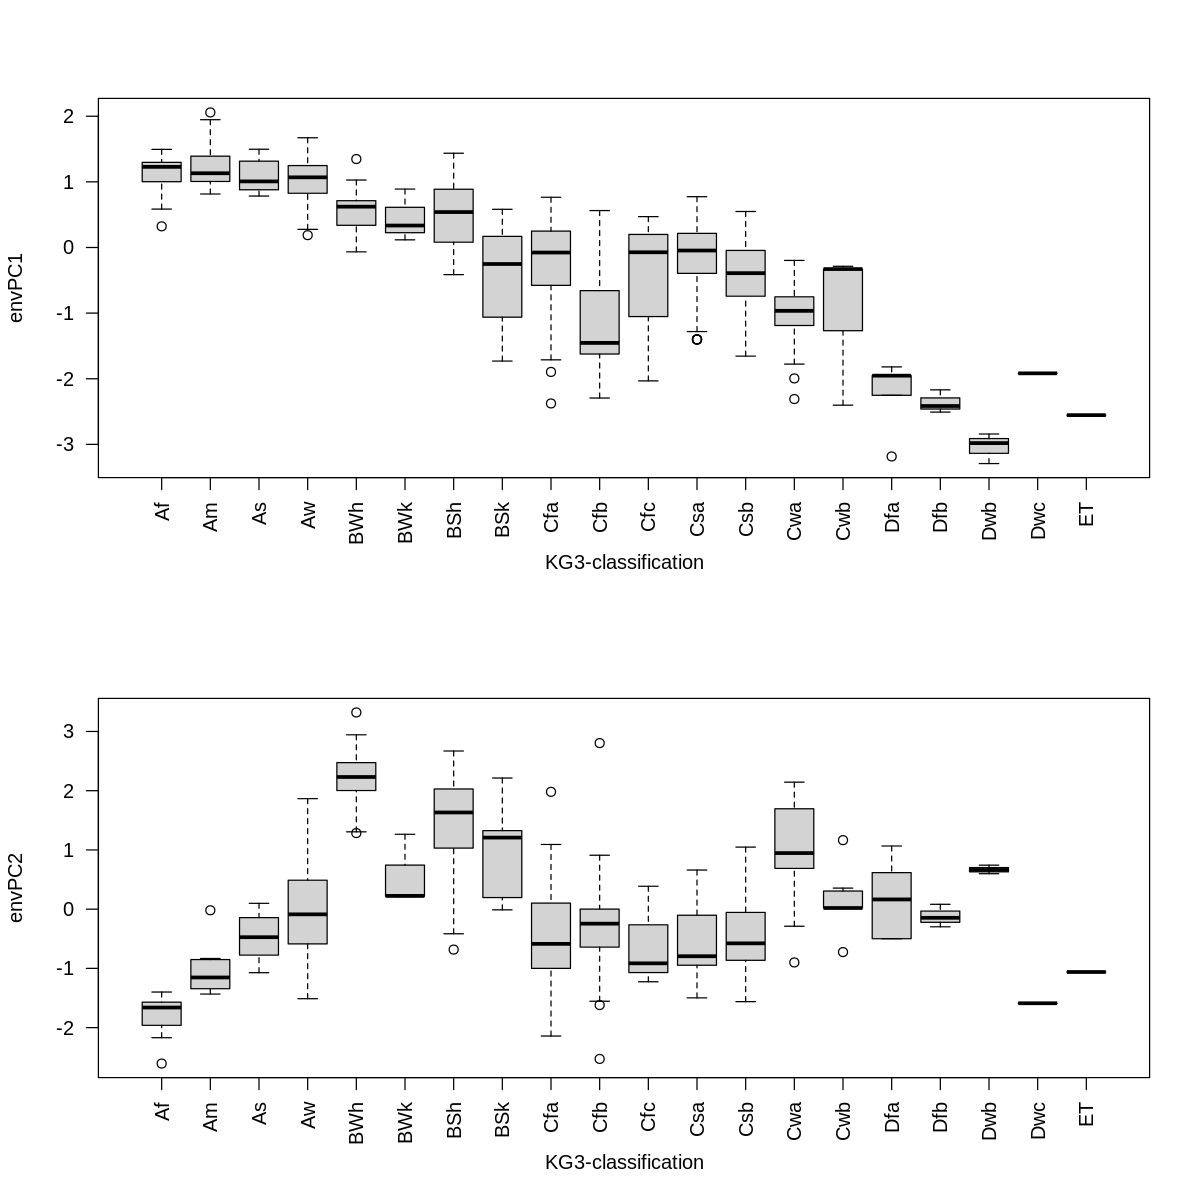

In [80]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,1))
plot(ePCs$synthetic.environmental.traits[,1]~as.factor(KG3_class),
     xlab = "KG3-classification",ylab = "envPC1",names = KG3_name[sort(unique(KG3_class))],las =2)
plot(ePCs$synthetic.environmental.traits[,2]~as.factor(KG3_class),
     xlab = "KG3-classification",ylab = "envPC2",names = KG3_name[sort(unique(KG3_class))],las = 2)

In [82]:
levels(as.factor(KG3_class))

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "15" "16"
[16] "18" "19" "27" "28" "30"

In [65]:
KG3_name = c("Af","Am","As","Aw",
             "BWh","BWk","BSh","BSk",
             "Cfa","Cfb","Cfc","Csa","Csb","Csc","Cwa","Cwb","Cwc",
             "Dfa","Dfb","Dfc","Dfd","Dsa","Dsb","Dsc","Dsd","Dwa","Dwb","Dwc","Dwd",
             "ET","EF")

In [55]:
colnames(ePCs$environmental.features)

[1] "bio01_Annual_Mean_Temperature_quan10"         
  [2] "bio01_Annual_Mean_Temperature_quan50"         
  [3] "bio01_Annual_Mean_Temperature_quan90"         
  [4] "bio10_Mean_Temperature_Warmest_Quarter_quan10"
  [5] "bio10_Mean_Temperature_Warmest_Quarter_quan50"
  [6] "bio10_Mean_Temperature_Warmest_Quarter_quan90"
  [7] "bio11_Mean_Temperature_Coldest_Quarter_quan10"
  [8] "bio11_Mean_Temperature_Coldest_Quarter_quan50"
  [9] "bio11_Mean_Temperature_Coldest_Quarter_quan90"
 [10] "bio12_Annual_Precipitation_quan10"            
 [11] "bio12_Annual_Precipitation_quan50"            
 [12] "bio12_Annual_Precipitation_quan90"            
 [13] "bio13_Precipitation_Wettest_Month_quan10"     
 [14] "bio13_Precipitation_Wettest_Month_quan50"     
 [15] "bio13_Precipitation_Wettest_Month_quan90"     
 [16] "bio14_Precipitation_Driest_Month_quan10"      
 [17] "bio14_Precipitation_Driest_Month_quan50"      
 [18] "bio14_Precipitation_Driest_Month_quan90"      
 [19] "bio15_Precipitation_Seasonality_quan10"       
 [20] "bio15_Precipitation_Seasonality_quan50"       
 [21] "bio15_Precipitation_Seasonality_quan90"       
 [22] "bio16_Precipitation_Wettest_Quarter_quan10"   
 [23] "bio16_Precipitation_Wettest_Quarter_quan50"   
 [24] "bio16_Precipitation_Wettest_Quarter_quan90"   
 [25] "bio17_Precipitation_Driest_Quarter_quan10"    
 [26] "bio17_Precipitation_Driest_Quarter_quan50"    
 [27] "bio17_Precipitation_Driest_Quarter_quan90"    
 [28] "bio18_Precipitation_Warmest_Quarter_quan10"   
 [29] "bio18_Precipitation_Warmest_Quarter_quan50"   
 [30] "bio18_Precipitation_Warmest_Quarter_quan90"   
 [31] "bio19_Precipitation_Coldest_Quarter_quan10"   
 [32] "bio19_Precipitation_Coldest_Quarter_quan50"   
 [33] "bio19_Precipitation_Coldest_Quarter_quan90"   
 [34] "bio02_Mean_Diurnal_Range_quan10"              
 [35] "bio02_Mean_Diurnal_Range_quan50"              
 [36] "bio02_Mean_Diurnal_Range_quan90"              
 [37] "bio03_Isothermality_quan10"                   
 [38] "bio03_Isothermality_quan50"                   
 [39] "bio03_Isothermality_quan90"                   
 [40] "bio04_Temperature_Seasonality_quan10"         
 [41] "bio04_Temperature_Seasonality_quan50"         
 [42] "bio04_Temperature_Seasonality_quan90"         
 [43] "bio05_Max_Temperature_Warmest_Month_quan10"   
 [44] "bio05_Max_Temperature_Warmest_Month_quan50"   
 [45] "bio05_Max_Temperature_Warmest_Month_quan90"   
 [46] "bio06_Min_Temperature_Coldest_Month_quan10"   
 [47] "bio06_Min_Temperature_Coldest_Month_quan50"   
 [48] "bio06_Min_Temperature_Coldest_Month_quan90"   
 [49] "bio07_Temperature_Annual_Range_quan10"        
 [50] "bio07_Temperature_Annual_Range_quan50"        
 [51] "bio07_Temperature_Annual_Range_quan90"        
 [52] "bio08_Mean_Temperature_Wettest_Quarter_quan10"
 [53] "bio08_Mean_Temperature_Wettest_Quarter_quan50"
 [54] "bio08_Mean_Temperature_Wettest_Quarter_quan90"
 [55] "bio09_Mean_Temperature_Driest_Quarter_quan10" 
 [56] "bio09_Mean_Temperature_Driest_Quarter_quan50" 
 [57] "bio09_Mean_Temperature_Driest_Quarter_quan90" 
 [58] "HYSOGs_quan10"                                
 [59] "HYSOGs_quan50"                                
 [60] "HYSOGs_quan90"                                
 [61] "eta_quan10"                                   
 [62] "eta_quan50"                                   
 [63] "eta_quan90"                                   
 [64] "KG2_quan10"                                   
 [65] "KG2_quan50"                                   
 [66] "KG2_quan90"                                   
 [67] "KG3_quan10"                                   
 [68] "KG3_quan50"                                   
 [69] "KG3_quan90"                                   
 [70] "ld1_quan10"                                   
 [71] "ld1_quan50"                                   
 [72] "ld1_quan90"                                   
 [73] "lgb_quan10"                                   
 [74] "lgb_quan50"                                   
 [75] 

In [58]:
envDf = as.data.frame(ePCs$environmental.features)

In [63]:
envDf[commonID,]

,bio01_Annual_Mean_Temperature_quan10,bio01_Annual_Mean_Temperature_quan50,bio01_Annual_Mean_Temperature_quan90,bio10_Mean_Temperature_Warmest_Quarter_quan10,bio10_Mean_Temperature_Warmest_Quarter_quan50,bio10_Mean_Temperature_Warmest_Quarter_quan90,bio11_Mean_Temperature_Coldest_Quarter_quan10,bio11_Mean_Temperature_Coldest_Quarter_quan50,bio11_Mean_Temperature_Coldest_Quarter_quan90,bio12_Annual_Precipitation_quan10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10wheat_assembly_jagger,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,183.0,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
10wheat_assembly_stanley,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,183.0,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
10wheat_assembly_lancer,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,183.0,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
Triticum_aestivum_Claire_EIv1.1,6.133500,13.1071663,20.018167,17.007999,23.71200,28.88067,-5.1043334,3.24566662,11.958000,183.0,⋯,0.99264,-0.88270,0.80461,-0.40422,-1.26081,-0.07097,0.20012,0.50082,0.57836,1.26217
WEW_v2.1,16.764166,18.7045002,20.341333,23.534000,25.71667,27.30067,8.9806662,10.91266632,12.826800,381.0,⋯,-0.05710,0.30570,0.76211,0.52841,0.31222,-1.22973,0.26641,-0.06968,0.46370,2.34564
Svevo.v1,8.796250,12.3255835,15.784000,16.990000,20.43933,24.17740,0.2693333,4.98433328,8.728067,487.0,⋯,0.44827,-0.29788,-0.29079,-0.05951,-0.22431,0.86044,-0.67817,-0.47077,0.25302,-0.01622
SRR13484808,9.772833,16.2625008,18.427767,21.112667,28.40867,30.88000,-2.3980000,4.28600025,6.096666,330.0,⋯,2.59143,0.18100,-0.09097,1.71525,-1.17632,1.33499,-0.26378,1.65355,-2.21338,1.22726
Triticum_petropavlovskyi,-6.387500,-0.9163332,8.996217,4.408667,11.68400,22.76780,-17.6293335,-14.58400011,-6.931734,116.6,⋯,-0.34366,-1.03797,1.37552,4.82592,-2.06554,-3.28306,-0.21600,-0.06277,1.05704,-2.53961
PI306540_Tmono,8.476017,11.7157893,17.294016,17.985133,21.71367,27.47440,-2.5315999,2.48399997,7.888667,330.9,⋯,1.87978,0.87968,-0.76011,0.20469,-0.71951,1.08654,-0.57305,0.23509,-0.31397,-0.47426


In [203]:
taxanomicGroup = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_taxonomic_groups_subtribeAdded_SKH20250210.csv")
taxanomicGroup = taxanomicGroup[!duplicated(taxanomicGroup[,1]),]
rownames(taxanomicGroup) = taxanomicGroup[,1]

In [ ]:
options(repr.plot.width=8, repr.plot.height=10)

tmpTrait = envDf[commonID,]$bio01_Annual_Mean_Temperature_quan50
tmpTrait2 = envDf[commonID,]$bio12_Annual_Precipitation_quan50
names(tmpTrait)=commonID
names(tmpTrait2)=commonID
fit <- phytools::fastAnc(spTre.rooted.filtered,tmpTrait , vars=TRUE, CI=TRUE)
td <- data.frame(node = nodeid(spTre.rooted.filtered, commonID),
               envPC1 = tmpTrait)
nd <- data.frame(node = names(fit$ace), envPC1 = fit$ace)
d <- rbind(td, nd)
d$node <- as.numeric(d$node)
plotTree <- full_join(spTre.rooted.filtered, d, by = 'node')

fit2 <- phytools::fastAnc(spTre.rooted.filtered,tmpTrait2 , vars=TRUE, CI=TRUE)
td2 <- data.frame(node = nodeid(spTre.rooted.filtered, commonID),
               envPC2 = tmpTrait2)
nd2 <- data.frame(node = names(fit2$ace), envPC2 = fit2$ace)
d2 <- rbind(td2, nd2)
d2$node <- as.numeric(d2$node)
plotTree2 <- full_join(spTre.rooted.filtered, d2, by = 'node')

In [79]:
tiplabels(plotTree)

ERROR: Error in as.character.default(x): no method for coercing this S4 class to a vector


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


pdf 
  2

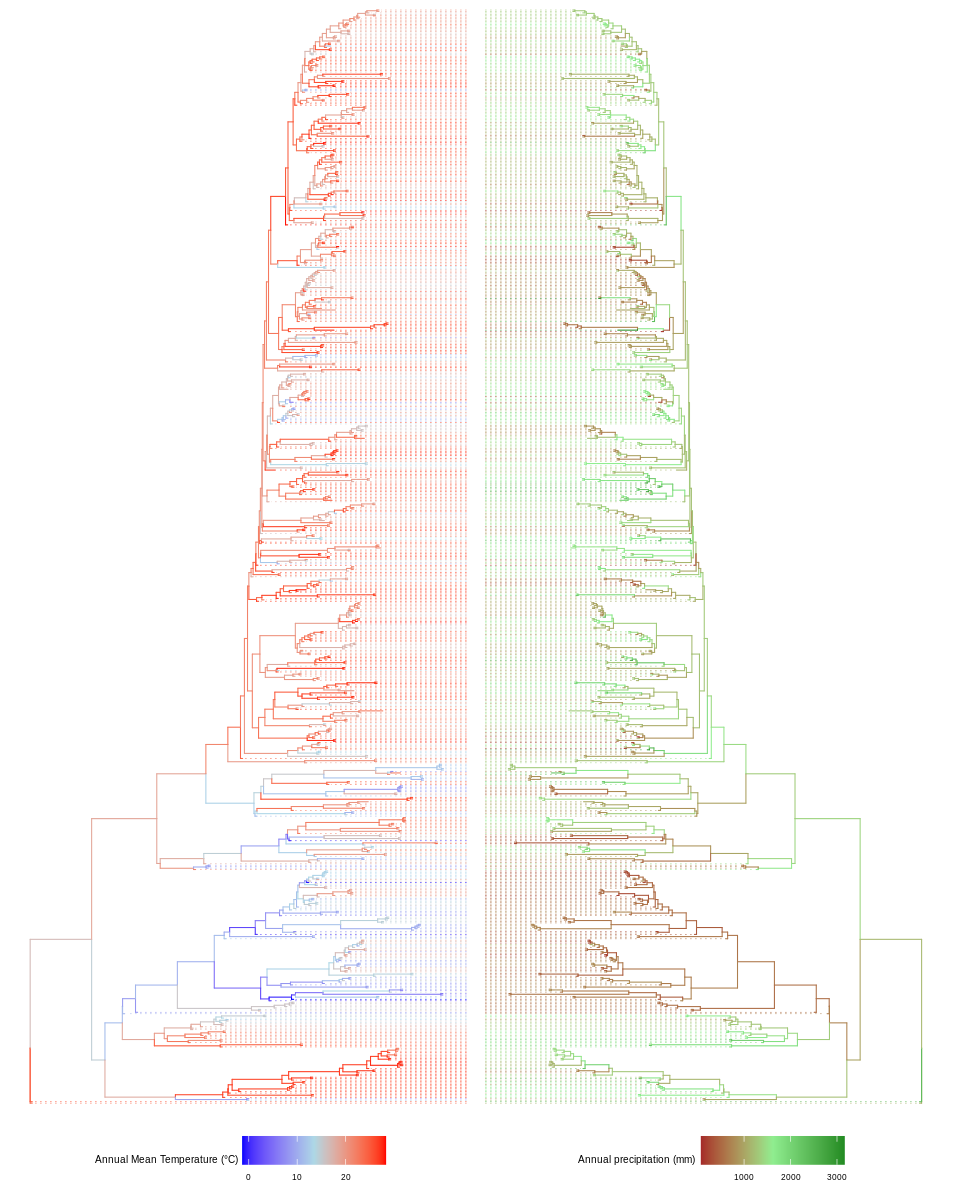

In [235]:
p <- ggtree(plotTree,aes(color=envPC1), ladderize = T,size = .3) +
    scale_color_gradientn(colours = c('blue',"lightblue",'red'),name = "Annual Mean Temperature (\u00B0C)")+
    geom_tiplab(as_ylab=TRUE, align = T,size =1,linetype = 3,offset = 1,linesize = .2,hjust = -1)+
    xlim(0,20)+
    theme_tree(legend.position = "bottom",plot.margin = margin(t= 0, r= 0,b = 0,l = 0, unit='mm'),
          legend.title = element_text(size = 6),legend.text = element_text(size = 5),
          axis.text.y = element_text(hjust = -10,size = 0))
p <- p + ggtree(plotTree2,aes(color=envPC2), ladderize = T,size = .3)+ 
    scale_x_reverse()+
    geom_tiplab(as_ylab=TRUE, align = T,size =0,linetype = 3,offset = -1,linesize = .2,hjust = 1)+
    xlim(20,0)+
    scale_color_gradientn(colours = c('brown',"lightgreen",'forestgreen'),name = "Annual precipitation (mm)")+
    theme(legend.position = "bottom",plot.margin = margin(t= 0, r= 0,b = 0,l = 0, unit='mm'),
          legend.title = element_text(size = 6),legend.text = element_text(size = 5),
          axis.text.y = element_text(hjust = -10,size = 0))
p
png("/workdir/sh2246/p_phyloGWAS/output/envAdapt_summary.png",width = 15,height = 30,units = "cm",
    pointsize = 6,res = 600)
p
dev.off()
# p1 <- gheatmap(p, as.data.frame(testScore[,1]) , offset=0.2, width=0.1,colnames = F) +
#     scale_x_ggtree() + 
#     scale_y_continuous(expand=c(0, 0.3))+
#     scale_fill_gradientn(colours = c('blue',"grey",'red'),name = "envPC1")+
#     theme(axis.text=element_text(size=5),legend.position = "bottom",legend.key.width = unit(3,units = "mm"),
#           legend.key.height = unit(1.5,units = "mm"),
#           legend.margin = margin(t = -2,r =0,b = 0,l =0, unit='mm'),
#           plot.margin = margin(t= 3, r= 2,b = 2,l = 2, unit='mm'),
#           legend.title = element_text(size = 6),legend.text = element_text(size = 5))
# p2 <- p1+ new_scale_fill()
# p2 <- gheatmap(p2, as.data.frame(testScore[,2]) , offset=2.5, width=0.1,colnames = F) +
#     scale_y_continuous(expand=c(0, 0.3))+
#     scale_fill_gradientn(colours = c('brown',"grey",'forestgreen'),name = "envPC2")+
#     theme(axis.text=element_text(size=5),legend.position = "bottom",legend.key.width = unit(3,units = "mm"),
#           legend.key.height = unit(1.5,units = "mm"),
#           legend.margin = margin(t = -2,r =0,b = 0,l =0, unit='mm'),
#           plot.margin = margin(t= 3, r= 2,b = 2,l = 2, unit='mm'),
#           legend.title = element_text(size = 6),legend.text = element_text(size = 5))
# p2

In [217]:
tribeLab = taxanomicGroup[commonID,5]
names(tribeLab) = commonID

In [374]:
highlightNode = c()
for( i in c("Andropogoneae","Cynodonteae","Oryzeae","Paniceae","Poeae","Triticeae")){
    highlightNode = c(highlightNode,getMRCA(spTre.rooted.filtered,taxanomicGroup[commonID,][taxanomicGroup[commonID,5]==i,1]))
}


In [369]:
unique(tribeLab)

[1] "Triticeae"       "Bromeae"         "Poeae"           "Brachypodieae"  
 [5] "Stipeae"         "Cynodonteae"     "Zoysieae"        "Eragrostideae"  
 [9] "Triraphideae"    "Molinieae"       "Paniceae"        "Paspaleae"      
[13] "Andropogoneae"   "Streptochaeteae" "Phareae"         "Oryzeae"        
[17] "Arundinarieae"   "Bambuseae"       "Olyreae"

In [371]:
highlightNode

[1] 998 875 926 885 959 815 768

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing

pdf 
  2

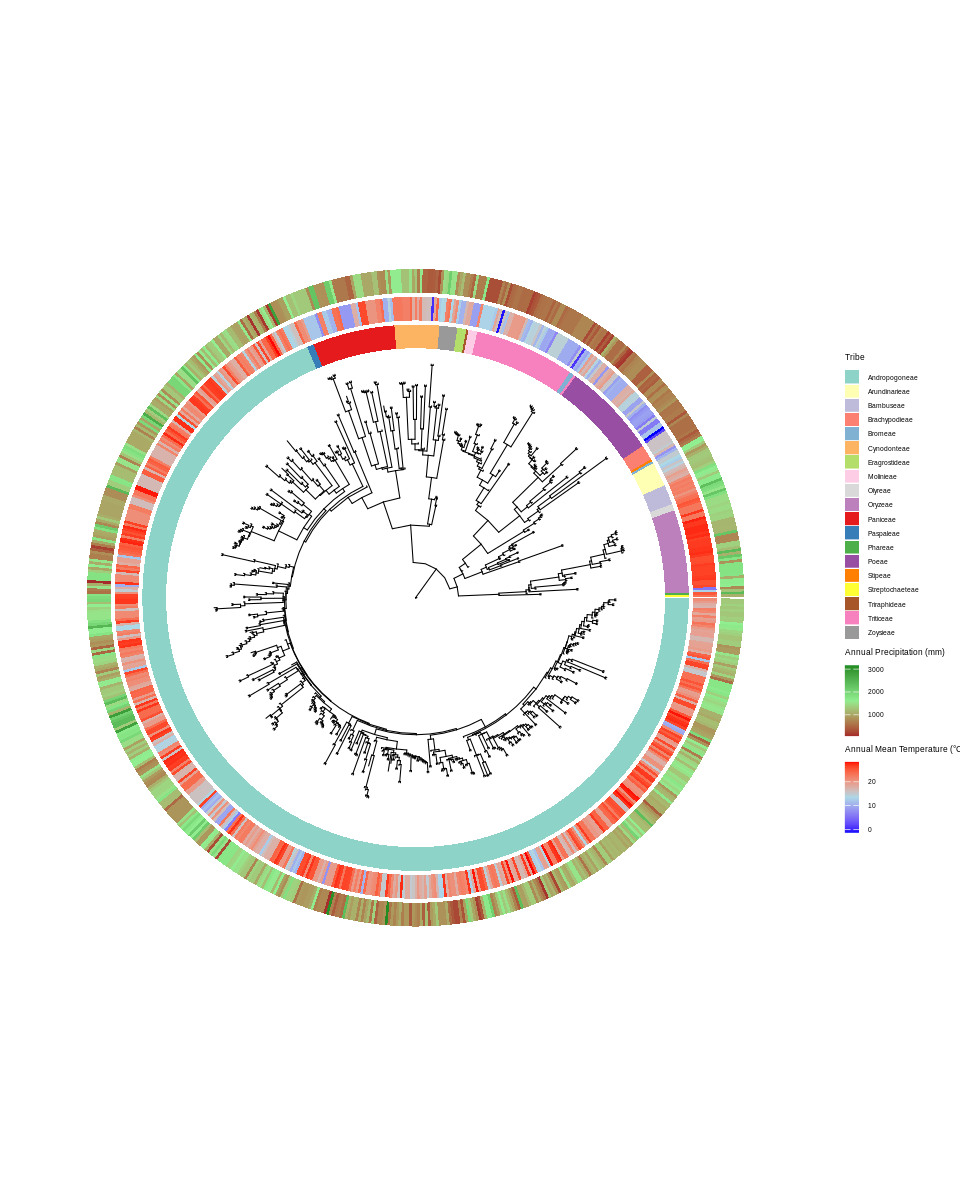

In [240]:
p <- ggtree(plotTree,layout = "circular", ladderize = T,size = .3)
p <- gheatmap(p, as.data.frame(tribeLab) , offset=0, width=0.1,colnames = F,color = NA) +
    scale_x_ggtree() + 
    scale_y_continuous(expand=c(0, 0.3))+
    scale_fill_manual(values = c(RColorBrewer::brewer.pal(10,"Set3"),RColorBrewer::brewer.pal(9,"Set1")),
                      name = "Tribe")
p1 <- p+ new_scale_fill()
p1 <- gheatmap(p1, as.data.frame(tmpTrait) , offset=2.3, width=0.1,colnames = F,color = NA) +
    scale_x_ggtree() + 
    scale_y_continuous(expand=c(0, 0.3))+
    scale_fill_gradientn(colours = c('blue',"lightblue",'red'),name = "Annual Mean Temperature (\u00B0C)")
p2 <- p1+ new_scale_fill()
p2 <- gheatmap(p2, as.data.frame(tmpTrait2) , offset=4.6, width=0.1,colnames = F,color = NA) +
    scale_y_continuous(expand=c(0, 0.3))+
    scale_fill_gradientn(colours = c('brown',"lightgreen",'forestgreen'),name = "Annual Precipitation (mm)")+
    theme(axis.text=element_text(size=5),legend.position = "right",legend.key.width = unit(3,units = "mm"),
          legend.key.height = unit(3,units = "mm"),
          legend.margin = margin(t = -2,r =0,b = 0,l =0, unit='mm'),
          plot.margin = margin(t= 0, r= 0,b = 0,l = 0, unit='mm'),
          legend.title = element_text(size = 5),legend.text = element_text(size = 4))
p2
# png("/workdir/sh2246/p_phyloGWAS/output/envAdapt_summaryC.png",width = 16,height = 12,units = "cm",
#     pointsize = 6,res = 600)
# p2
# dev.off()


In [375]:
highlightNodeDat= data.frame(node = highlightNode,
                             Tribe = c("Andropogoneae","Cynodonteae","Oryzeae","Paniceae","Poeae","Triticeae"))

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


pdf 
  2

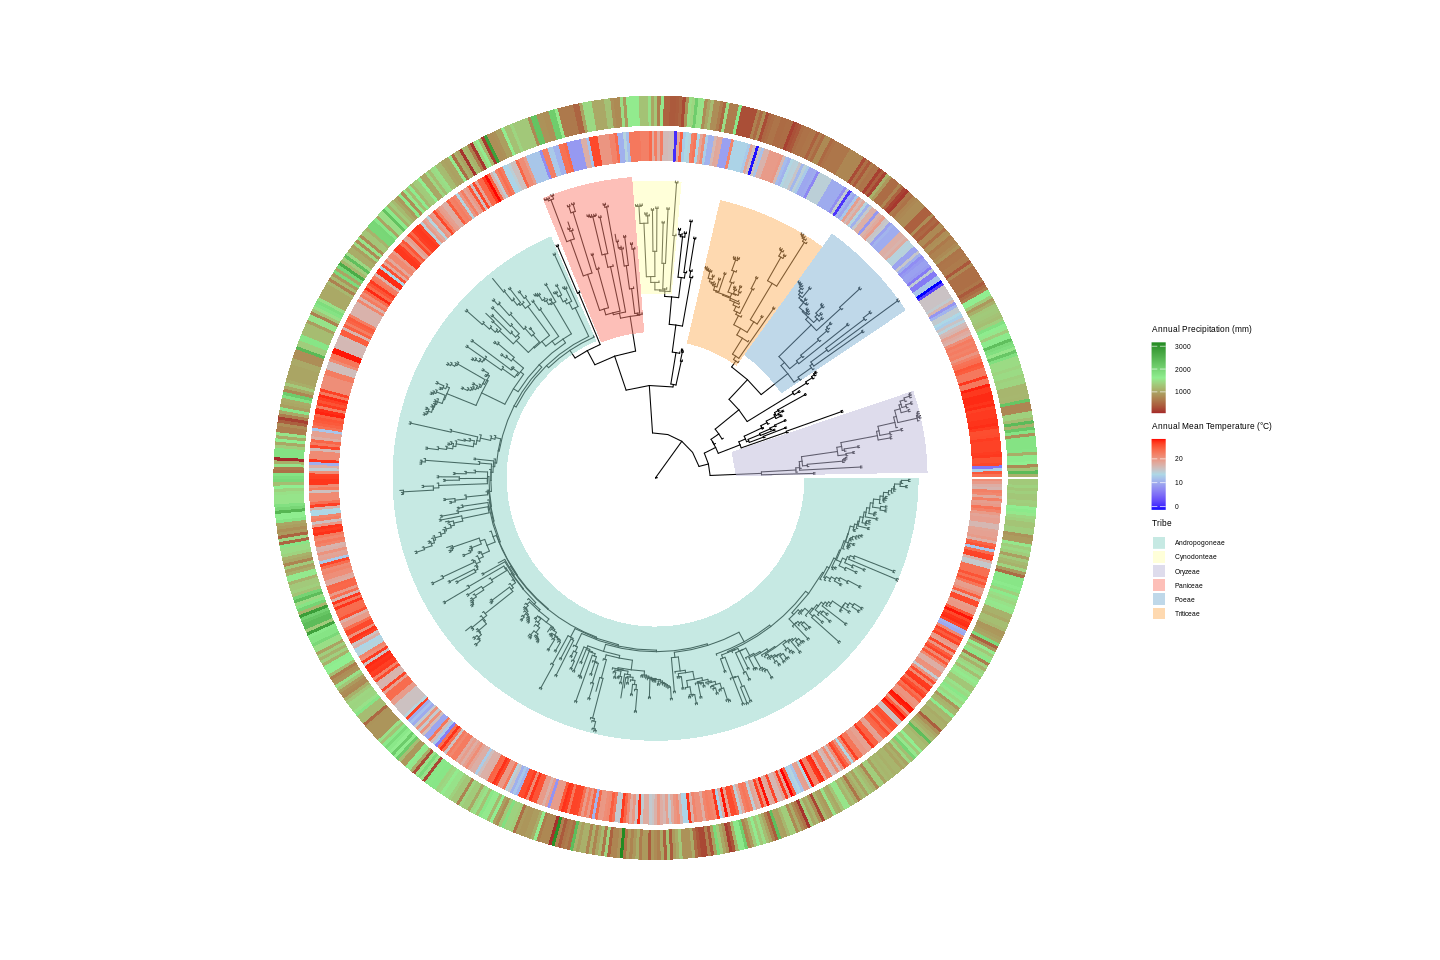

In [377]:
p <- ggtree(plotTree,layout = "circular", ladderize = T,size = .3)
p <- p + geom_hilight(data=highlightNodeDat, aes(node=node, fill=Tribe),alpha = .5) +
    scale_fill_manual(values = RColorBrewer::brewer.pal(7,"Set3"),name = "Tribe")
p1 <- p+ new_scale_fill()
p1 <- gheatmap(p1, as.data.frame(tmpTrait) , offset=0, width=0.1,colnames = F,color = NA) +
    scale_x_ggtree() + 
    scale_y_continuous(expand=c(0, 0.3))+
    scale_fill_gradientn(colours = c('blue',"lightblue",'red'),name = "Annual Mean Temperature (\u00B0C)")
p2 <- p1+ new_scale_fill()
p2 <- gheatmap(p2, as.data.frame(tmpTrait2) , offset=2.3, width=0.1,colnames = F,color = NA) +
    scale_y_continuous(expand=c(0, 0.3))+
    scale_fill_gradientn(colours = c('brown',"lightgreen",'forestgreen'),name = "Annual Precipitation (mm)")+
    theme(axis.text=element_text(size=5),legend.position = "right",legend.key.width = unit(3,units = "mm"),
          legend.key.height = unit(3,units = "mm"),
          legend.margin = margin(t = -2,r =0,b = 0,l =0, unit='mm'),
          plot.margin = margin(t= 0, r= 0,b = 0,l = 0, unit='mm'),
          legend.title = element_text(size = 5),legend.text = element_text(size = 4))
p2
png("/workdir/sh2246/p_phyloGWAS/output/envAdapt_summaryC2.png",width = 16,height = 12,units = "cm",
    pointsize = 6,res = 600)
p2
dev.off()


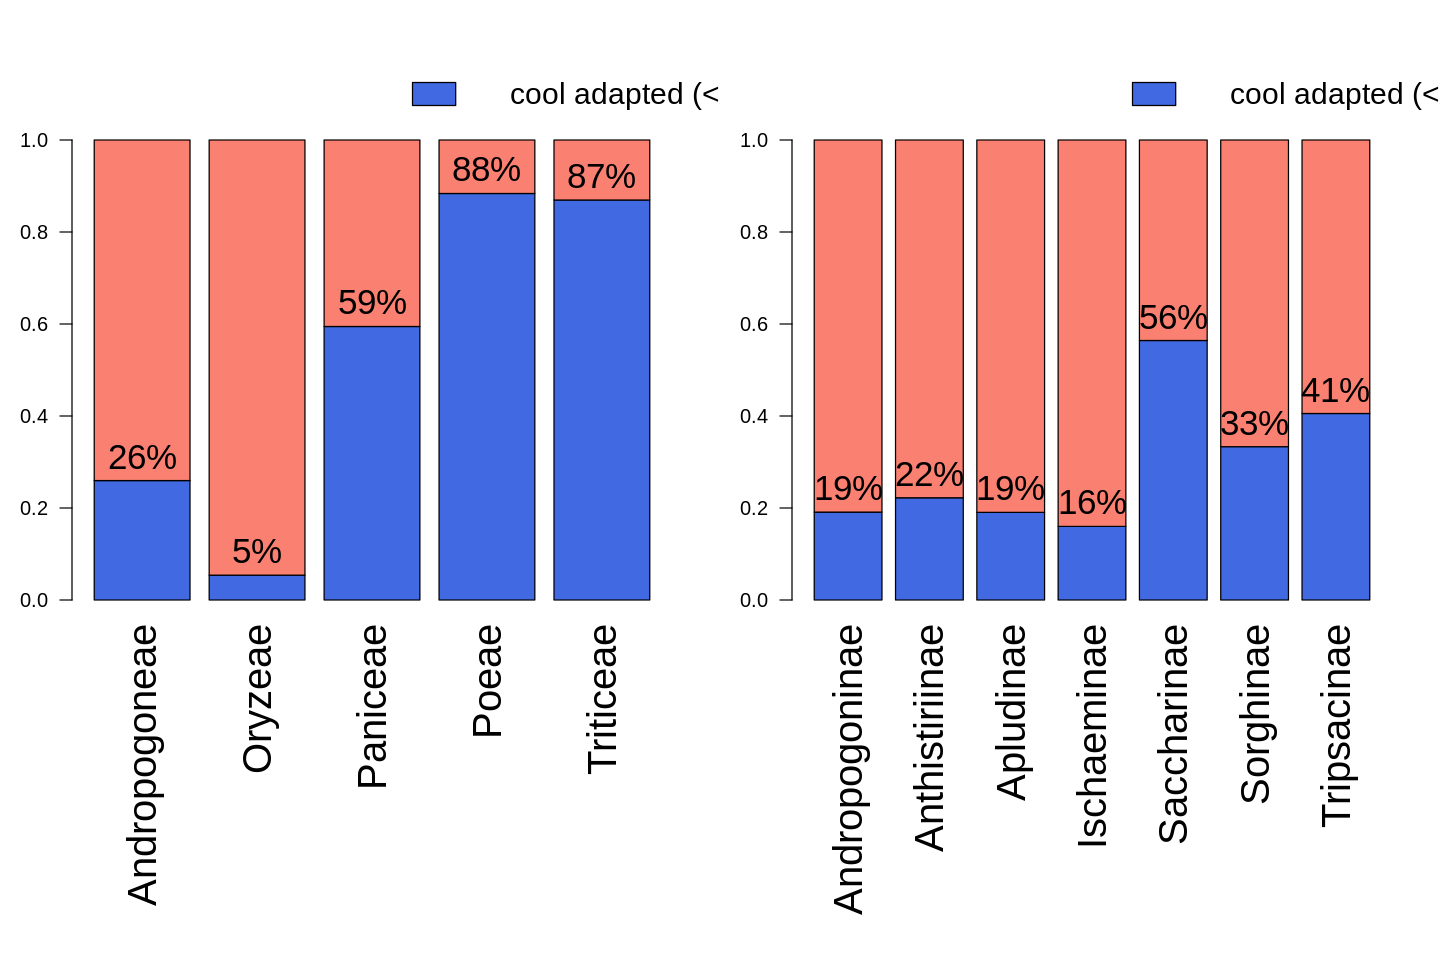

In [329]:
options(repr.plot.width=12, repr.plot.height=8)
coldAdaptCount = t(table(tmpTrait<18,tribeLab))
coldAdaptFreq = coldAdaptCount/rowSums(coldAdaptCount)
par(mar=c(15,3,2,2),mfrow = c(1,2),las =2)
bp = barplot(t(coldAdaptFreq[rowSums(coldAdaptCount)>=30,c(2,1)]),col = c("royalblue","salmon"),ylim = c(0,1.2),
             cex.names = 2,cex.axis =1.5,args.legend = list(x= "top",bty= 'n',horiz =T,cex = 1.5),yaxt = 'n',
             legend.text = c("cool adapted (<18\u00B0C)","warm adapted"),las = 2)
axis(2,seq(0,1,0.2))
text(bp,coldAdaptFreq[rowSums(coldAdaptCount)>=30,2],
     paste0(round(coldAdaptFreq[rowSums(coldAdaptCount)>=30,2],2)*100,"%"),pos=3,cex = 1.75)

coldAdaptCount = t(table(tmpTrait[tribeLab%in%"Andropogoneae"]<18,taxanomicGroup[commonID,7][tribeLab%in%"Andropogoneae"]))
coldAdaptFreq = coldAdaptCount/rowSums(coldAdaptCount)
bp = barplot(t(coldAdaptFreq[rowSums(coldAdaptCount)>=20,c(2,1)]),col = c("royalblue","salmon"),ylim = c(0,1.2),
             cex.names = 2,cex.axis =1.5,args.legend = list(x= "top",bty= 'n',horiz =T,cex = 1.5),yaxt = 'n',
             legend.text = c("cool adapted (<18\u00B0C)","warm adapted"),las = 2)
axis(2,seq(0,1,0.2))
text(bp,coldAdaptFreq[rowSums(coldAdaptCount)>=20,2],
     paste0(round(coldAdaptFreq[rowSums(coldAdaptCount)>=20,2],2)*100,"%"),pos=3,cex = 1.75)


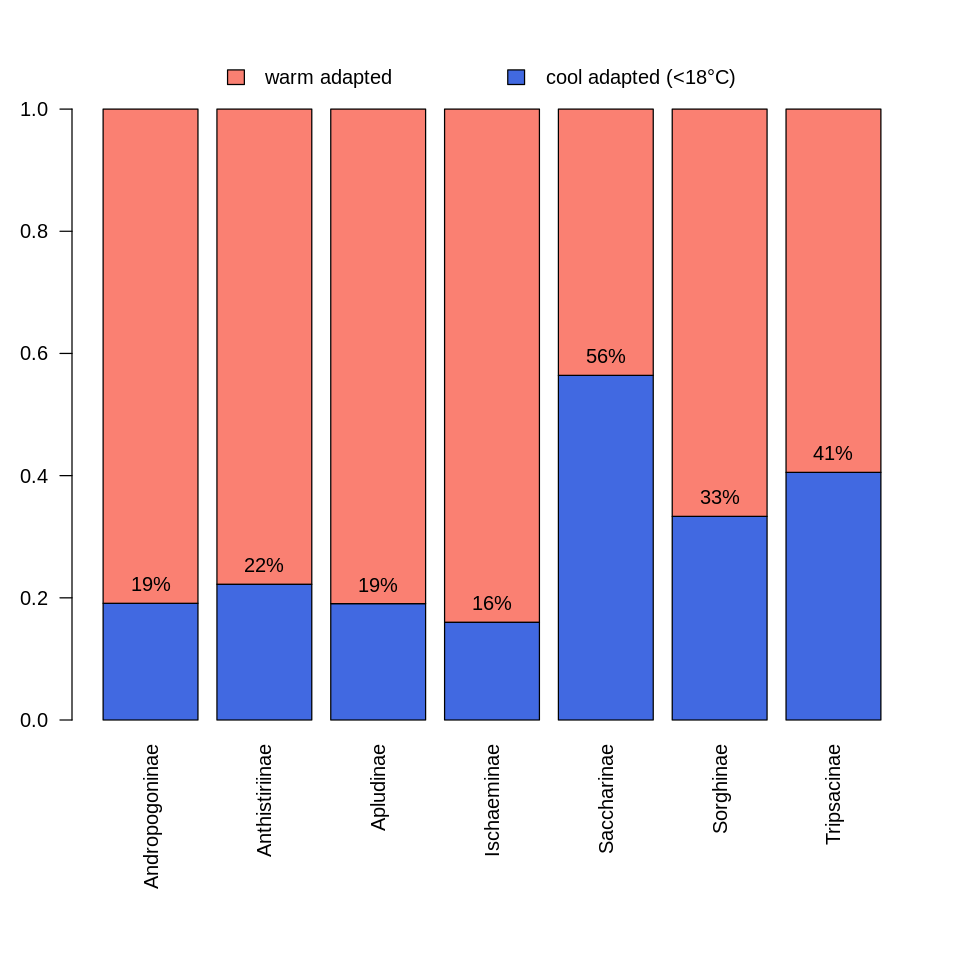

In [281]:
options(repr.plot.width=8, repr.plot.height=8)
coldAdaptCount = t(table(tmpTrait[tribeLab%in%"Andropogoneae"]<18,taxanomicGroup[commonID,7][tribeLab%in%"Andropogoneae"]))
coldAdaptFreq = coldAdaptCount/rowSums(coldAdaptCount)
par(mar=c(10,3,2,2),las=2)
bp = barplot(t(coldAdaptFreq[rowSums(coldAdaptCount)>=20,c(2,1)]),col = c("royalblue","salmon"),ylim = c(0,1.1),
        args.legend = list(x= "top",bty= 'n',horiz =T),legend.text = c("cool adapted (<18\u00B0C)","warm adapted"))
text(bp,coldAdaptFreq[rowSums(coldAdaptCount)>=20,2],
     paste0(round(coldAdaptFreq[rowSums(coldAdaptCount)>=20,2],2)*100,"%"),pos=3)

In [286]:
rownames(coldAdaptCount)[rowSums(coldAdaptCount)>20]


[1] "Andropogoninae" "Anthistiriinae" "Apludinae"      "Ischaeminae"   
[5] "Saccharinae"    "Sorghinae"      "Tripsacinae"

In [257]:
rowSums(coldAdaptCount)

Andropogoneae   Arundinarieae       Bambuseae   Brachypodieae         Bromeae 
            520              11               9               7               3 
    Cynodonteae   Eragrostideae       Molinieae         Olyreae         Oryzeae 
             20               4               4               3              37 
       Paniceae       Paspaleae         Phareae           Poeae         Stipeae 
             37               3               1              43               1 
Streptochaeteae    Triraphideae       Triticeae        Zoysieae 
              1               1              46               8

In [53]:
cor(as.data.frame(ePCs$environmental.features)$bio12_Annual_Precipitation_quan50,
    ePCs$synthetic.environmental.traits[,1])^2
cor(as.data.frame(ePCs$environmental.features)$bio12_Annual_Precipitation_quan50,
    ePCs$synthetic.environmental.traits[,2])^2
ppcor::pcor(cbind(ePCs$synthetic.environmental.traits[,1],
                  as.data.frame(ePCs$environmental.features)$bio12_Annual_Precipitation_quan50,
                  as.data.frame(ePCs$environmental.features)$bio01_Annual_Mean_Temperature_quan50))$estimate^2

[1] 0.2469844

[1] 0.5434227

1.0000000,0.1895212,0.9396072
0.1895212,1.0000000,0.1090216
0.9396072,0.1090216,1.0000000


In [62]:
cor(eTraits_filtered$bio01_Annual_Mean_Temperature_quan50,eTraits_filtered$bio12_Annual_Precipitation_quan50)

[1] 0.408251

In [63]:
length(spTre.rooted.filtered$tip.label)

[1] 759

In [64]:
write.table(eTraits_filtered,"/workdir/sh2246/p_phyloGWAS/output/envData_759Poaceae_20240821.txt",
            quote = F, col.names = T, row.names = T,sep = "\t")

In [106]:
eTraits_filtered[c("10wheat_assembly_jagger","Hvulgare_FT262_BPGv2",'Pp-Kellogg1297-DRAFT-PanAnd-1.0',
                   "Avena_sativa_cv_Sang_v1_assembly","mabamboo_1.0","Setaria_viridis_v2.0",
                  "P.virgatum_v5","IRGSP-1.0","Ag-CAM1351-DRAFT-PanAnd-1.0",
                   "Sn-CAM1369-DRAFT-PanAnd-1.0","Sorghum_bicolor_NCBIv3",
                  "Td-FL_9056069_6-REFERENCE-PanAnd-2.0a","Zm-B73-REFERENCE-NAM-5.0"),c(2,11)]

,bio01_Annual_Mean_Temperature_quan50,bio12_Annual_Precipitation_quan50
,<dbl>,<dbl>
10wheat_assembly_jagger,13.107166,301.0
Hvulgare_FT262_BPGv2,9.944000,782.0
Pp-Kellogg1297-DRAFT-PanAnd-1.0,5.928833,602.0
Avena_sativa_cv_Sang_v1_assembly,9.851333,780.0
mabamboo_1.0,21.007500,1819.0
Setaria_viridis_v2.0,12.338834,833.0
P.virgatum_v5,11.643056,957.0
IRGSP-1.0,22.983167,1461.5
Ag-CAM1351-DRAFT-PanAnd-1.0,9.587667,851.0


In [108]:
eTraits_filtered[which.min(eTraits_filtered[,11]),c(2,11)]

,bio01_Annual_Mean_Temperature_quan50,bio12_Annual_Precipitation_quan50
,<dbl>,<dbl>
AN21TNTL0121,27.19183,74


In [105]:
rownames(eTraits_filtered)[grep('Pp',rownames(eTraits_filtered))]

[1] "Pp-Kellogg1297-DRAFT-PanAnd-1.0"

# annualism & env.

In [19]:
eTraits_filtered$assemblyID = rownames(eTraits_filtered)


In [20]:
mergedData = merge(metadata,eTraits_filtered,by ="assemblyID")

In [21]:
dim(eTraits_filtered)

[1] 759 326

In [22]:
colnames(eTraits_filtered)[grep("Seasonality",colnames(eTraits_filtered))]

[1] "bio15_Precipitation_Seasonality_quan10"
[2] "bio15_Precipitation_Seasonality_quan50"
[3] "bio15_Precipitation_Seasonality_quan90"
[4] "bio04_Temperature_Seasonality_quan10"  
[5] "bio04_Temperature_Seasonality_quan50"  
[6] "bio04_Temperature_Seasonality_quan90"

In [23]:
mergedData = mergedData %>% filter(lifeHistory=='annual'|lifeHistory=='perennial')

In [24]:
mergedData$lifeHistoryNumeric = as.numeric(as.factor(mergedData$lifeHistory))

In [40]:
anova(lm(mergedData$lifeHistoryNumeric~mergedData$bio15_Precipitation_Seasonality_quan50))
anova(lm(mergedData$lifeHistoryNumeric~mergedData$bio04_Temperature_Seasonality_quan50))
anova(lm(mergedData$lifeHistoryNumeric~mergedData$bio04_Temperature_Seasonality_quan50+mergedData$bio15_Precipitation_Seasonality_quan50))
anova(lm(mergedData$lifeHistoryNumeric~mergedData$bio04_Temperature_Seasonality_quan50*mergedData$bio15_Precipitation_Seasonality_quan50*mergedData$bio01_Annual_Mean_Temperature_quan50))

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
mergedData$bio15_Precipitation_Seasonality_quan50,1,2.178637,2.1786370,9.890064,0.001729674
Residuals,724,159.486652,0.2202854,NA,NA


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
mergedData$bio04_Temperature_Seasonality_quan50,1,2.273284,2.2732845,10.32585,0.001369933
Residuals,724,159.392005,0.2201547,NA,NA


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
mergedData$bio04_Temperature_Seasonality_quan50,1,2.273284,2.2732845,10.66863,1.141094e-03
mergedData$bio15_Precipitation_Seasonality_quan50,1,5.334313,5.3343132,25.03418,7.078793e-07
Residuals,723,154.057692,0.2130812,NA,NA


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
mergedData$bio04_Temperature_Seasonality_quan50,1,2.273284e+00,2.273284496,11.62713628,6.863032e-04
mergedData$bio15_Precipitation_Seasonality_quan50,1,5.334313e+00,5.334313167,27.28333664,2.304577e-07
mergedData$bio01_Annual_Mean_Temperature_quan50,1,3.647818e-03,0.003647818,0.01865744,8.913914e-01
mergedData$bio04_Temperature_Seasonality_quan50:mergedData$bio15_Precipitation_Seasonality_quan50,1,2.551830e+00,2.551830377,13.05181099,3.241169e-04
mergedData$bio04_Temperature_Seasonality_quan50:mergedData$bio01_Annual_Mean_Temperature_quan50,1,5.471557e-01,0.547155685,2.79852950,9.478642e-02
mergedData$bio15_Precipitation_Seasonality_quan50:mergedData$bio01_Annual_Mean_Temperature_quan50,1,1.057293e+01,10.572926726,54.07719983,5.270526e-13
mergedData$bio04_Temperature_Seasonality_quan50:mergedData$bio15_Precipitation_Seasonality_quan50:mergedData$bio01_Annual_Mean_Temperature_quan50,1,2.055593e-03,0.002055593,0.01051372,9.183595e-01
Residuals,718,1.403801e+02,0.195515425,NA,NA


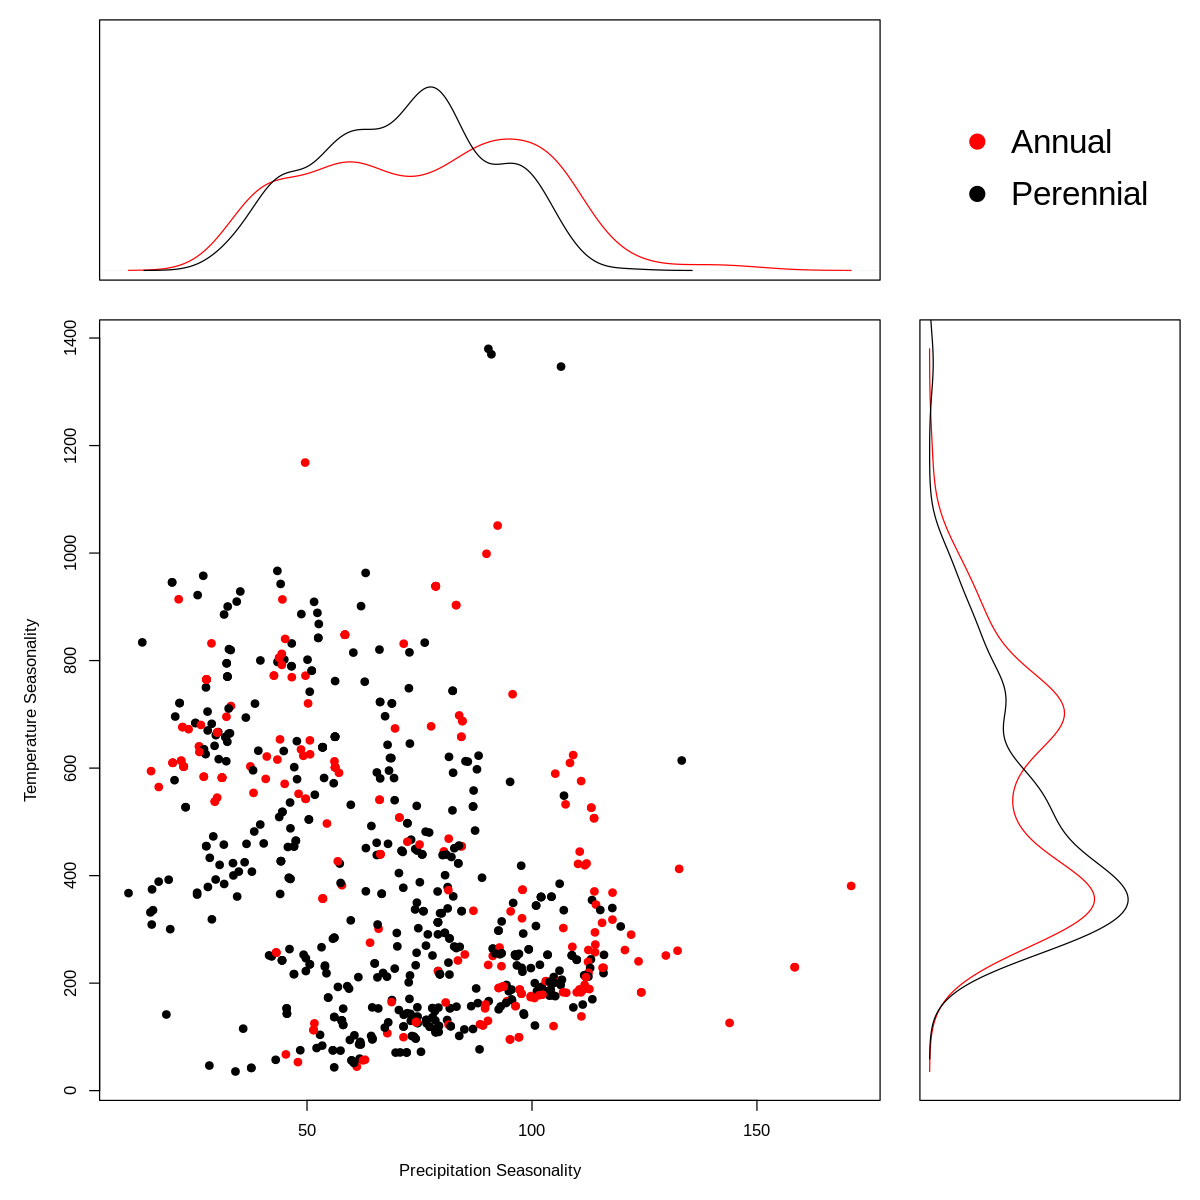

In [41]:
layout(matrix(1:4,2,2),widths = c(3,1),heights = c(1,3))
par(mar = c(1,5,1,1))
plot(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"]),
     type ='l',col = "red",main = '',xaxt ='n',yaxt = 'n',xlab = '',ylab = '',ylim = c(0,.02))
points(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"]),
     type ='l',col = "black")
par(mar = c(5,5,1,1))
plot(mergedData$bio15_Precipitation_Seasonality_quan50,
     mergedData$bio04_Temperature_Seasonality_quan50,
     pch  = 19, col = ifelse(mergedData$lifeHistoryNumeric=="1","red","black"),
     xlab = "Precipitation Seasonality",ylab = "Temperature Seasonality")
plot(1,1,type = 'n',axes = F,xlab = '',ylab ='')
par(mar = c(1,1,1,1))
legend(0.3,1.1,legend = c("Annual","Perennial"),col = c("red","black"),pch = 19,bty ='n',cex = 2)
par(mar = c(5,1,1,1))
d1 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"])
d2 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"])
plot(d1$y,d1$x,type ='l',col = "red",xlim = c(0,.0025),xlab = '',ylab = '',xaxt = 'n',yaxt = 'n')
points(d2$y,d2$x,type ='l',col = "black")

In [25]:
mycol = rep(NA,nrow(mergedData))
mycol[mergedData$bio01_Annual_Mean_Temperature_quan50>18] = "darkred"
mycol[mergedData$bio01_Annual_Mean_Temperature_quan50<18] = "darkblue"
mypch = ifelse(mergedData$lifeHistoryNumeric=="1",1,19)

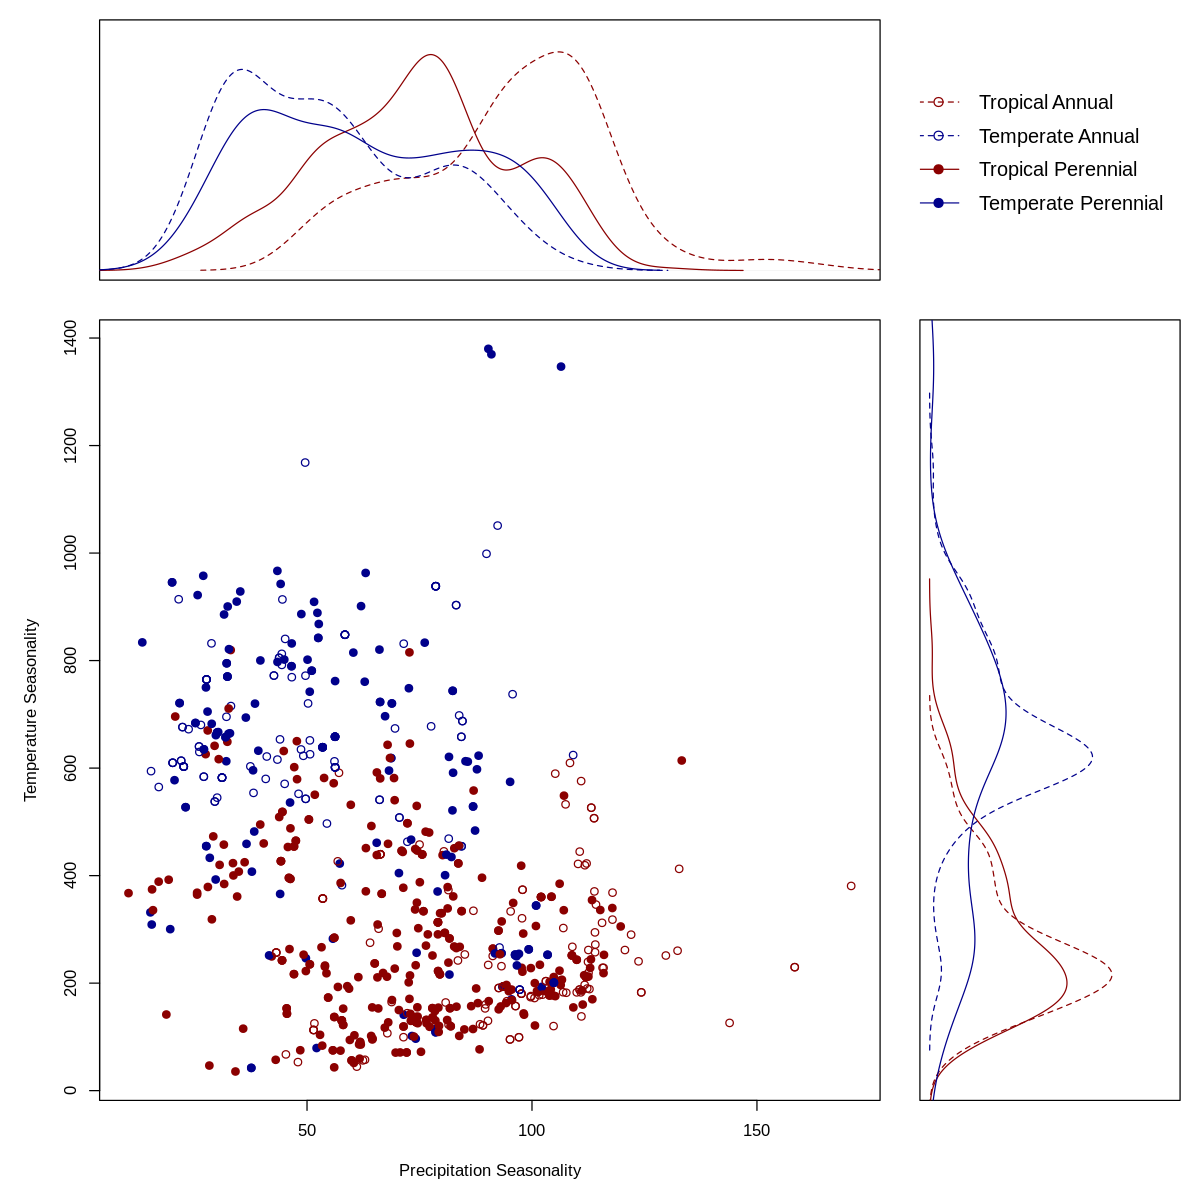

In [28]:
options(repr.plot.width=10, repr.plot.height=10)

layout(matrix(1:4,2,2),widths = c(3,1),heights = c(1,3))
par(mar = c(1,5,1,1))
plot(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred",main = '',xaxt ='n',yaxt = 'n',xlab = '',ylab = '',ylim = c(0,.02),xlim = c(0,180),lty=2)
points(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue",lty =2)
points(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred")
points(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue")


par(mar = c(5,5,1,1))
plot(mergedData$bio15_Precipitation_Seasonality_quan50,
     mergedData$bio04_Temperature_Seasonality_quan50,
     pch  = mypch, col = mycol,
     xlab = "Precipitation Seasonality",ylab = "Temperature Seasonality")
plot(1,1,type = 'n',axes = F,xlab = '',ylab ='')
par(mar = c(1,1,1,1))
legend(0.15,1.2,legend = c("Tropical Annual","Temperate Annual","Tropical Perennial","Temperate Perennial"),
       col = c("darkred","darkblue","darkred","darkblue"),pch = c(1,1,19,19),lty=c(2,2,1,1),bty ='n',cex = 1.2)
par(mar = c(5,1,1,1))
d1 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d2 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
d3 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d4 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
plot(d1$y,d1$x,type ='l',col = "darkred",xlim = c(0,.005),ylim = c(0,1400),xlab = '',ylab = '',xaxt = 'n',yaxt = 'n',lty =2)
points(d2$y,d2$x,type ='l',col = "darkblue",lty= 2)
points(d3$y,d3$x,type ='l',col = "darkred")
points(d4$y,d4$x,type ='l',col = "darkblue")

In [37]:
png("/workdir/sh2246/p_phyloGWAS/output/lifeHistorySeasonalityAss.png",width = 17.4,height = 17.4,units = "cm",res = 600,pointsize = 8)
layout(matrix(1:4,2,2),widths = c(3,1),heights = c(1,3))
par(mar = c(1,5,1,1))
plot(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred",main = '',xaxt ='n',yaxt = 'n',xlab = '',ylab = '',ylim = c(0,.02),xlim = c(0,180),lty=2)
points(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue",lty =2)
points(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred")
points(density(mergedData$bio15_Precipitation_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue")


par(mar = c(5,5,1,1))
plot(mergedData$bio15_Precipitation_Seasonality_quan50,
     mergedData$bio04_Temperature_Seasonality_quan50,
     pch  = mypch, col = mycol,
     xlab = "Precipitation Seasonality",ylab = "Temperature Seasonality")
plot(1,1,type = 'n',axes = F,xlab = '',ylab ='')
par(mar = c(1,1,1,1))
legend(0.17,1.1,legend = c("Tropical Annual","Temperate Annual","Tropical Perennial","Temperate Perennial"),y.intersp = 2,
       col = c("darkred","darkblue","darkred","darkblue"),pch = c(1,1,19,19),lty=c(2,2,1,1),bty ='n',pt.cex = 1,cex = 1.25,seg.len = 3)
par(mar = c(5,1,1,1))
d1 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d2 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
d3 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d4 = density(mergedData$bio04_Temperature_Seasonality_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
plot(d1$y,d1$x,type ='l',col = "darkred",xlim = c(0,.005),ylim = c(0,1400),xlab = '',ylab = '',xaxt = 'n',yaxt = 'n',lty =2)
points(d2$y,d2$x,type ='l',col = "darkblue",lty= 2)
points(d3$y,d3$x,type ='l',col = "darkred")
points(d4$y,d4$x,type ='l',col = "darkblue")
dev.off()

png 
  2

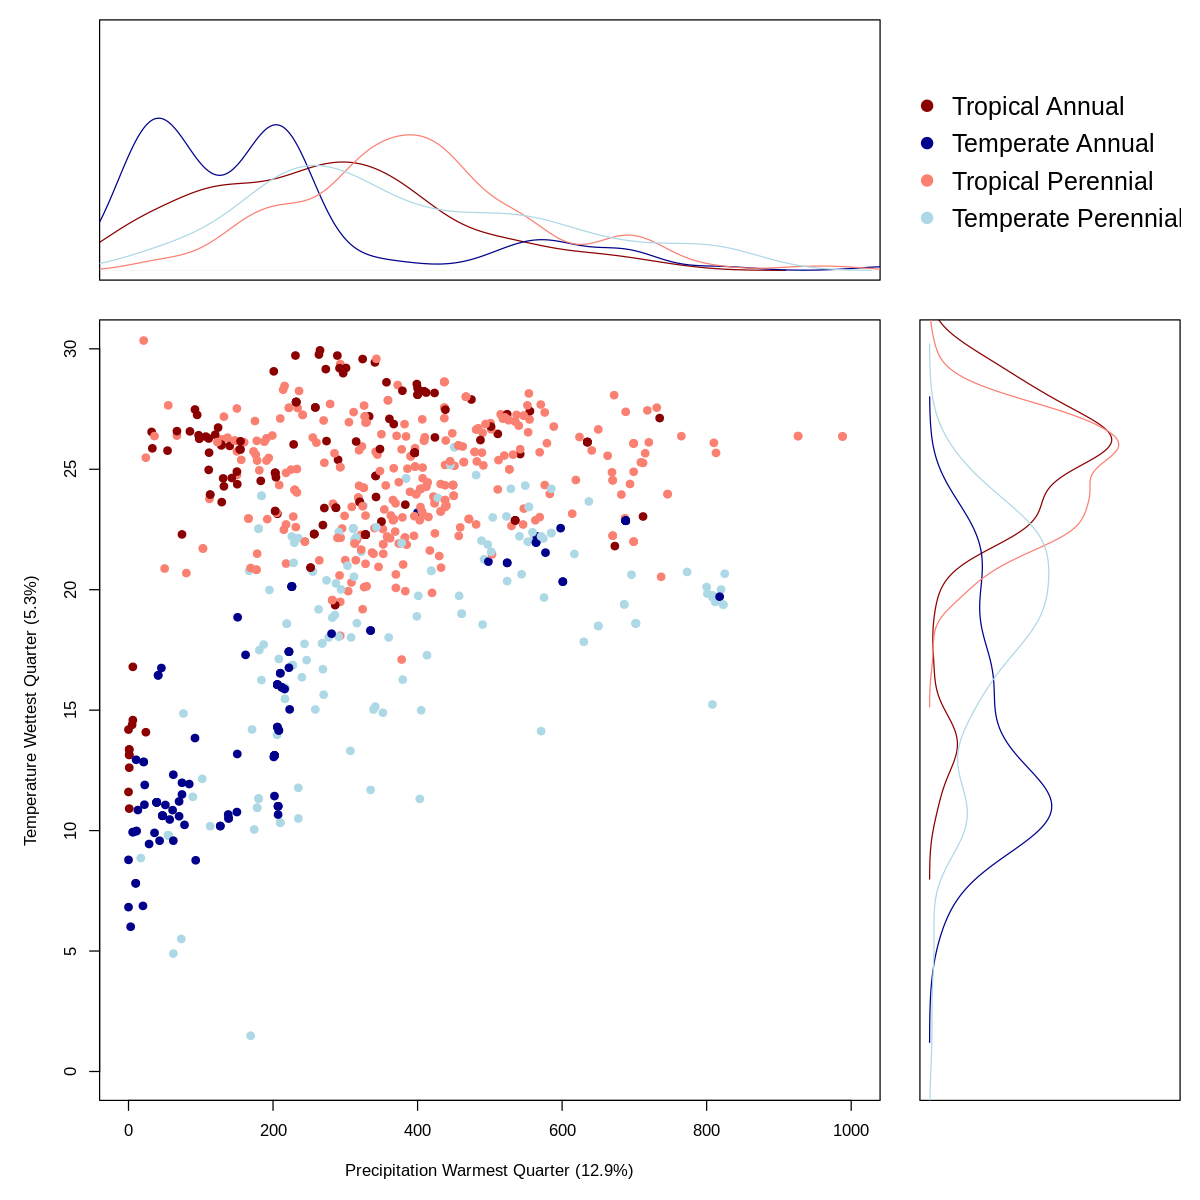

In [145]:
options(repr.plot.width=10, repr.plot.height=10)

layout(matrix(1:4,2,2),widths = c(3,1),heights = c(1,3))
par(mar = c(1,5,1,1))
plot(density(mergedData$bio18_Precipitation_Warmest_Quarter_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred",main = '',xaxt ='n',yaxt = 'n',xlab = '',ylab = '',ylim = c(0,.005),xlim = c(0,1000))
points(density(mergedData$bio18_Precipitation_Warmest_Quarter_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue")
points(density(mergedData$bio18_Precipitation_Warmest_Quarter_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "salmon")
points(density(mergedData$bio18_Precipitation_Warmest_Quarter_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "lightblue")


par(mar = c(5,5,1,1))
plot(mergedData$bio18_Precipitation_Warmest_Quarter_quan50,
     mergedData$bio08_Mean_Temperature_Wettest_Quarter_quan50,
     pch  = 19, col = mycol,xlim = c(0,1000),ylim = c(0,30),
     xlab = "Precipitation Warmest Quarter (12.9%)",ylab = "Temperature Wettest Quarter (5.3%)")
plot(1,1,type = 'n',axes = F,xlab = '',ylab ='')
par(mar = c(1,1,1,1))
legend(0.1,1.2,legend = c("Tropical Annual","Temperate Annual","Tropical Perennial","Temperate Perennial"),
       col = c("darkred","darkblue","salmon","lightblue"),pch = 19,bty ='n',cex = 1.5)
par(mar = c(5,1,1,1))
d1 = density(mergedData$bio08_Mean_Temperature_Wettest_Quarter_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d2 = density(mergedData$bio08_Mean_Temperature_Wettest_Quarter_quan50[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
d3 = density(mergedData$bio08_Mean_Temperature_Wettest_Quarter_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d4 = density(mergedData$bio08_Mean_Temperature_Wettest_Quarter_quan50[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
plot(d1$y,d1$x,type ='l',col = "darkred",xlim = c(0,.2),ylim = c(0,30),xlab = '',ylab = '',xaxt = 'n',yaxt = 'n')
points(d2$y,d2$x,type ='l',col = "darkblue")
points(d3$y,d3$x,type ='l',col = "salmon")
points(d4$y,d4$x,type ='l',col = "lightblue")

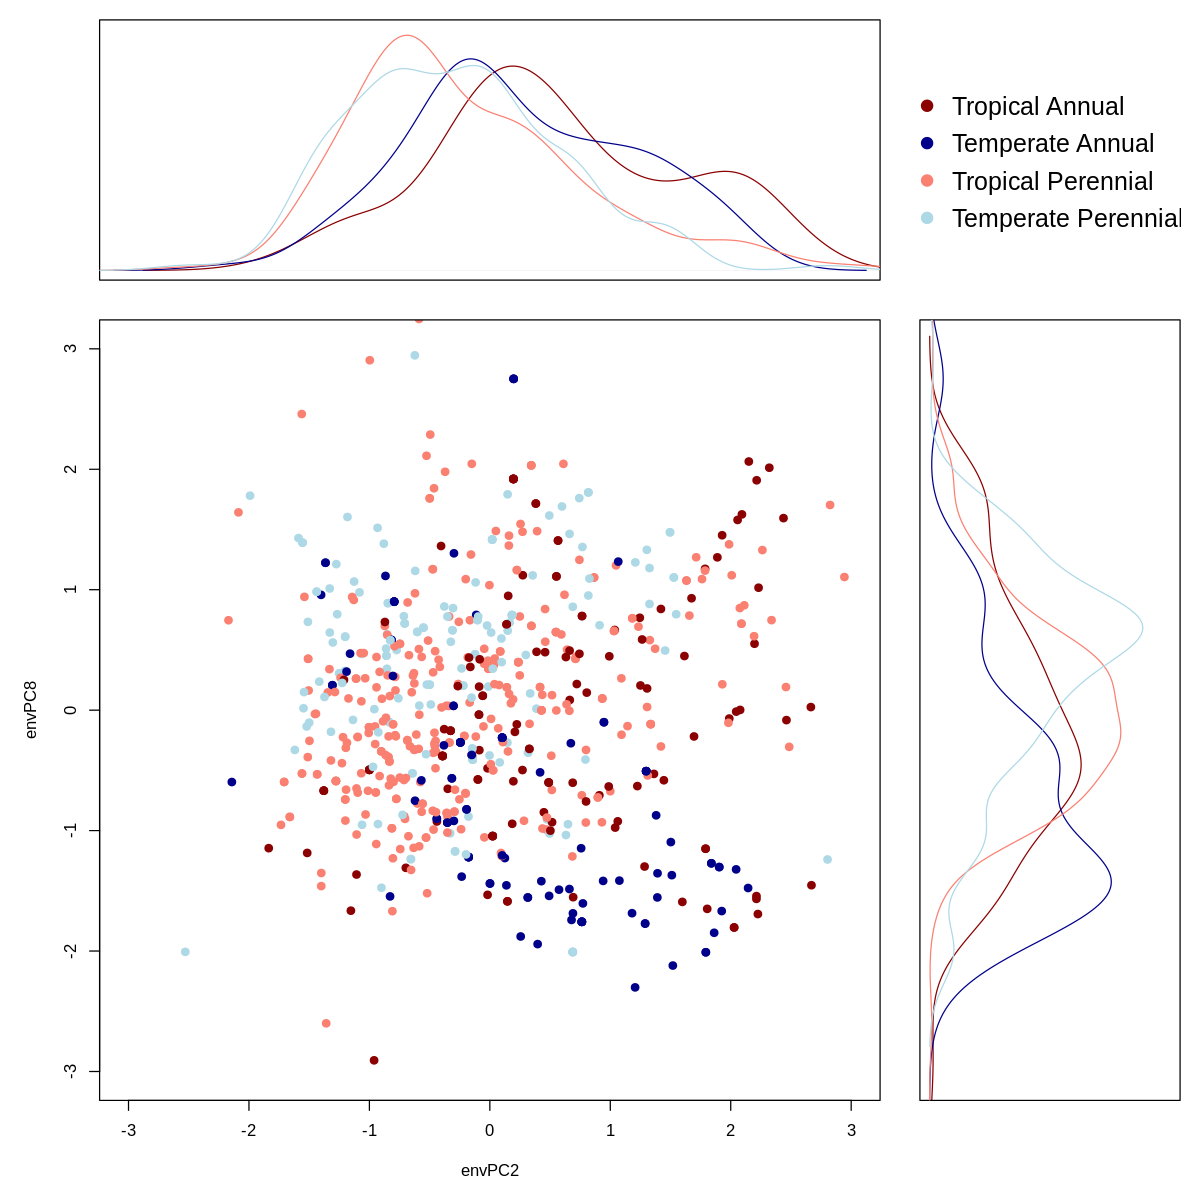

In [141]:
options(repr.plot.width=10, repr.plot.height=10)

layout(matrix(1:4,2,2),widths = c(3,1),heights = c(1,3))
par(mar = c(1,5,1,1))
plot(density(mergedData$envPC_2[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "darkred",main = '',xaxt ='n',yaxt = 'n',xlab = '',ylab = '',ylim = c(0,.5),xlim = c(-3,3))
points(density(mergedData$envPC_2[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "darkblue")
points(density(mergedData$envPC_2[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18]),
     type ='l',col = "salmon")
points(density(mergedData$envPC_2[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18]),
     type ='l',col = "lightblue")


par(mar = c(5,5,1,1))
plot(mergedData$envPC_2,
     mergedData$envPC_8,
     pch  = 19, col = mycol,xlim = c(-3,3),ylim = c(-3,3),
     xlab = "envPC2 (8.9%)",ylab = "envPC8 (5.6%)")
plot(1,1,type = 'n',axes = F,xlab = '',ylab ='')
par(mar = c(1,1,1,1))
legend(0.1,1.2,legend = c("Tropical Annual","Temperate Annual","Tropical Perennial","Temperate Perennial"),
       col = c("darkred","darkblue","salmon","lightblue"),pch = 19,bty ='n',cex = 1.5)
par(mar = c(5,1,1,1))
d1 = density(mergedData$envPC_8[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d2 = density(mergedData$envPC_8[mergedData$lifeHistoryNumeric=="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
d3 = density(mergedData$envPC_8[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50>18])
d4 = density(mergedData$envPC_8[mergedData$lifeHistoryNumeric!="1"&mergedData$bio01_Annual_Mean_Temperature_quan50<18])
plot(d1$y,d1$x,type ='l',col = "darkred",xlim = c(0,.6),ylim = c(-3,3),xlab = '',ylab = '',xaxt = 'n',yaxt = 'n')
points(d2$y,d2$x,type ='l',col = "darkblue")
points(d3$y,d3$x,type ='l',col = "salmon")
points(d4$y,d4$x,type ='l',col = "lightblue")

In [135]:
ppcor::pcor(cbind(mergedData$lifeHistoryNumeric,
                  mergedData$bio18_Precipitation_Warmest_Quarter_quan50,
                  mergedData$bio08_Mean_Temperature_Wettest_Quarter_quan50))$estimate^2

1.00000000,0.08741548,0.00852687
0.08741548,1.00000000,0.14263935
0.00852687,0.14263935,1.00000000


In [142]:
ppcor::pcor(cbind(mergedData$lifeHistoryNumeric,
                  mergedData$envPC_2,
                  mergedData$envPC_8))$estimate^2

1.00000000,0.091935218,0.059122726
0.09193522,1.000000000,0.003483384
0.05912273,0.003483384,1.000000000


In [108]:
mycol2 = rep(NA,nrow(mergedData))
mycol2[mergedData$latest_name%in%"Zea diploperennis"] = "yellow"
mycol2[mergedData$latest_name%in%"Zea mays"] = "darkorange"
mycol2[mergedData$latest_name%in%"Sorghum halepense"] = "salmon"
mycol2[mergedData$latest_name%in%"Sorghum bicolor"] = "darkred"
mycol2[mergedData$latest_name%in%"Oryza rufipogon"] = "lightgreen"
mycol2[mergedData$latest_name%in%"Oryza sativa"] = "darkgreen"
mycol2[mergedData$latest_name%in%"Panicum hallii"] = "lightblue"
mycol2[mergedData$latest_name%in%"Panicum miliaceum"] = "darkblue"
mycol2[mergedData$latest_name%in%"Thinopyrum elongatum"] = "pink"
mycol2[mergedData$latest_name%in%"Triticum aestivum"] = "purple"

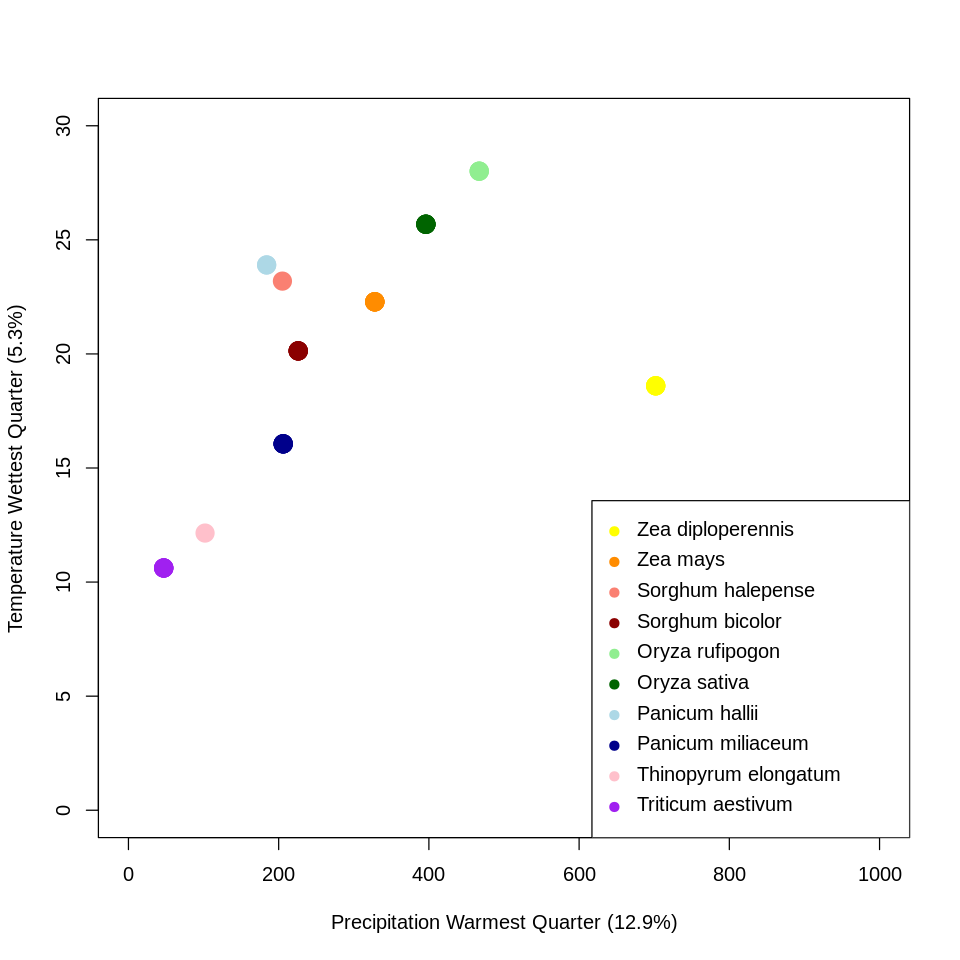

In [144]:
options(repr.plot.width=8, repr.plot.height=8)

plot(mergedData$bio18_Precipitation_Warmest_Quarter_quan50,
     mergedData$bio08_Mean_Temperature_Wettest_Quarter_quan50,
     pch  = 19, col = mycol2,xlim = c(0,1000),ylim = c(0,30),cex = 2,
     xlab = "Precipitation Warmest Quarter (12.9%)",ylab = "Temperature Wettest Quarter (5.3%)")
legend("bottomright",legend = c("Zea diploperennis","Zea mays",
                             "Sorghum halepense","Sorghum bicolor",
                             "Oryza rufipogon","Oryza sativa",
                             "Panicum hallii","Panicum miliaceum",
                             "Thinopyrum elongatum", "Triticum aestivum"),
       col = c("yellow","darkorange","salmon","darkred","lightgreen","darkgreen",
               "lightblue","darkblue","pink","purple"),
       pch = 19,cex = 1)

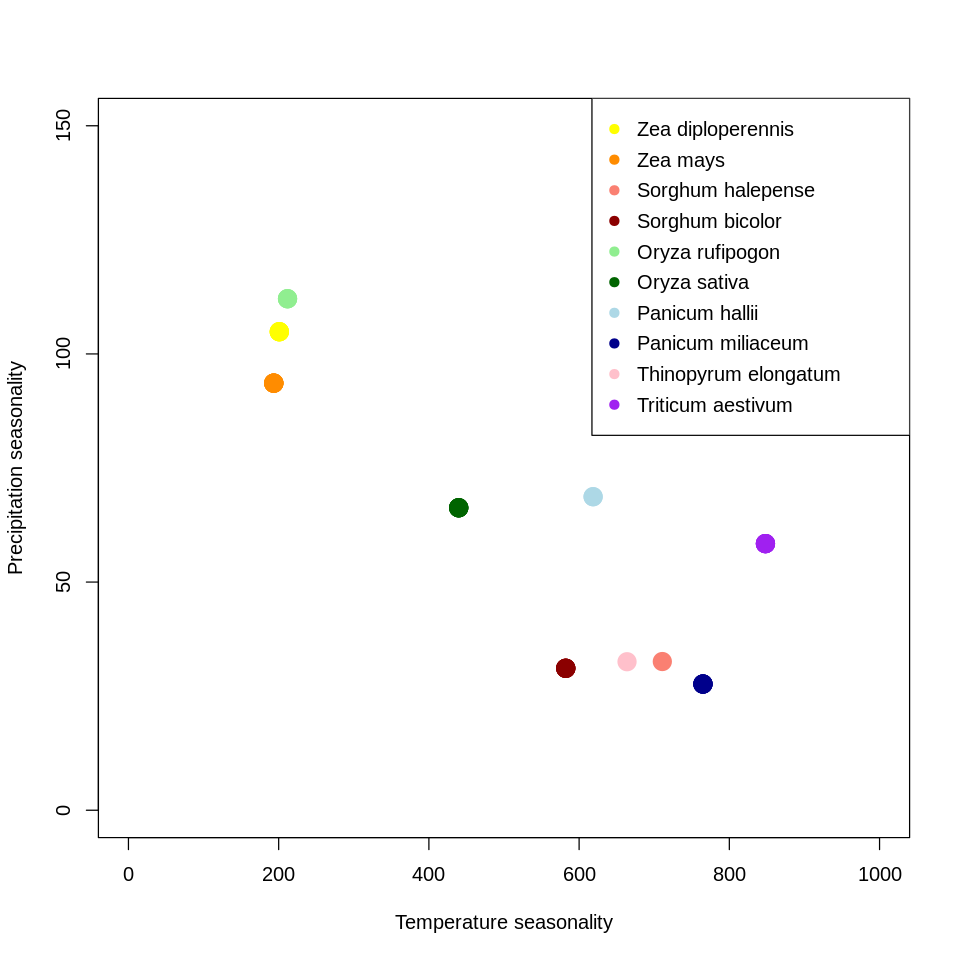

In [153]:
options(repr.plot.width=8, repr.plot.height=8)

plot(mergedData$bio04_Temperature_Seasonality_quan50,
     mergedData$bio15_Precipitation_Seasonality_quan50,
     pch  = 19, col = mycol2,xlim = c(0,1000),ylim = c(0,150),cex = 2,
     xlab = "Temperature seasonality",ylab = "Precipitation seasonality")
legend("topright",legend = c("Zea diploperennis","Zea mays",
                             "Sorghum halepense","Sorghum bicolor",
                             "Oryza rufipogon","Oryza sativa",
                             "Panicum hallii","Panicum miliaceum",
                             "Thinopyrum elongatum", "Triticum aestivum"),
       col = c("yellow","darkorange","salmon","darkred","lightgreen","darkgreen",
               "lightblue","darkblue","pink","purple"),
       pch = 19,cex = 1)

In [45]:
quan50Idx = grep("quan50",colnames(mergedData))

corRes = c()
for (i in quan50Idx){
    tmp = cor.test(mergedData$lifeHistoryNumeric,mergedData[,i])
    corRes = rbind(corRes,c(tmp$estimate,tmp$p.value))
}


Warning message in cor(x, y):
“the standard deviation is zero”


In [51]:
ePCIdx = grep("PC",colnames(mergedData))

corRes2 = c()
for (i in ePCIdx){
    tmp = cor.test(mergedData$lifeHistoryNumeric,mergedData[,i])
    corRes2 = rbind(corRes2,c(tmp$estimate,tmp$p.value))
}


In [52]:
rownames(corRes) = gsub("_quan50","",colnames(mergedData)[quan50Idx])
rownames(corRes2) = colnames(mergedData)[ePCIdx]

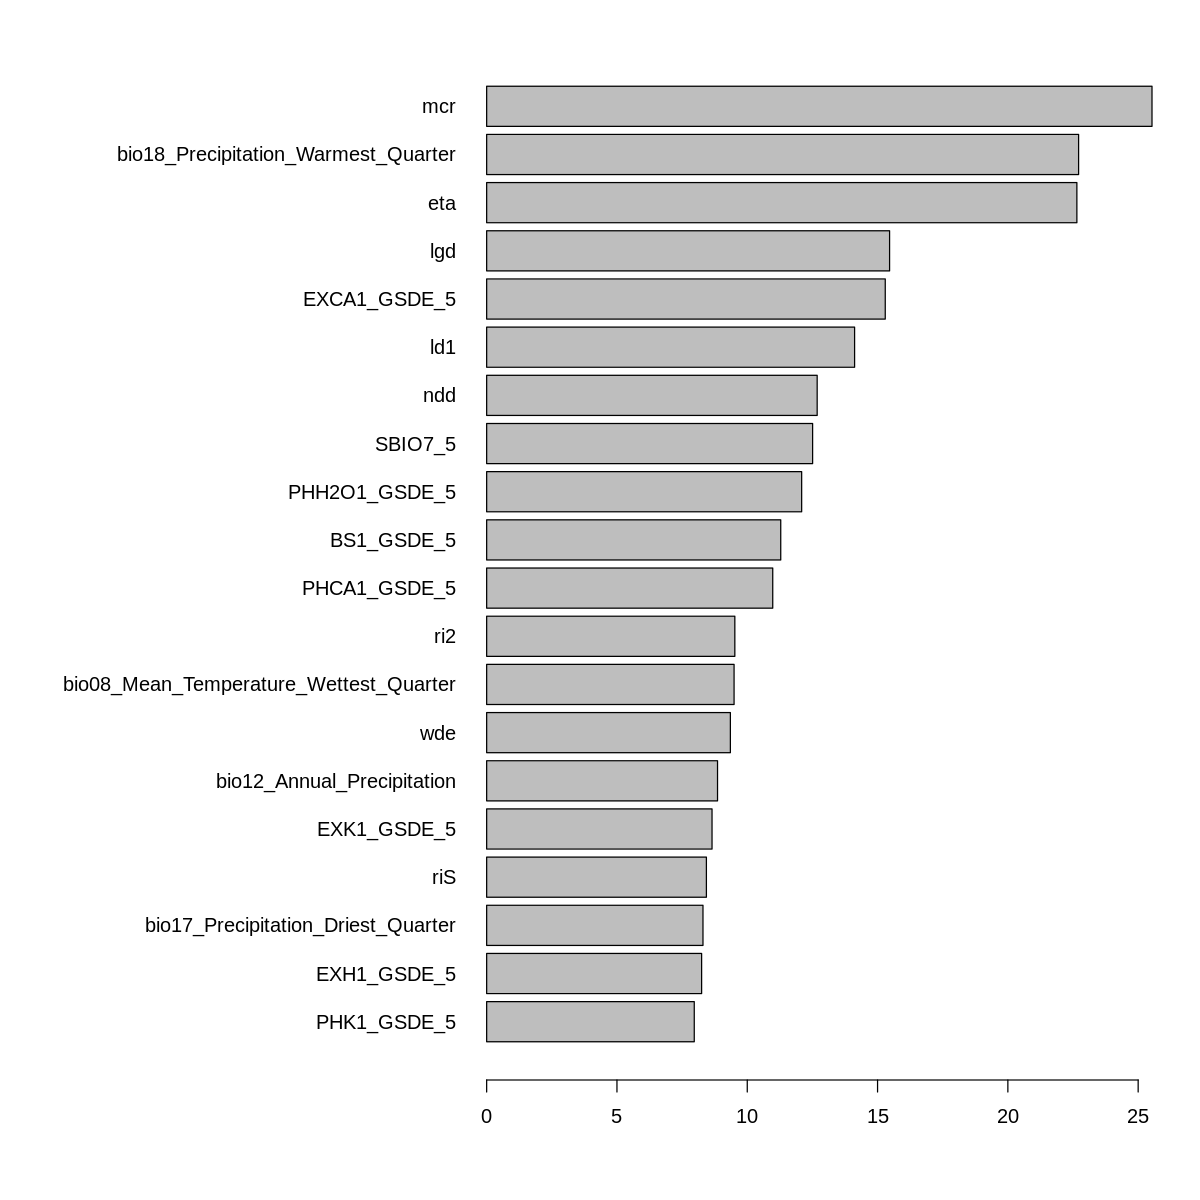

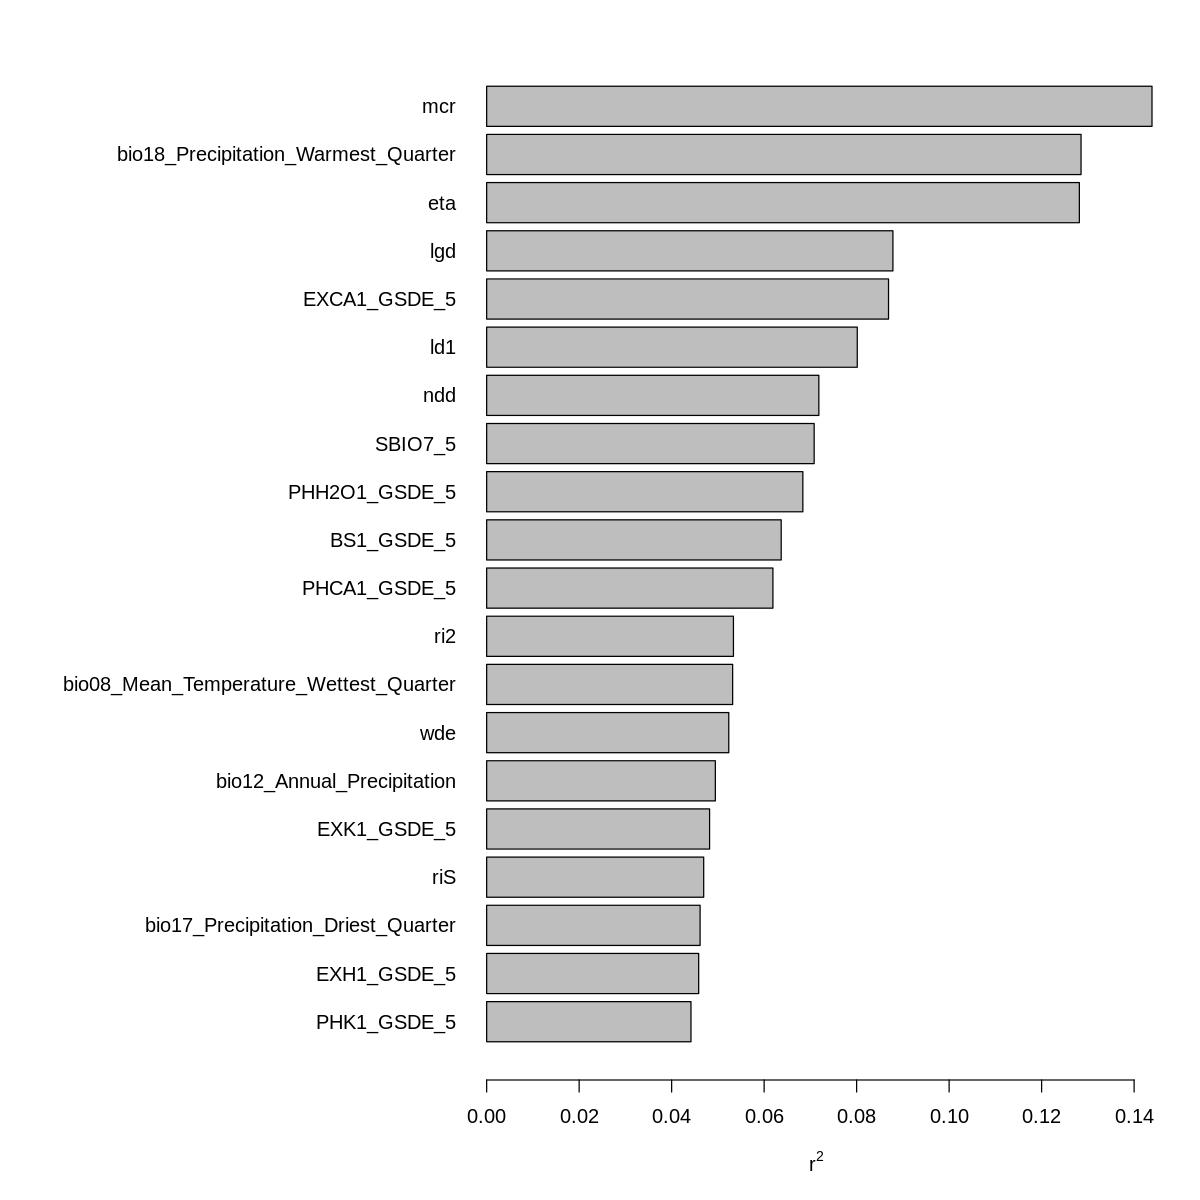

In [53]:
options(repr.plot.width=10, repr.plot.height=10)
par(mar = c(5,20,2,2))
barplot(tail(sort(-log10(corRes[,2])),20),horiz = T,las = 1)
barplot(tail(sort(corRes[,1]^2),20),horiz = T,las = 1,xlab = expression(r^2))

In [143]:
tail(sort(corRes[,1]^2),10)
tail(sort(corRes2[,1]^2),10)

BS1_GSDE_5                       PHH2O1_GSDE_5 
                         0.06369153                          0.06837237 
                            SBIO7_5                                 ndd 
                         0.07081767                          0.07183231 
                                ld1                        EXCA1_GSDE_5 
                         0.08013791                          0.08689732 
                                lgd                                 eta 
                         0.08784780                          0.12816394 
bio18_Precipitation_Warmest_Quarter                                 mcr 
                         0.12852670                          0.14386907

envPC_19    envPC_28     envPC_4     envPC_3    envPC_32    envPC_17 
0.008027028 0.008195189 0.011957758 0.013776192 0.014523861 0.018206663 
    envPC_6     envPC_9     envPC_8     envPC_2 
0.020992118 0.035120000 0.056072807 0.088991663

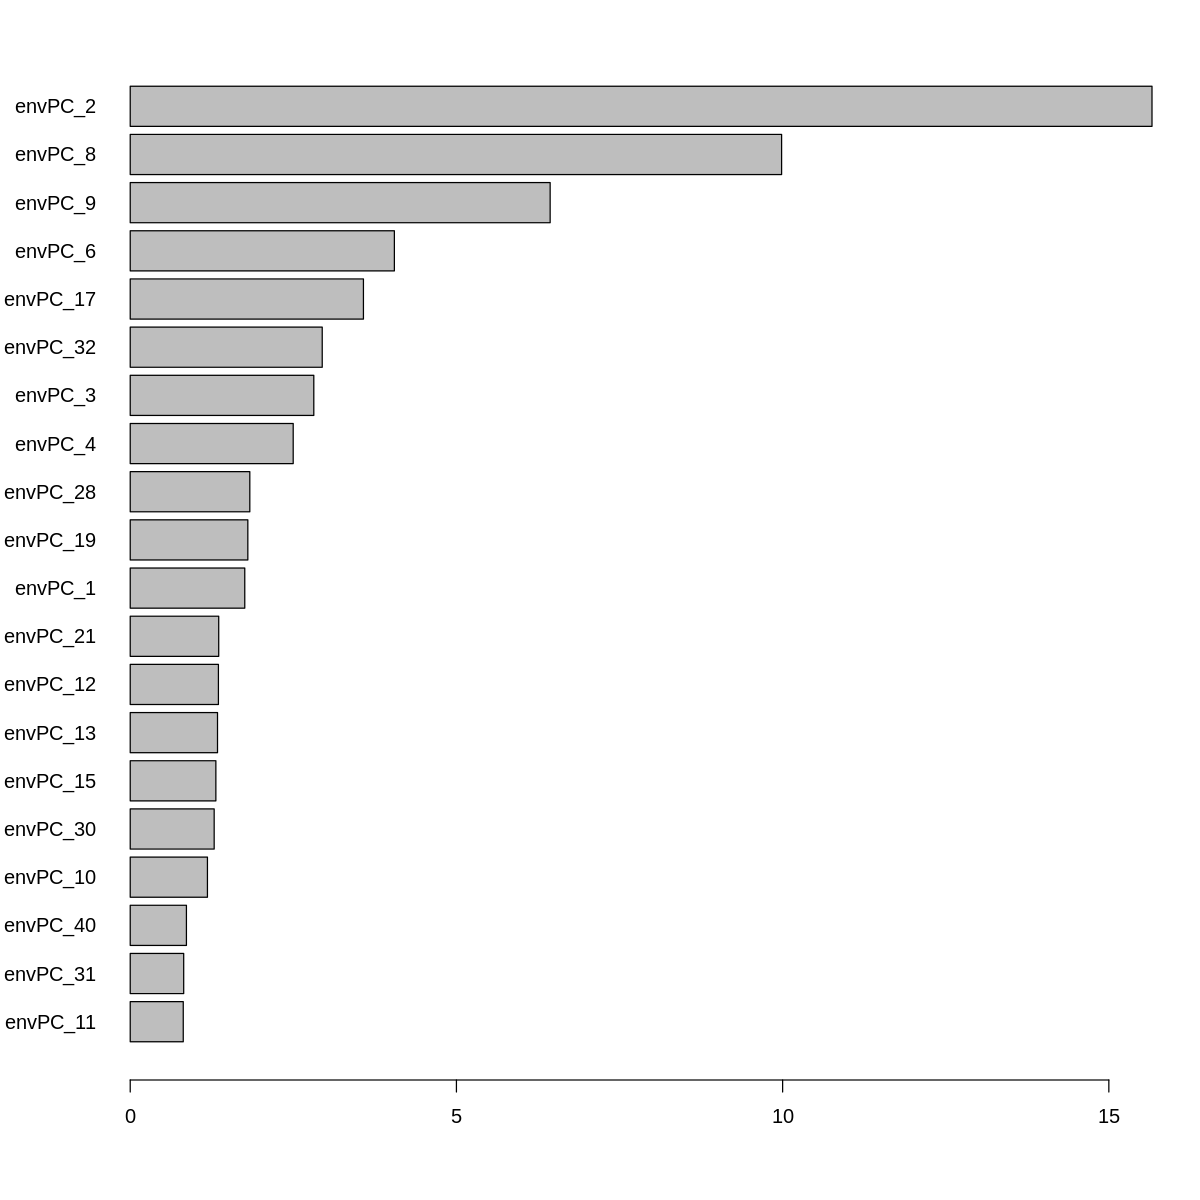

png 
  2

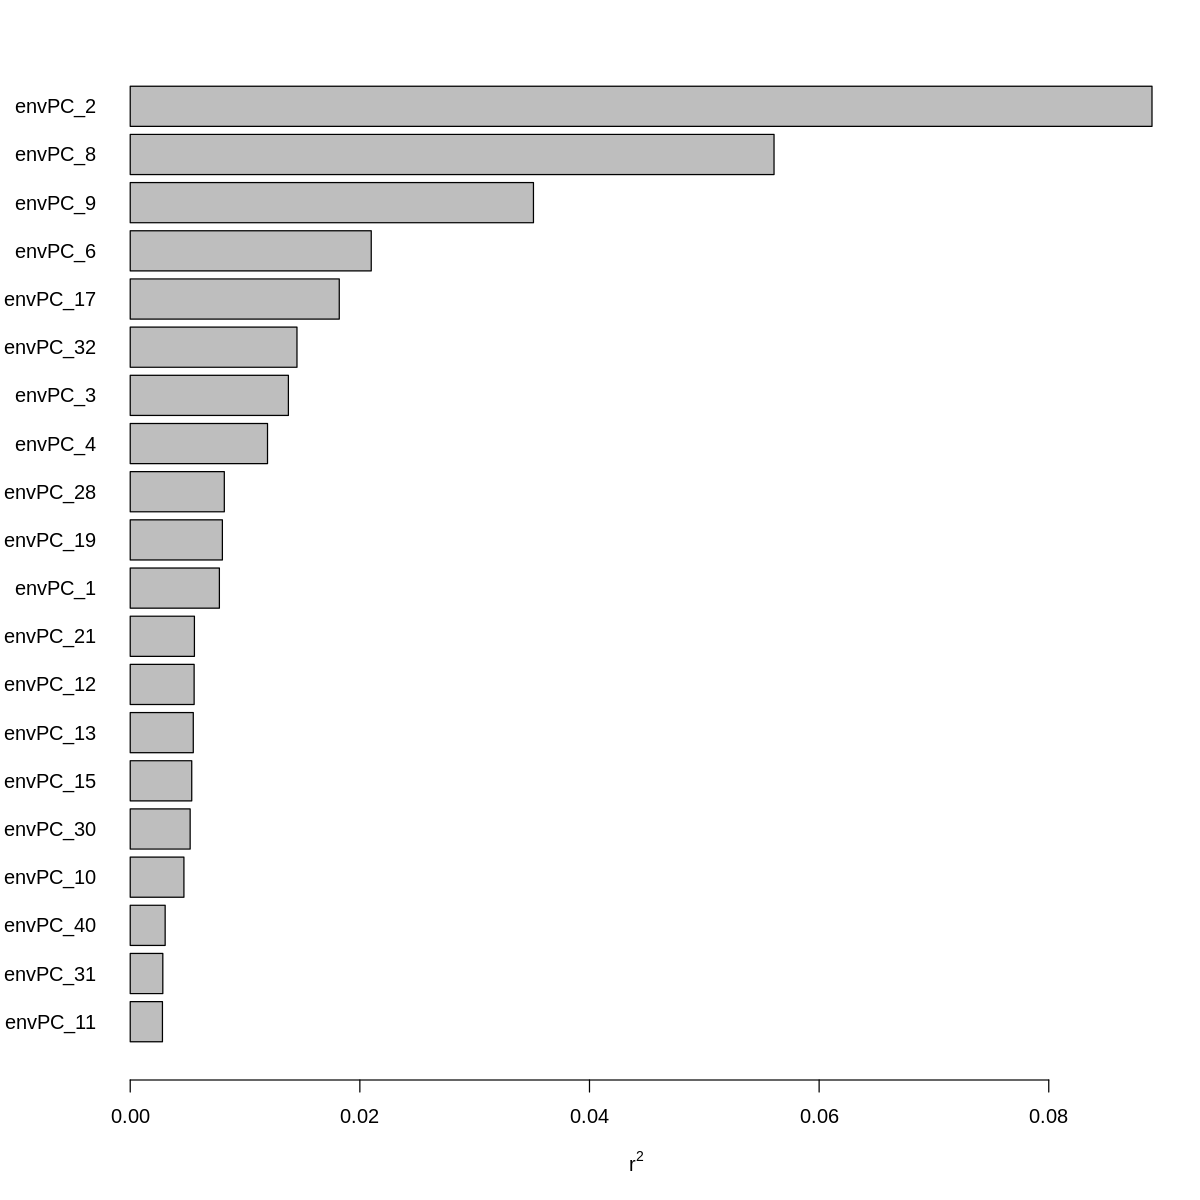

In [54]:
options(repr.plot.width=10, repr.plot.height=10)
par(mar = c(5,5,2,2))
barplot(tail(sort(-log10(corRes2[,2])),20),horiz = T,las = 1)
barplot(tail(sort(corRes2[,1]^2),20),horiz = T,las = 1,xlab = expression(r^2))
png("/workdir/sh2246/p_phyloGWAS/output/envPC_perenniality_association.png",width = 16,height = 16, units = "cm",res = 600,pointsize = 8)
par(mar = c(5,8,2,2))
barplot(tail(sort(corRes2[,1]^2),20),horiz = T,las = 1,xlab = expression(r^2))
dev.off()

In [535]:
write.table(ePCs$variable.components,"/workdir/sh2246/p_phyloGWAS/output/envPC_loading_mat.txt",sep = "\t",col.names = T,row.names = T,quote = F)

In [60]:
tmpX = apply(eTraits_filtered[,1:285],2,function(x) scale(x))
tmpX[is.na(tmpX)] = 0

In [78]:
y2 = ePCs$variable.components[seq(2,285,3),3]%*%t(tmpX[,seq(2,285,3)])

[1] 0.7313954

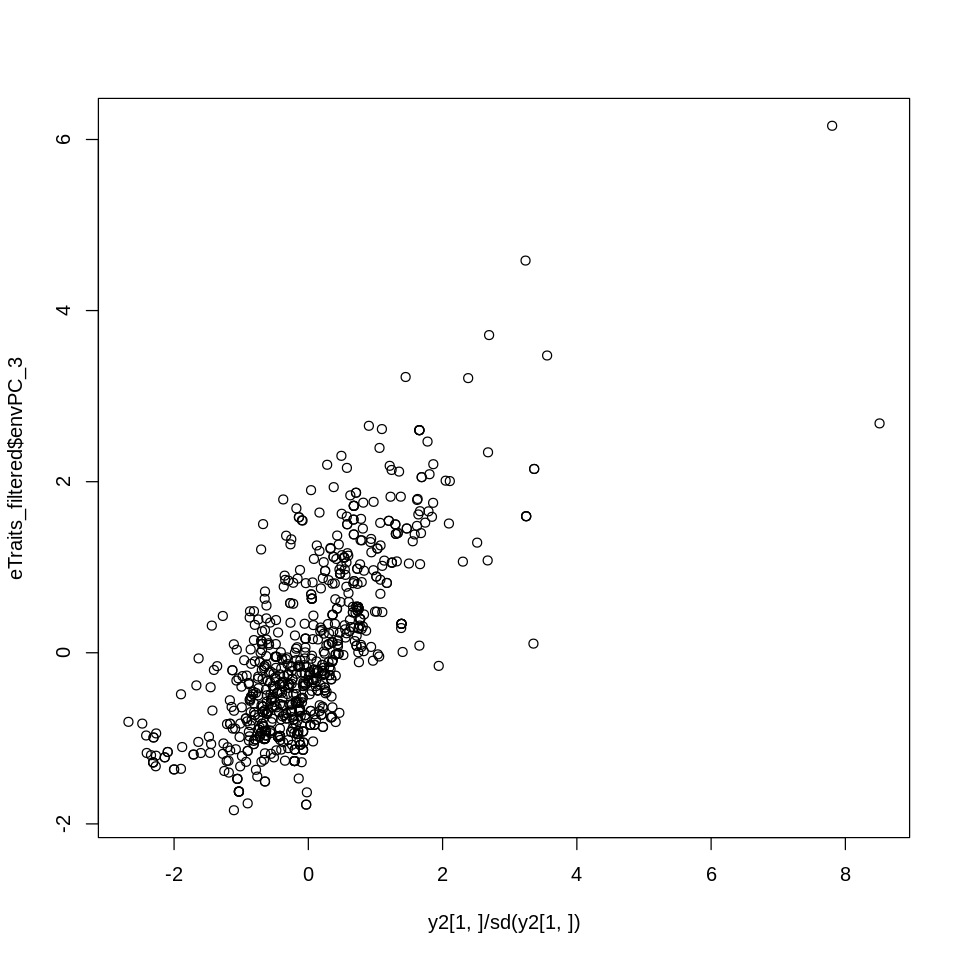

In [79]:
plot(y2[1,]/sd(y2[1,]),eTraits_filtered$envPC_3)
cor(y2[1,],eTraits_filtered$envPC_3)

In [317]:
ePCIdx

[1] 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304
[20] 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323
[39] 324 325

In [320]:
summary(lm(as.numeric(traitMat[commonID2,2])~eTraits_filtered[commonID2,287]+eTraits_filtered[commonID2,293] +eTraits_filtered[commonID2,294]))

Warning message in eval(predvars, data, env):
“NAs introduced by coercion”



Call:
lm(formula = as.numeric(traitMat[commonID2, 2]) ~ eTraits_filtered[commonID2, 
    287] + eTraits_filtered[commonID2, 293] + eTraits_filtered[commonID2, 
    294])

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9952 -0.3953  0.1765  0.3048  0.7585 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                       1.66387    0.01606 103.606  < 2e-16 ***
eTraits_filtered[commonID2, 287] -0.13336    0.01597  -8.352 3.59e-16 ***
eTraits_filtered[commonID2, 293]  0.12307    0.01599   7.698 4.71e-14 ***
eTraits_filtered[commonID2, 294] -0.08824    0.01566  -5.635 2.54e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4261 on 700 degrees of freedom
  (19 observations deleted due to missingness)
Multiple R-squared:   0.19,	Adjusted R-squared:  0.1865 
F-statistic: 54.73 on 3 and 700 DF,  p-value: < 2.2e-16


In [122]:
tail(na.omit(ePCs$variable.correlation[order(ePCs$variable.correlation[,2]^2),]),20)

,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,envPC_10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
bio12_Annual_Precipitation_quan50,0.49698,-0.73717,0.05438,0.02163,0.17273,0.17871,0.08826,-0.00052,0.03919,0.13070,⋯,0.03223,-0.02841,-0.01952,0.01356,-0.03092,0.01126,0.00650,-0.01658,0.00545,-0.07451
ld1_quan10,0.21701,-0.78126,0.20526,-0.00128,0.31496,-0.19370,-0.03352,-0.01335,-0.01094,-0.15971,⋯,-0.01205,-0.05291,0.02948,0.05905,-0.00371,-0.04824,0.01410,0.06020,-0.04246,0.05886
lgd_quan10,0.13777,-0.78505,0.17629,0.02496,0.34124,-0.23627,-0.03548,-0.04169,0.01569,-0.19695,⋯,-0.02630,-0.07531,0.00841,0.05065,-0.00415,-0.02065,0.00321,0.02617,-0.02213,0.06952
rid_quan90,0.00251,-0.79022,-0.19562,0.12997,-0.08838,0.26281,0.14334,-0.08572,0.00458,0.18055,⋯,0.06852,0.10628,0.04694,-0.05944,0.09746,-0.02249,-0.04930,-0.01522,0.04437,0.06617
SBIO2_5_quan10,-0.11467,0.79271,0.27561,-0.26190,0.07713,-0.01081,-0.07192,0.20004,0.03661,-0.01090,⋯,0.01551,-0.01844,-0.03071,-0.02074,0.00230,0.01360,-0.02708,-0.04404,0.02773,0.03814
ri2_quan10,0.12541,-0.79590,0.35543,-0.09972,0.29642,0.11180,0.01167,0.07200,0.00232,0.02331,⋯,-0.01438,0.03758,-0.07915,-0.00797,0.01441,0.06415,-0.00612,0.00271,-0.00088,0.06156
ndr_quan90,0.06031,-0.80149,-0.28832,0.13739,-0.16726,0.13754,0.12398,-0.17149,-0.02868,0.01635,⋯,0.03521,0.08627,-0.00090,0.02001,0.03839,0.08139,0.00958,0.04172,0.02706,-0.02502
SBIO2_5_quan90,0.01552,0.80552,-0.26959,-0.11833,-0.26046,0.09512,0.07067,0.15702,-0.02644,-0.00494,⋯,0.05952,0.03247,0.00386,-0.00707,0.03094,0.02963,0.02248,-0.00595,0.01893,-0.04386
ri2_quan90,0.11727,-0.80667,-0.17311,0.10078,-0.09989,0.27842,0.16331,-0.04047,-0.02606,0.14369,⋯,0.03183,0.09064,0.04026,-0.07967,0.06438,-0.02736,-0.03944,0.00683,0.05635,0.08489


In [123]:
tail(na.omit(ePCs$variable.correlation[order(ePCs$variable.correlation[,8]^2),]),20)

,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,envPC_10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CEC1_GSDE_5_quan90,-0.13844,-0.06339,-0.22971,0.39332,0.09929,-0.25253,0.20270,0.34769,0.43677,0.11741,⋯,0.07509,0.02412,-0.05445,0.09601,-0.09223,-0.04558,0.03279,0.03976,0.05290,0.04784
TN1_GSDE_5_quan90,-0.10971,-0.37709,-0.18078,0.18994,0.00665,-0.25913,0.17572,0.34940,0.39898,0.17296,⋯,0.04455,0.06719,-0.04578,0.06933,0.12881,-0.11347,0.02814,0.04749,0.07703,0.04171
SBIO8_5_quan50,0.72690,0.02873,-0.30506,-0.06419,0.30965,0.13225,0.09277,0.34982,-0.16007,-0.02277,⋯,-0.02684,0.01156,-0.03923,-0.02365,0.04124,-0.00310,0.01824,-0.01860,-0.02349,0.01681
bio18_Precipitation_Warmest_Quarter_quan50,0.17726,-0.71546,-0.04241,-0.12466,0.12089,0.17056,0.01110,0.35457,-0.20149,-0.08681,⋯,0.06383,0.00359,0.00183,0.03829,0.03759,0.01951,0.02765,-0.02587,0.07837,-0.07484
SBIO9_15_quan90,0.64459,0.35939,-0.21371,0.27125,-0.10797,-0.03304,0.14459,-0.35492,0.18511,-0.01535,⋯,0.06630,0.01694,-0.00766,-0.01132,-0.04937,-0.00266,-0.05724,-0.00271,0.03747,0.06669
TN1_GSDE_5_quan50,-0.16114,-0.44337,0.16750,0.09325,0.04730,-0.04636,0.26705,0.35819,0.42334,0.10085,⋯,-0.01926,-0.16408,-0.13039,-0.10507,-0.01836,0.02446,-0.03218,-0.02503,0.06445,0.03991
SBIO8_15_quan90,0.63918,0.12709,-0.46600,-0.07423,0.13750,0.14672,0.14523,0.35944,-0.15839,-0.04255,⋯,-0.01293,0.01061,0.00781,-0.02290,0.02466,-0.00201,0.03867,-0.00022,0.01991,0.02560
TC1_GSDE_5_quan90,-0.16443,-0.37163,-0.13895,0.16953,0.08590,-0.23926,0.16322,0.36134,0.45340,0.17342,⋯,-0.03369,0.06320,-0.02629,-0.01148,0.09691,-0.11706,0.08227,0.05566,0.01182,-0.04146
bio08_Mean_Temperature_Wettest_Quarter_quan50,0.76250,-0.08989,-0.24497,-0.11983,0.27010,0.13814,0.08242,0.36802,-0.10391,-0.00322,⋯,-0.04942,0.02835,-0.02110,0.00525,0.02273,-0.01094,0.01863,-0.02278,-0.02185,0.00234


In [124]:
tail(na.omit(ePCs$variable.correlation[order(ePCs$variable.correlation[,9]^2),]),10)

,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,envPC_10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CEC1_GSDE_5_quan90,-0.13844,-0.06339,-0.22971,0.39332,0.09929,-0.25253,0.20270,0.34769,0.43677,0.11741,⋯,0.07509,0.02412,-0.05445,0.09601,-0.09223,-0.04558,0.03279,0.03976,0.05290,0.04784
OC1_GSDE_5_quan50,-0.16397,-0.45176,0.22784,0.09256,-0.06339,0.06521,0.21360,0.24647,0.43909,0.16466,⋯,-0.03640,-0.20842,-0.11211,-0.03722,-0.04951,0.07935,-0.05680,-0.01664,0.04187,-0.01602
TC1_GSDE_5_quan90,-0.16443,-0.37163,-0.13895,0.16953,0.08590,-0.23926,0.16322,0.36134,0.45340,0.17342,⋯,-0.03369,0.06320,-0.02629,-0.01148,0.09691,-0.11706,0.08227,0.05566,0.01182,-0.04146
TP1_GSDE_5_quan50,-0.29012,-0.07698,0.27507,0.23647,-0.05093,0.16261,0.12380,0.17537,0.46810,-0.02456,⋯,-0.02583,0.05390,0.08551,-0.09266,-0.07328,0.15098,0.00696,0.04582,-0.04576,-0.05069
TS1_GSDE_5_quan50,-0.00445,0.06652,0.31783,0.28866,0.04378,-0.34513,0.45139,0.03268,-0.52312,0.21747,⋯,-0.01989,-0.05697,0.01342,0.00278,0.05738,0.01822,0.02789,0.02079,0.06315,0.02988
ECE1_GSDE_5_quan50,-0.06666,0.23122,0.26688,0.28272,0.18940,-0.29008,0.44145,0.03848,-0.52861,0.24689,⋯,-0.02858,-0.00969,0.01314,-0.05631,-0.07978,0.03156,0.08121,0.01217,-0.00978,-0.00471
TS1_GSDE_5_quan10,-0.02690,0.06861,0.30310,0.23696,0.09625,-0.33653,0.44602,0.03678,-0.56616,0.23717,⋯,0.01492,0.00085,0.02030,-0.01893,-0.05273,-0.02347,0.04867,-0.01660,-0.02300,0.00430
ESP1_GSDE_5_quan10,-0.01778,0.09826,0.29511,0.25493,0.05374,-0.33383,0.43932,0.05832,-0.57822,0.23568,⋯,-0.00133,-0.01851,0.01026,-0.00650,-0.02222,-0.03660,0.02861,-0.01012,-0.04537,0.00424
ECE1_GSDE_5_quan10,-0.05694,0.15034,0.31016,0.27914,0.11976,-0.26322,0.43314,-0.01402,-0.58155,0.25339,⋯,-0.01498,-0.03387,-0.02155,-0.03776,-0.07615,0.00353,0.05360,0.00889,-0.02388,-0.00477


In [323]:
head(na.omit(ePCs$variable.correlation[order(ePCs$variable.correlation[,1]),]),10)
tail(na.omit(ePCs$variable.correlation[order(ePCs$variable.correlation[,1]),]),10)

,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,envPC_10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n10_quan50,-0.92707,0.07670,0.05802,-0.04043,-0.02413,-0.04090,-0.05054,0.01258,0.04398,0.04334,⋯,0.01371,0.08282,-0.06746,0.06358,0.00148,0.02075,0.02922,0.00028,-0.03835,0.02691
n15_quan50,-0.89243,0.03433,0.08488,-0.09526,-0.15829,-0.12974,-0.04401,0.11550,-0.00375,-0.06527,⋯,-0.00562,0.05945,-0.01788,0.03207,0.00050,0.00673,-0.00513,-0.01513,0.00637,-0.01539
n15_quan10,-0.88017,0.04860,0.25782,-0.06894,0.05989,-0.11732,-0.13890,-0.02286,0.02731,0.00032,⋯,0.01896,0.05785,-0.04764,0.05008,-0.01715,0.01408,0.05997,0.04832,-0.00535,-0.05574
n10_quan90,-0.87540,-0.01518,-0.13680,0.01269,-0.24017,0.01046,0.08951,0.10022,0.04894,-0.01953,⋯,-0.02177,0.01026,-0.04353,0.03534,-0.02502,0.01780,0.07219,0.00454,-0.04039,-0.00261
mc2_quan50,-0.87163,-0.07872,-0.08639,0.05189,0.19502,0.09811,-0.03584,-0.04924,0.02759,0.08434,⋯,0.04837,0.03174,0.03474,-0.02349,0.06627,0.05133,-0.01585,-0.02613,-0.00153,0.01078
mc2_quan90,-0.84708,-0.08359,-0.25173,0.08193,0.10699,0.16851,0.06809,-0.10305,0.02149,0.03688,⋯,-0.04316,-0.03394,0.04014,0.04472,0.01791,-0.04293,-0.00925,-0.00466,-0.03314,0.01619
n10_quan10,-0.84463,0.05867,0.18142,0.01360,0.11167,-0.01646,-0.12545,-0.14342,0.03662,0.12480,⋯,0.07604,0.04288,-0.02847,0.01855,-0.04519,0.03823,0.03702,0.04780,-0.00017,0.00402
n00_quan90,-0.83532,-0.02099,-0.11156,-0.01442,0.04591,0.22727,0.00908,-0.04360,0.01673,0.18705,⋯,-0.05447,-0.02485,-0.07083,0.06880,0.00941,-0.02223,0.02374,0.03745,-0.01175,0.05563
bio04_Temperature_Seasonality_quan50,-0.82707,0.16183,-0.14624,0.00360,0.39178,0.23602,0.06810,0.01534,-0.02980,-0.03037,⋯,-0.00716,-0.00872,-0.01572,-0.00100,0.00873,-0.02544,0.01319,-0.02805,-0.01378,0.03669


,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,envPC_10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
bio11_Mean_Temperature_Coldest_Quarter_quan10,0.93657,0.04951,0.22245,-0.00851,0.02093,-0.13844,-0.07395,-0.00955,0.03735,-0.03667,⋯,0.03068,0.04193,-0.02143,-0.01128,-0.00694,0.01909,0.00004,-0.01419,0.00646,0.00715
SBIO11_5_quan90,0.93760,0.07797,-0.19372,0.05005,-0.16190,0.01755,0.09850,0.04693,0.01036,-0.00224,⋯,-0.00970,-0.01119,0.02711,0.00158,-0.00406,0.01114,-0.02230,-0.00373,-0.03366,0.01217
SBIO1_15_quan50,0.93865,0.22939,-0.08796,0.06526,0.13848,0.05264,0.04562,-0.00157,0.02167,-0.03825,⋯,0.00177,-0.02074,0.02547,0.01013,-0.00435,-0.01586,0.01386,0.02794,-0.01287,-0.00595
bio06_Min_Temperature_Coldest_Month_quan50,0.95271,-0.07661,0.03998,0.12708,-0.05436,-0.07071,-0.00875,-0.12178,0.04309,-0.01802,⋯,-0.00462,-0.02307,0.02155,-0.02124,-0.02181,0.01183,0.01226,0.04353,0.01513,-0.03743
SBIO6_15_quan50,0.96385,0.03294,0.02456,0.11194,-0.01106,-0.04558,-0.01122,-0.08254,0.05325,0.02177,⋯,0.00238,0.00344,0.01002,0.00404,-0.01560,-0.00465,0.01494,0.04786,-0.00885,-0.02382
SBIO11_15_quan50,0.96856,0.08836,0.01833,0.06859,-0.00241,-0.01684,0.01526,-0.02586,0.06098,0.02951,⋯,0.00055,-0.00753,0.02561,0.00445,-0.02563,-0.01763,0.00120,0.03537,-0.00358,-0.01795
SBIO6_5_quan50,0.96925,-0.04068,0.02906,0.08307,-0.03661,-0.05336,-0.01281,-0.05479,0.03574,0.02960,⋯,0.01242,0.00161,0.01019,-0.00270,-0.00744,-0.00176,0.01775,0.03840,-0.00663,-0.03061
bio01_Annual_Mean_Temperature_quan50,0.97228,0.10361,-0.04532,0.03901,0.09384,0.03698,0.05120,0.00156,0.03534,-0.02968,⋯,-0.01527,-0.02241,0.01772,-0.00583,-0.02013,-0.01157,0.00158,0.03271,0.00747,-0.01977
bio11_Mean_Temperature_Coldest_Quarter_quan50,0.97614,0.01582,0.03385,0.03500,-0.08182,-0.06808,0.00608,-0.02318,0.05073,0.00192,⋯,-0.01334,-0.01760,0.02241,-0.00064,-0.01869,-0.00245,-0.00833,0.03875,0.01203,-0.02955


In [337]:
head(na.omit(ePCs$variable.correlation[order(ePCs$variable.correlation[,2]),]),20)
tail(na.omit(ePCs$variable.correlation[order(ePCs$variable.correlation[,2]),]),20)

,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,envPC_10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rid_quan50,0.03416,-0.89940,0.03303,0.03651,0.12128,0.22291,0.07360,-0.05576,-0.00962,0.12556,⋯,0.03084,0.02615,0.02210,0.03969,0.03684,0.03190,0.00884,-0.02025,0.04415,-0.02037
ri2_quan50,0.13092,-0.89350,0.06221,0.01202,0.11588,0.23892,0.09475,-0.00521,-0.02789,0.09026,⋯,-0.01048,0.01663,0.00043,0.05616,0.01426,0.03544,0.03007,-0.02070,0.03886,-0.01491
ndr_quan50,0.02902,-0.87512,-0.06591,0.12508,0.01432,0.05762,0.00555,-0.17286,-0.00711,0.02765,⋯,0.06306,0.03076,0.02019,0.03453,0.00612,0.04027,0.00751,-0.03630,0.07007,-0.00584
lgd_quan50,0.10422,-0.83241,-0.15394,0.08775,0.18440,-0.17744,0.09516,-0.05232,-0.02945,-0.24878,⋯,-0.07278,-0.00983,-0.04189,-0.05957,0.03004,0.04456,0.05609,-0.04318,0.01537,-0.05035
ld1_quan50,0.14127,-0.83190,-0.13856,0.07179,0.18286,-0.16949,0.08735,-0.04430,-0.03624,-0.22868,⋯,-0.09015,-0.00231,-0.04276,-0.06614,0.03360,0.02632,0.05680,-0.05801,0.01090,-0.04957
ndr_quan10,0.09683,-0.82997,0.25719,0.01651,0.23233,-0.03183,-0.04210,-0.05094,0.02231,-0.04691,⋯,0.05032,-0.03302,0.04800,0.01787,-0.00545,-0.00392,-0.03391,-0.02782,-0.03189,0.06165
rid_quan10,0.06053,-0.81064,0.34685,-0.09197,0.31236,0.09611,0.00562,0.05074,0.02061,0.03817,⋯,0.00719,-0.05380,0.07421,0.02749,0.02349,0.06644,0.00576,0.00695,-0.01052,0.02869
ri2_quan90,0.10916,-0.80592,-0.17921,0.10298,-0.09744,0.29003,0.13493,-0.04912,-0.02858,0.14684,⋯,0.04012,0.11276,0.01917,0.07712,0.04348,-0.00120,-0.00306,-0.06304,0.00677,0.10143
ndr_quan90,0.05585,-0.80181,-0.29205,0.14424,-0.15512,0.14040,0.10209,-0.18439,-0.02286,0.01895,⋯,0.02528,0.04544,0.07595,0.01023,0.02609,0.07103,0.03589,0.00059,0.04362,-0.01663


,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,envPC_10,⋯,envPC_31,envPC_32,envPC_33,envPC_34,envPC_35,envPC_36,envPC_37,envPC_38,envPC_39,envPC_40
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EXCA1_GSDE_5_quan50,-0.27168,0.60525,0.23231,0.40904,0.01118,-0.06059,0.21229,0.12021,0.21177,-0.02772,⋯,-0.06323,0.01548,-0.02884,0.05321,0.01031,0.04620,0.01242,0.05421,0.03431,0.09797
TK1_GSDE_5_quan50,-0.19839,0.60715,-0.17646,0.12423,0.07932,0.21721,-0.03222,0.03823,-0.07682,-0.14789,⋯,0.10580,-0.06780,-0.04439,0.03262,0.13270,0.09930,0.07085,0.10390,-0.06739,0.07841
PHCA1_GSDE_5_quan50,-0.19017,0.60933,0.13528,0.45677,-0.07574,0.19639,-0.04085,0.13422,-0.08418,-0.29391,⋯,-0.00977,-0.00338,-0.02794,-0.03522,-0.02941,-0.00282,0.00087,0.03462,0.00768,0.05983
SBIO7_5_quan10,-0.53909,0.63208,0.23124,-0.12565,0.32371,0.13057,-0.05945,0.00033,0.05878,0.00538,⋯,0.03529,-0.03365,-0.01362,-0.01670,0.00730,0.02960,0.02129,-0.05430,0.00238,0.02066
SBIO5_5_quan10,0.56176,0.64046,0.17057,-0.03469,0.36597,0.08863,-0.07833,-0.03607,0.05840,0.00314,⋯,-0.00606,0.01350,0.04399,0.05993,0.01417,0.00886,-0.04592,-0.05295,-0.02933,-0.02165
BS1_GSDE_5_quan10,-0.10566,0.64242,0.43353,0.27114,0.09933,0.17431,0.07504,0.05254,0.09261,-0.08926,⋯,0.08380,-0.04644,0.10088,0.03411,-0.01502,-0.00130,-0.01942,-0.06667,0.05320,-0.02305
PHCA1_GSDE_5_quan10,-0.01292,0.64301,0.45367,0.27012,-0.00752,0.21670,0.14129,-0.01428,-0.07092,-0.11592,⋯,0.05583,-0.07117,0.05333,-0.01288,-0.02229,0.01394,0.03930,-0.09599,0.04999,-0.02833
SBIO7_5_quan90,-0.49525,0.64450,-0.30046,-0.00106,0.03576,0.30402,0.09894,-0.07179,0.01201,-0.03500,⋯,0.01984,-0.00729,0.05924,0.01501,0.00415,-0.01147,0.02346,-0.00647,-0.01462,-0.05695
BS1_GSDE_5_quan50,-0.25334,0.66737,-0.01873,0.37308,-0.07442,0.16891,0.03559,0.12172,0.03933,-0.13682,⋯,0.00133,-0.03205,0.06694,-0.05899,-0.02113,0.00950,-0.05915,0.06946,-0.05950,0.10817


In [343]:
ePCs$variable.correlation["bio01_Annual_Mean_Temperature_quan50",2]

[1] 0.10361

In [368]:
corMat = cor(eTraits_filtered[,!apply(eTraits_filtered,2, function(x) all(x==0))])
corMat2 = cor(eTraits_filtered[,!apply(eTraits_filtered,2, function(x) all(x==0))])^2

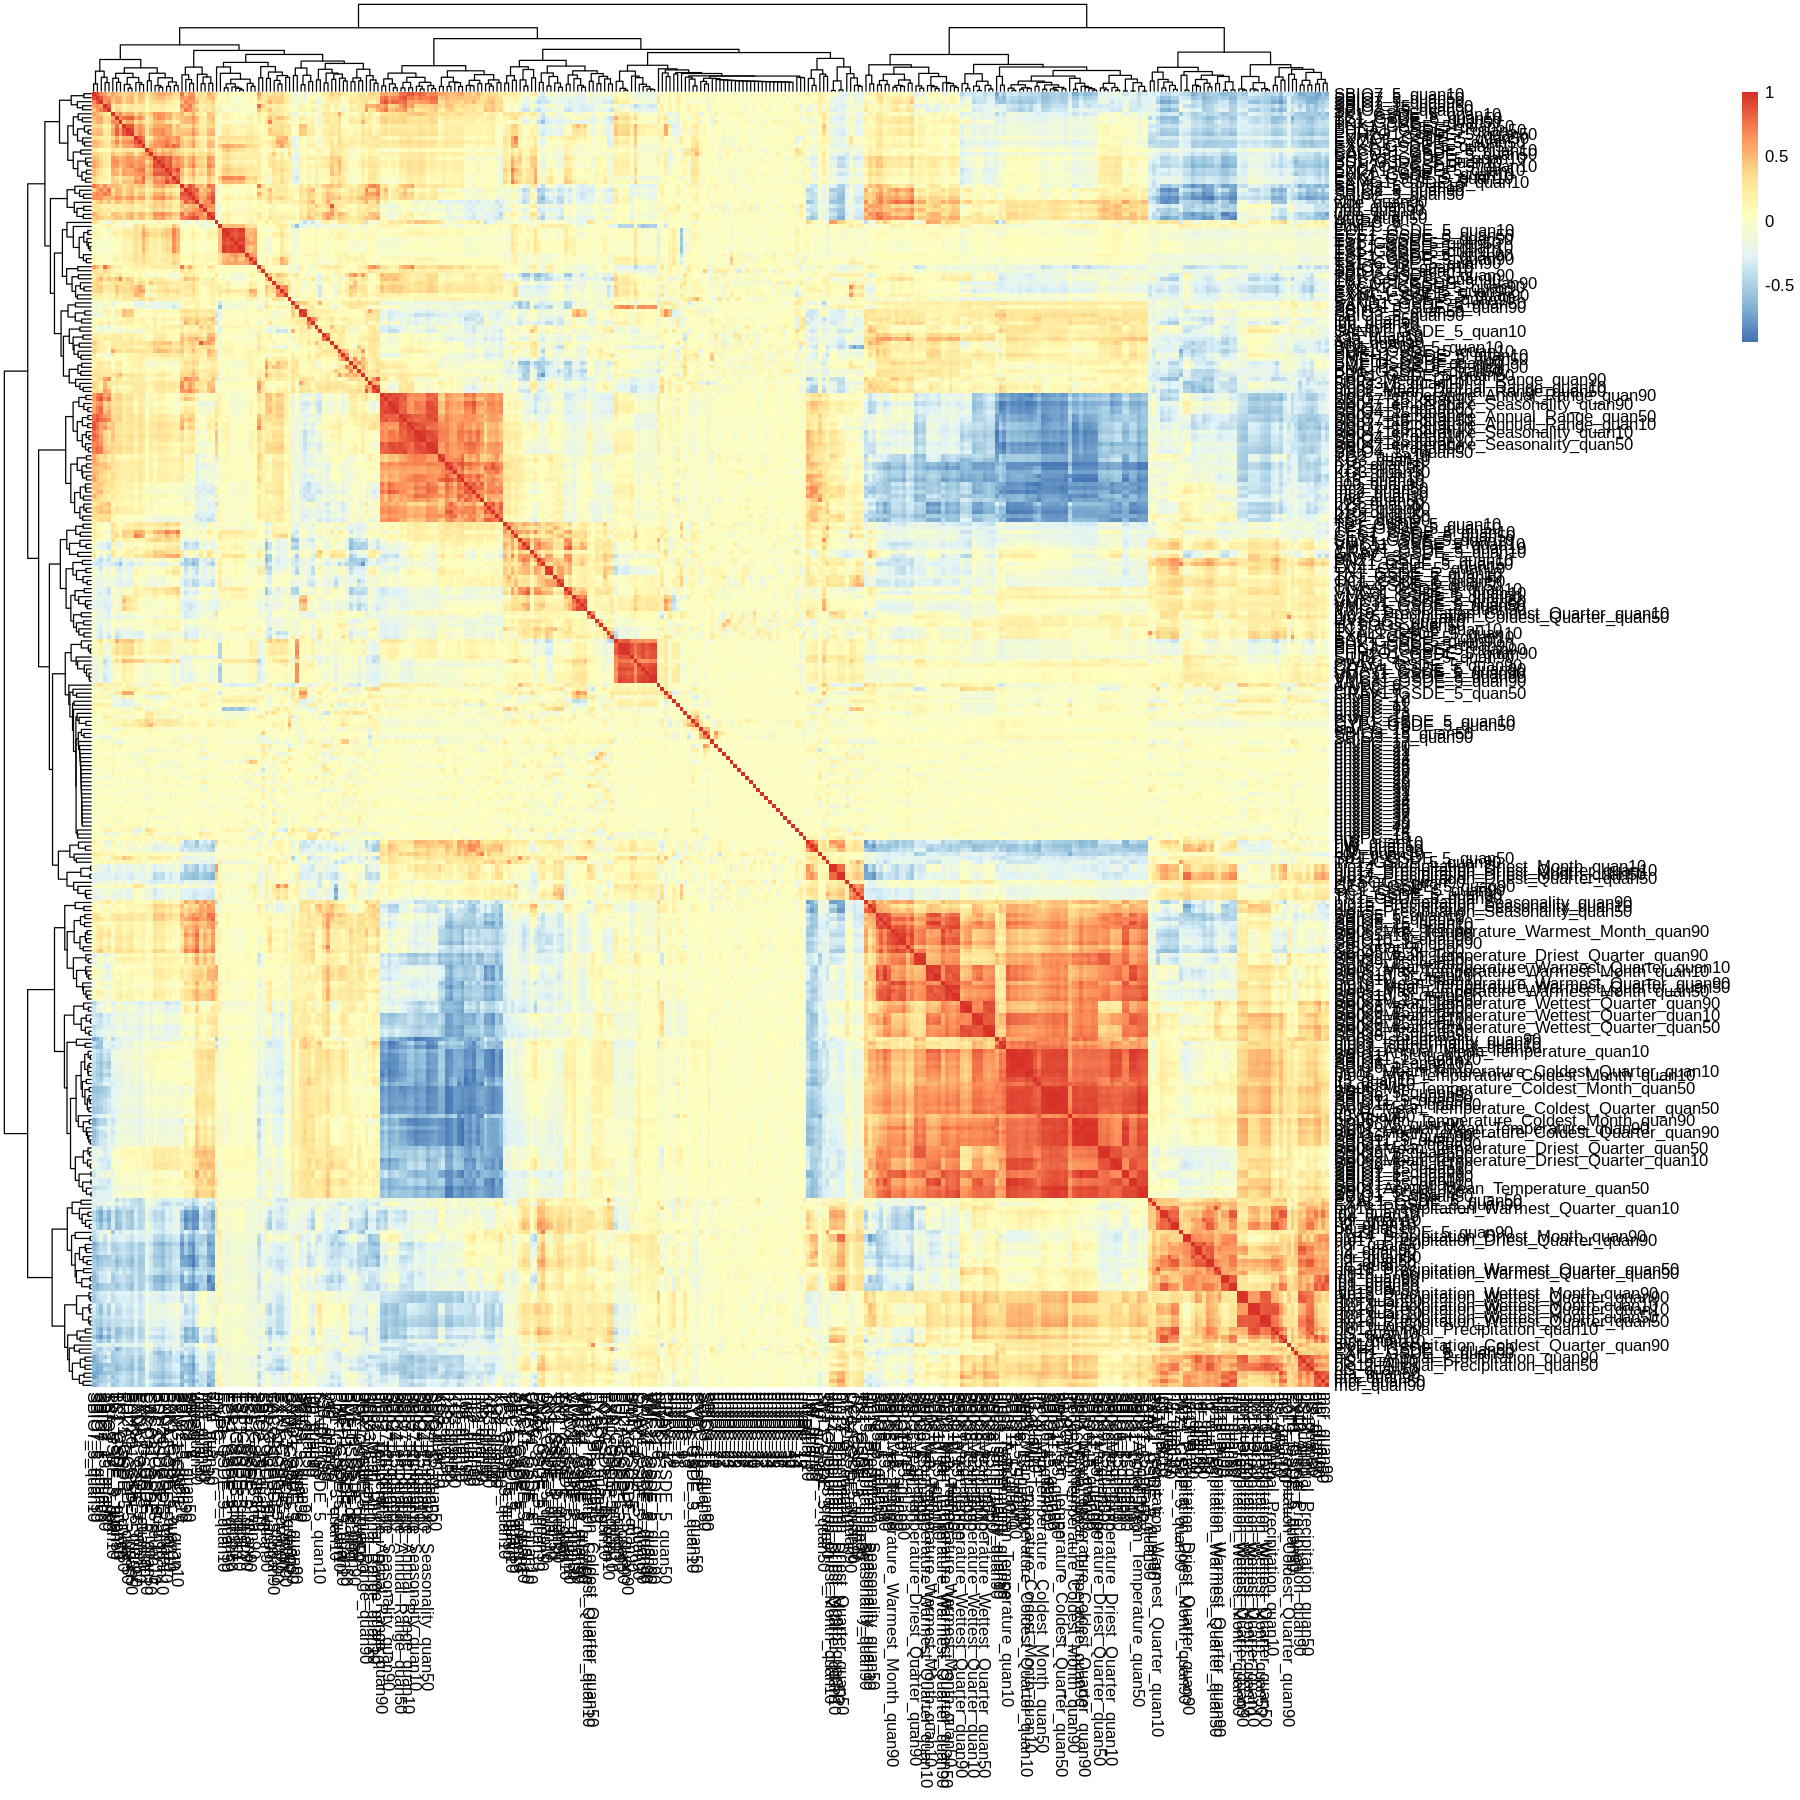

In [363]:
options(repr.plot.width = 15,repr.plot.height = 15)
pheatmap(corMat)

In [367]:
pheatmap(corMat,filename = "/workdir/sh2246/p_phyloGWAS/output/corMat_env.png",width = 30,height = 30,units = "cm",res = 600,border_color = NA,fontsize_row = 6,fontsize_col = 6)

In [369]:
pheatmap(corMat2,filename = "/workdir/sh2246/p_phyloGWAS/output/corMat2_env.png",width = 30,height = 30,units = "cm",res = 600,border_color = NA,fontsize_row = 6,fontsize_col = 6)

In [372]:
annot_labels = data.frame(categories = c(rep(env_metadata[,3],each = 3),rep("envPC",40)))
rownames(annot_labels) = c(paste(rep(env_metadata[,1],each = 3),c("quan10","quan50","quan90"),sep = "_"),paste0("envPC_",1:40))

In [384]:
annot_colors = list(categories = c(combined = "grey", 
                                   envPC = "purple", 
                                   growth = "forestgreen",
                                   precipitation = "cyan",
                                   soil_feature = "peru",
                                   soil_temperature = "salmon",
                                   temperature = "brown"))

In [387]:
pheatmap(corMat2,border_color = NA,fontsize_row = 4,fontsize_col = 4,annotation_row = annot_labels,
         annotation_col = annot_labels,annotation_colors = annot_colors,
         filename = "/workdir/sh2246/p_phyloGWAS/output/corMat2_env_labeled.png",width = 20,height = 20,units = "cm",res = 600)

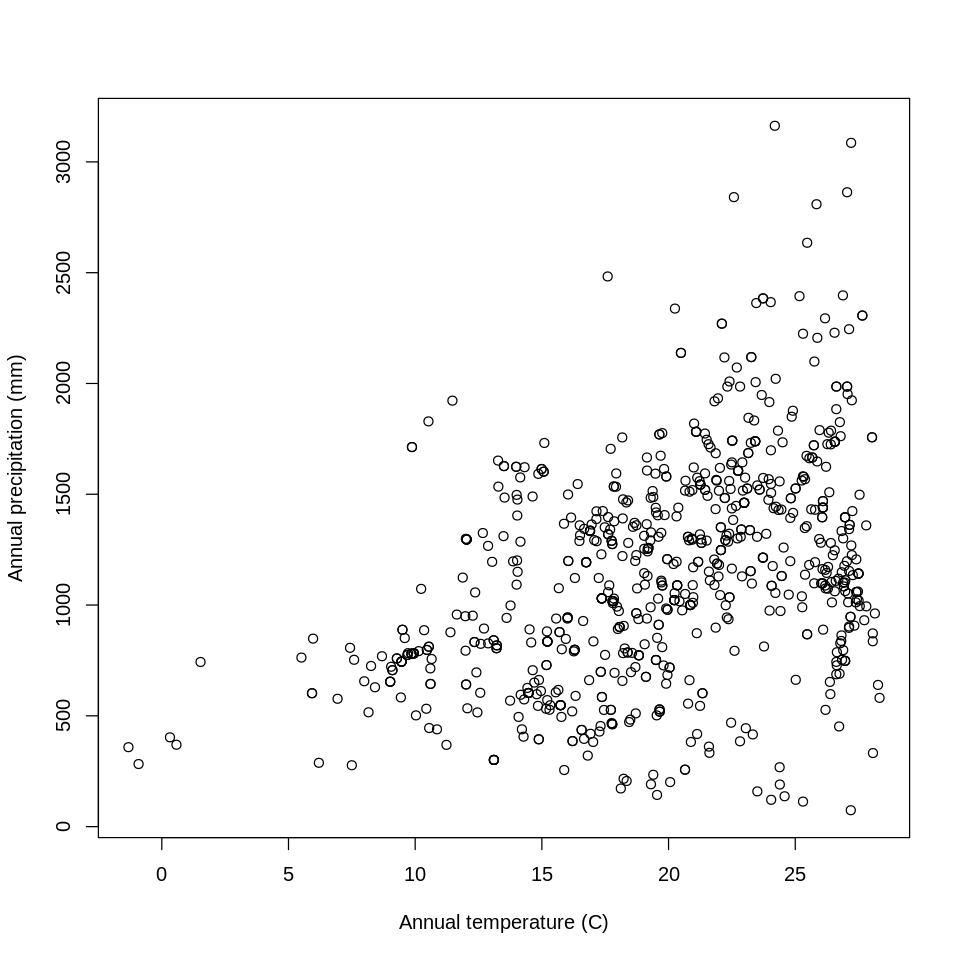

In [389]:
options(repr.plot.width = 8,repr.plot.height = 8)
plot(eTraits_filtered$bio01_Annual_Mean_Temperature_quan50,eTraits_filtered$bio12_Annual_Precipitation_quan50,
     xlab = "Annual temperature (C)",ylab = "Annual precipitation (mm)",pch = 19 ,col = )

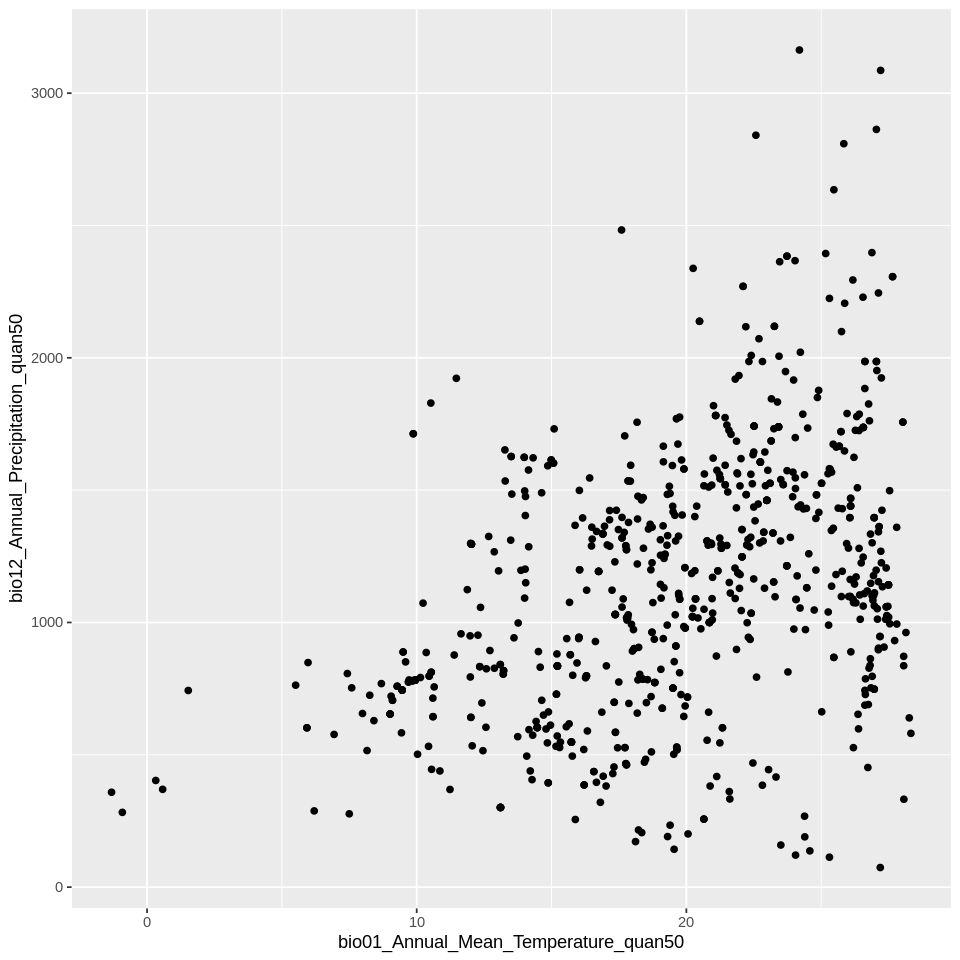

In [414]:
ggplot(eTraits_filtered, aes(x = bio01_Annual_Mean_Temperature_quan50, 
                             y = bio12_Annual_Precipitation_quan50)) +
  geom_point()

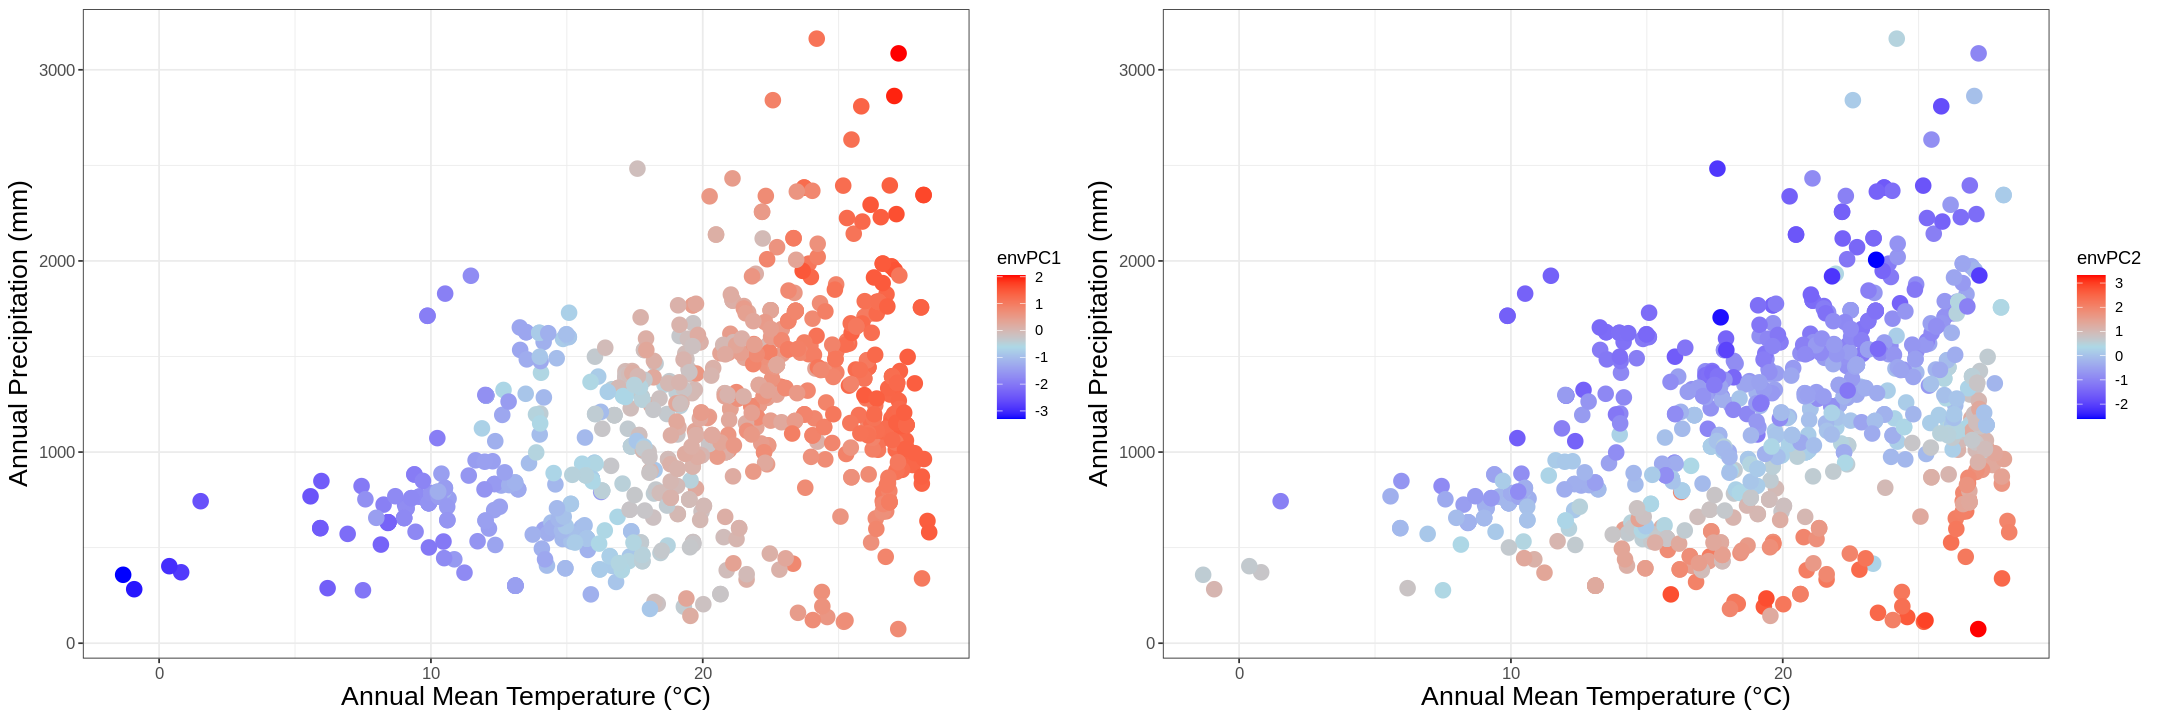

In [314]:
library(gridExtra)
options(repr.plot.width = 18,repr.plot.height = 6)
p1 = ggplot(eTraits_filtered, aes(x = bio01_Annual_Mean_Temperature_quan50, 
                             y = bio12_Annual_Precipitation_quan50, colour = envPC_1)) +
    geom_point(size = 4)+
    xlab("Annual Mean Temperature (\u00B0C)")+
    ylab("Annual Precipitation (mm)")+
    scale_color_gradientn(colors = c("blue","lightblue","red"),name = "envPC1")+
    theme_bw()+
    theme(axis.title = element_text(size = 16),axis.text = element_text(size = 10))
p2 = ggplot(eTraits_filtered, aes(x = bio01_Annual_Mean_Temperature_quan50, 
                             y = bio12_Annual_Precipitation_quan50, colour = envPC_2)) +
    geom_point(size = 4)+
    xlab("Annual Mean Temperature (\u00B0C)")+
    ylab("Annual Precipitation (mm)")+
    scale_color_gradientn(colors = c("blue","lightblue","red"),name = "envPC2")+
    theme_bw()+
    theme(axis.title = element_text(size = 16),axis.text = element_text(size = 10))
grid.arrange(p1, p2, nrow = 1)

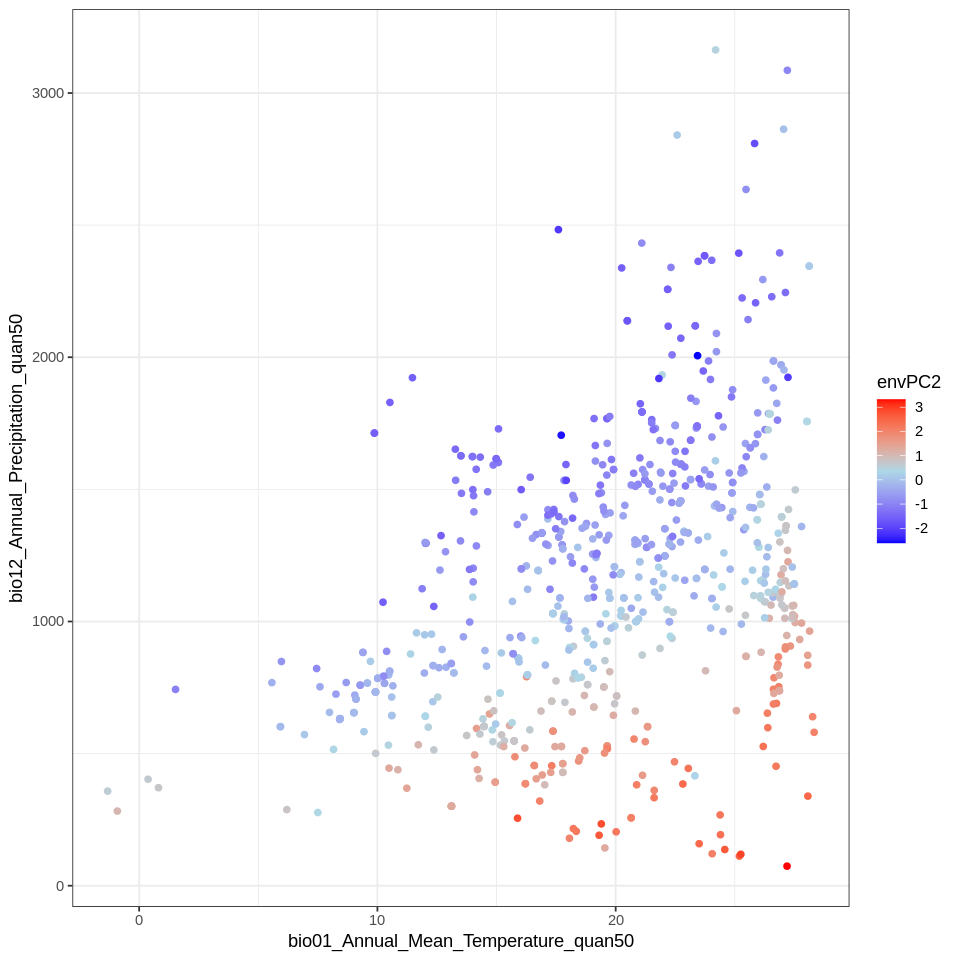

In [295]:
ggplot(eTraits_filtered, aes(x = bio01_Annual_Mean_Temperature_quan50, 
                             y = bio12_Annual_Precipitation_quan50, colour = envPC_2)) +
    geom_point()+
    xlab("Annual Mean Temperature (\u00B0C)")+
    ylab("Annual Precipitation (mm)")+
    scale_color_gradientn(colors = c("blue","lightblue","red"),name = "envPC2")+
    theme_bw()

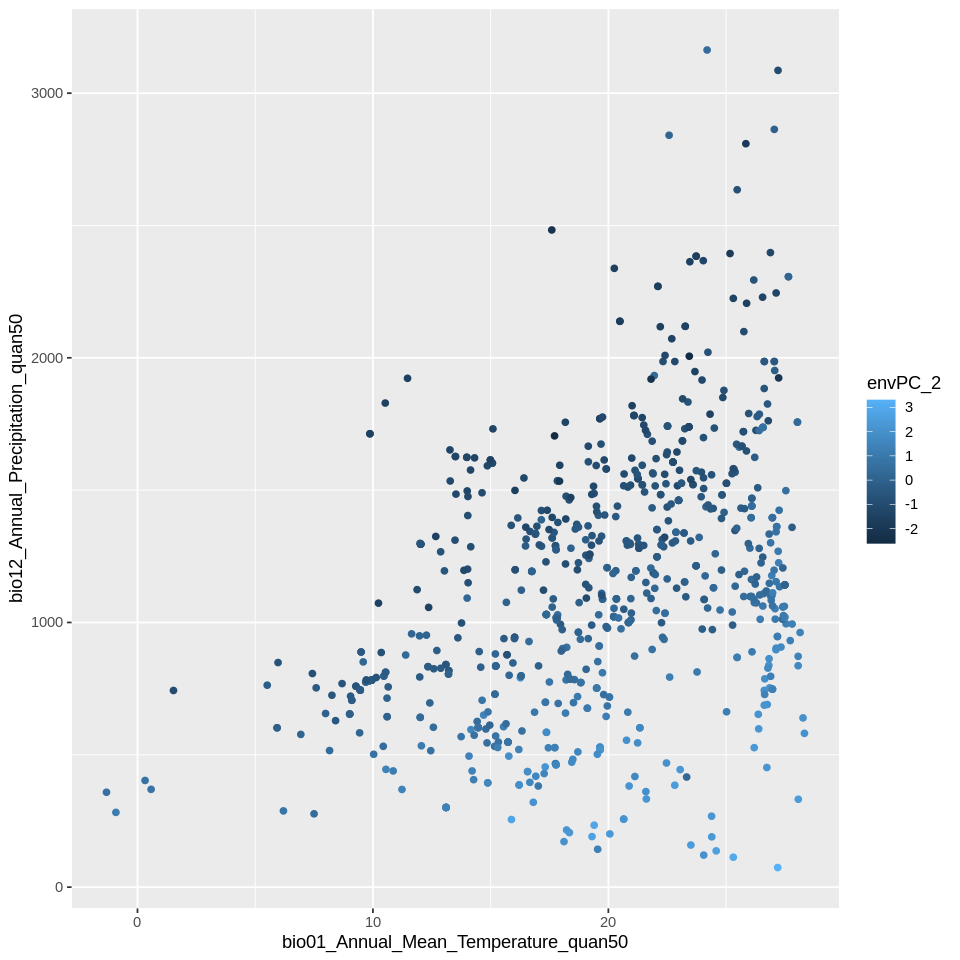

In [399]:
ggplot(eTraits_filtered, aes(x = bio01_Annual_Mean_Temperature_quan50, 
                             y = bio12_Annual_Precipitation_quan50, colour = envPC_2)) +
  geom_point()

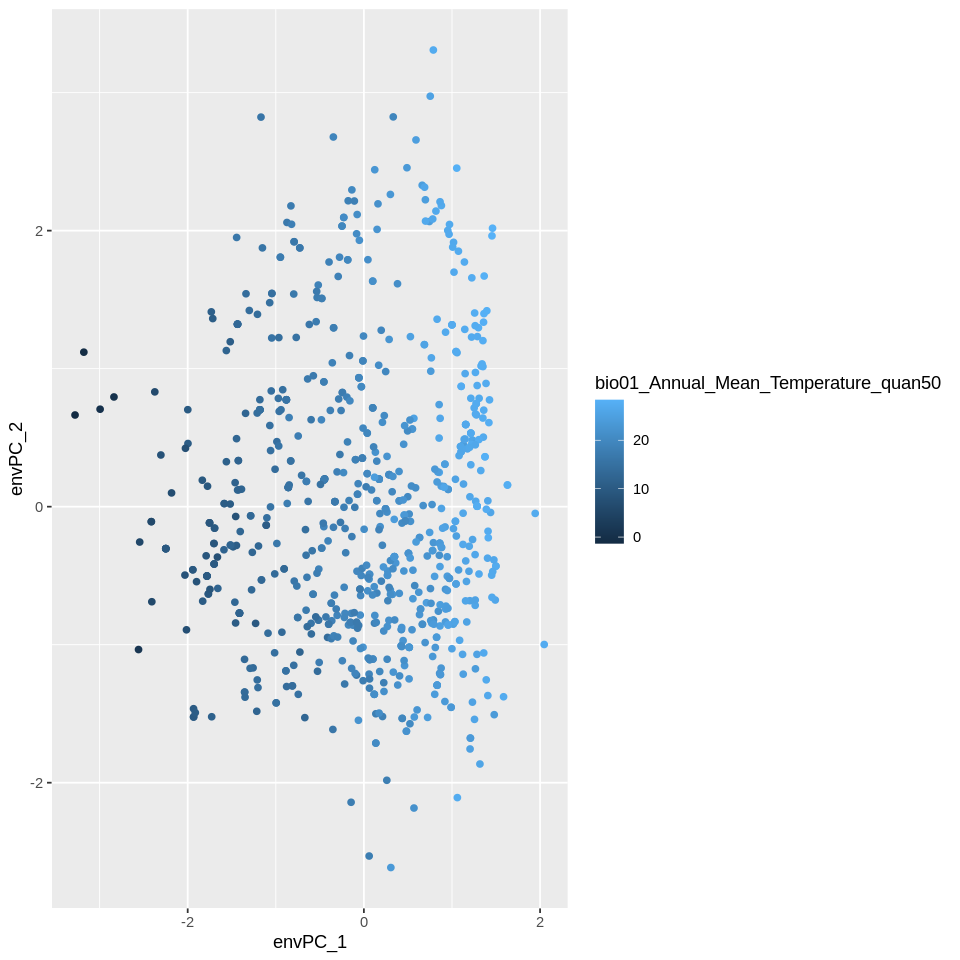

In [394]:
ggplot(eTraits_filtered, aes(x = envPC_1, 
                             y = envPC_2, colour = bio01_Annual_Mean_Temperature_quan50)) +
  geom_point()

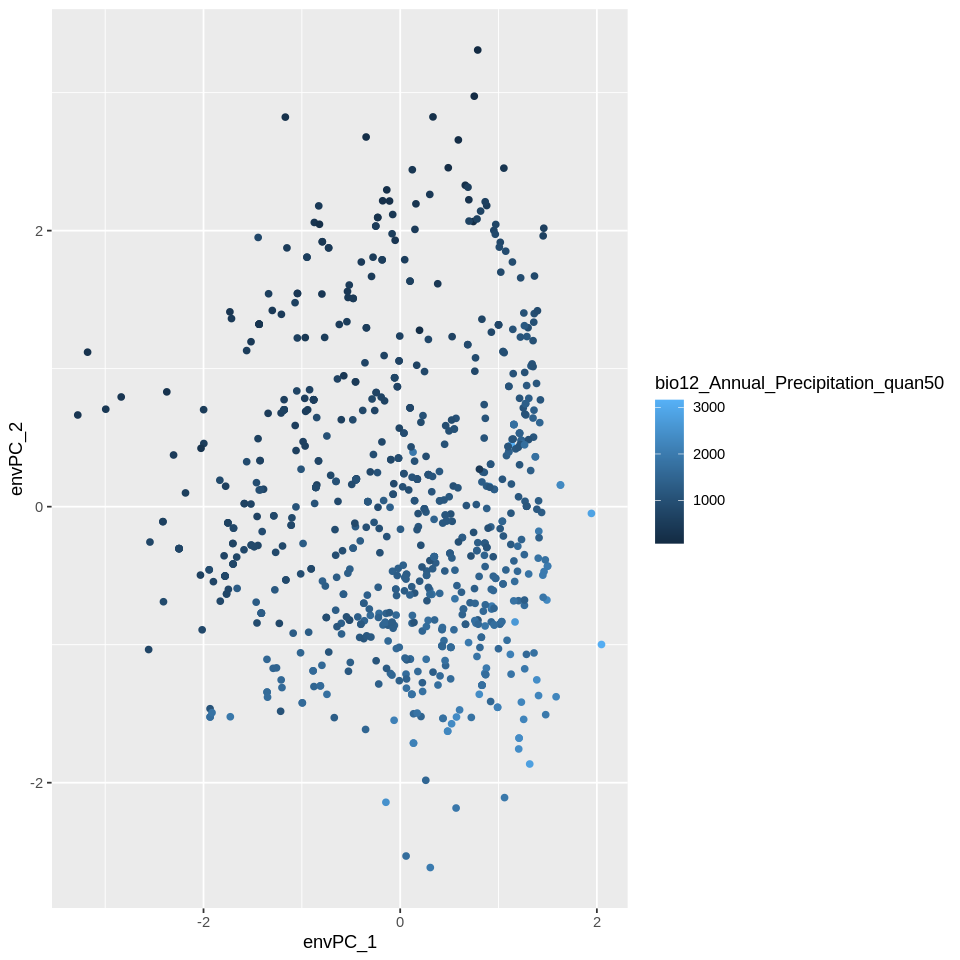

In [395]:
ggplot(eTraits_filtered, aes(x = envPC_1, 
                             y = envPC_2, colour = bio12_Annual_Precipitation_quan50)) +
  geom_point()

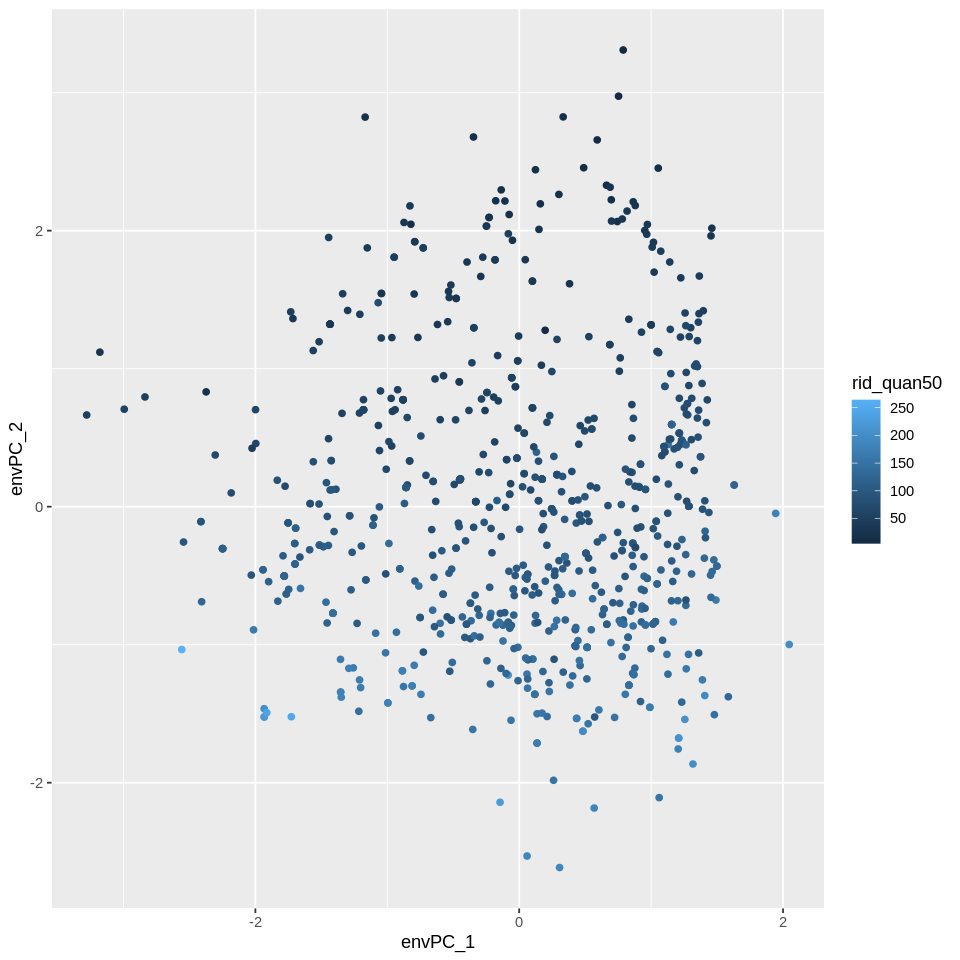

In [397]:
ggplot(eTraits_filtered, aes(x = envPC_1, 
                             y = envPC_2, colour = rid_quan50)) +
  geom_point()

In [295]:
colnames(eTraits_filtered)

[1] "bio01_Annual_Mean_Temperature_quan10"         
  [2] "bio01_Annual_Mean_Temperature_quan50"         
  [3] "bio01_Annual_Mean_Temperature_quan90"         
  [4] "bio10_Mean_Temperature_Warmest_Quarter_quan10"
  [5] "bio10_Mean_Temperature_Warmest_Quarter_quan50"
  [6] "bio10_Mean_Temperature_Warmest_Quarter_quan90"
  [7] "bio11_Mean_Temperature_Coldest_Quarter_quan10"
  [8] "bio11_Mean_Temperature_Coldest_Quarter_quan50"
  [9] "bio11_Mean_Temperature_Coldest_Quarter_quan90"
 [10] "bio12_Annual_Precipitation_quan10"            
 [11] "bio12_Annual_Precipitation_quan50"            
 [12] "bio12_Annual_Precipitation_quan90"            
 [13] "bio13_Precipitation_Wettest_Month_quan10"     
 [14] "bio13_Precipitation_Wettest_Month_quan50"     
 [15] "bio13_Precipitation_Wettest_Month_quan90"     
 [16] "bio14_Precipitation_Driest_Month_quan10"      
 [17] "bio14_Precipitation_Driest_Month_quan50"      
 [18] "bio14_Precipitation_Driest_Month_quan90"      
 [19] "bio15_Precipitation_Seasonality_quan10"       
 [20] "bio15_Precipitation_Seasonality_quan50"       
 [21] "bio15_Precipitation_Seasonality_quan90"       
 [22] "bio16_Precipitation_Wettest_Quarter_quan10"   
 [23] "bio16_Precipitation_Wettest_Quarter_quan50"   
 [24] "bio16_Precipitation_Wettest_Quarter_quan90"   
 [25] "bio17_Precipitation_Driest_Quarter_quan10"    
 [26] "bio17_Precipitation_Driest_Quarter_quan50"    
 [27] "bio17_Precipitation_Driest_Quarter_quan90"    
 [28] "bio18_Precipitation_Warmest_Quarter_quan10"   
 [29] "bio18_Precipitation_Warmest_Quarter_quan50"   
 [30] "bio18_Precipitation_Warmest_Quarter_quan90"   
 [31] "bio19_Precipitation_Coldest_Quarter_quan10"   
 [32] "bio19_Precipitation_Coldest_Quarter_quan50"   
 [33] "bio19_Precipitation_Coldest_Quarter_quan90"   
 [34] "bio02_Mean_Diurnal_Range_quan10"              
 [35] "bio02_Mean_Diurnal_Range_quan50"              
 [36] "bio02_Mean_Diurnal_Range_quan90"              
 [37] "bio03_Isothermality_quan10"                   
 [38] "bio03_Isothermality_quan50"                   
 [39] "bio03_Isothermality_quan90"                   
 [40] "bio04_Temperature_Seasonality_quan10"         
 [41] "bio04_Temperature_Seasonality_quan50"         
 [42] "bio04_Temperature_Seasonality_quan90"         
 [43] "bio05_Max_Temperature_Warmest_Month_quan10"   
 [44] "bio05_Max_Temperature_Warmest_Month_quan50"   
 [45] "bio05_Max_Temperature_Warmest_Month_quan90"   
 [46] "bio06_Min_Temperature_Coldest_Month_quan10"   
 [47] "bio06_Min_Temperature_Coldest_Month_quan50"   
 [48] "bio06_Min_Temperature_Coldest_Month_quan90"   
 [49] "bio07_Temperature_Annual_Range_quan10"        
 [50] "bio07_Temperature_Annual_Range_quan50"        
 [51] "bio07_Temperature_Annual_Range_quan90"        
 [52] "bio08_Mean_Temperature_Wettest_Quarter_quan10"
 [53] "bio08_Mean_Temperature_Wettest_Quarter_quan50"
 [54] "bio08_Mean_Temperature_Wettest_Quarter_quan90"
 [55] "bio09_Mean_Temperature_Driest_Quarter_quan10" 
 [56] "bio09_Mean_Temperature_Driest_Quarter_quan50" 
 [57] "bio09_Mean_Temperature_Driest_Quarter_quan90" 
 [58] "HYSOGs_quan10"                                
 [59] "HYSOGs_quan50"                                
 [60] "HYSOGs_quan90"                                
 [61] "eta_quan10"                                   
 [62] "eta_quan50"                                   
 [63] "eta_quan90"                                   
 [64] "KG2_quan10"                                   
 [65] "KG2_quan50"                                   
 [66] "KG2_quan90"                                   
 [67] "KG3_quan10"                                   
 [68] "KG3_quan50"                                   
 [69] "KG3_quan90"                                   
 [70] "ld1_quan10"                                   
 [71] "ld1_quan50"                                   
 [72] "ld1_quan90"                                   
 [73] "lgb_quan10"                                   
 [74] "lgb_quan50"                                   
 [75] 

In [201]:
tmp$estimate

cor 
0.05590863

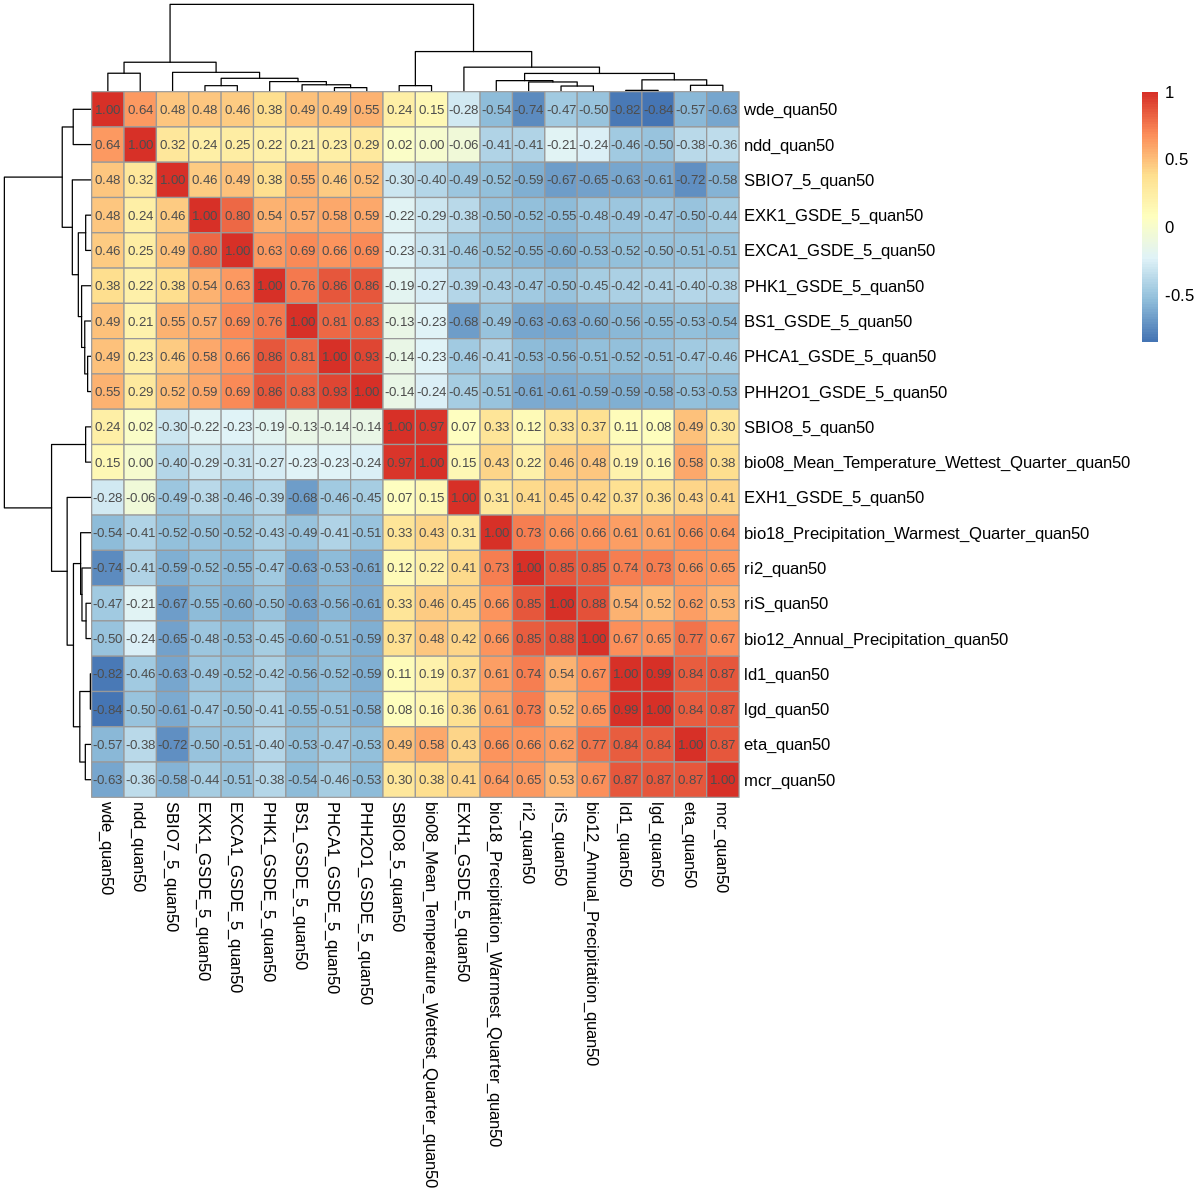

In [236]:
pheatmap(cor(eTraits_filtered[,paste0(names(tail(sort(corRes[,1]^2),20)),"_quan50")],use = "complete"),
         display_numbers = T,cluster_rows = T,cluster_cols = T)

Warning message in eval(predvars, data, env):
“NAs introduced by coercion”
Warning message in eval(predvars, data, env):
“NAs introduced by coercion”


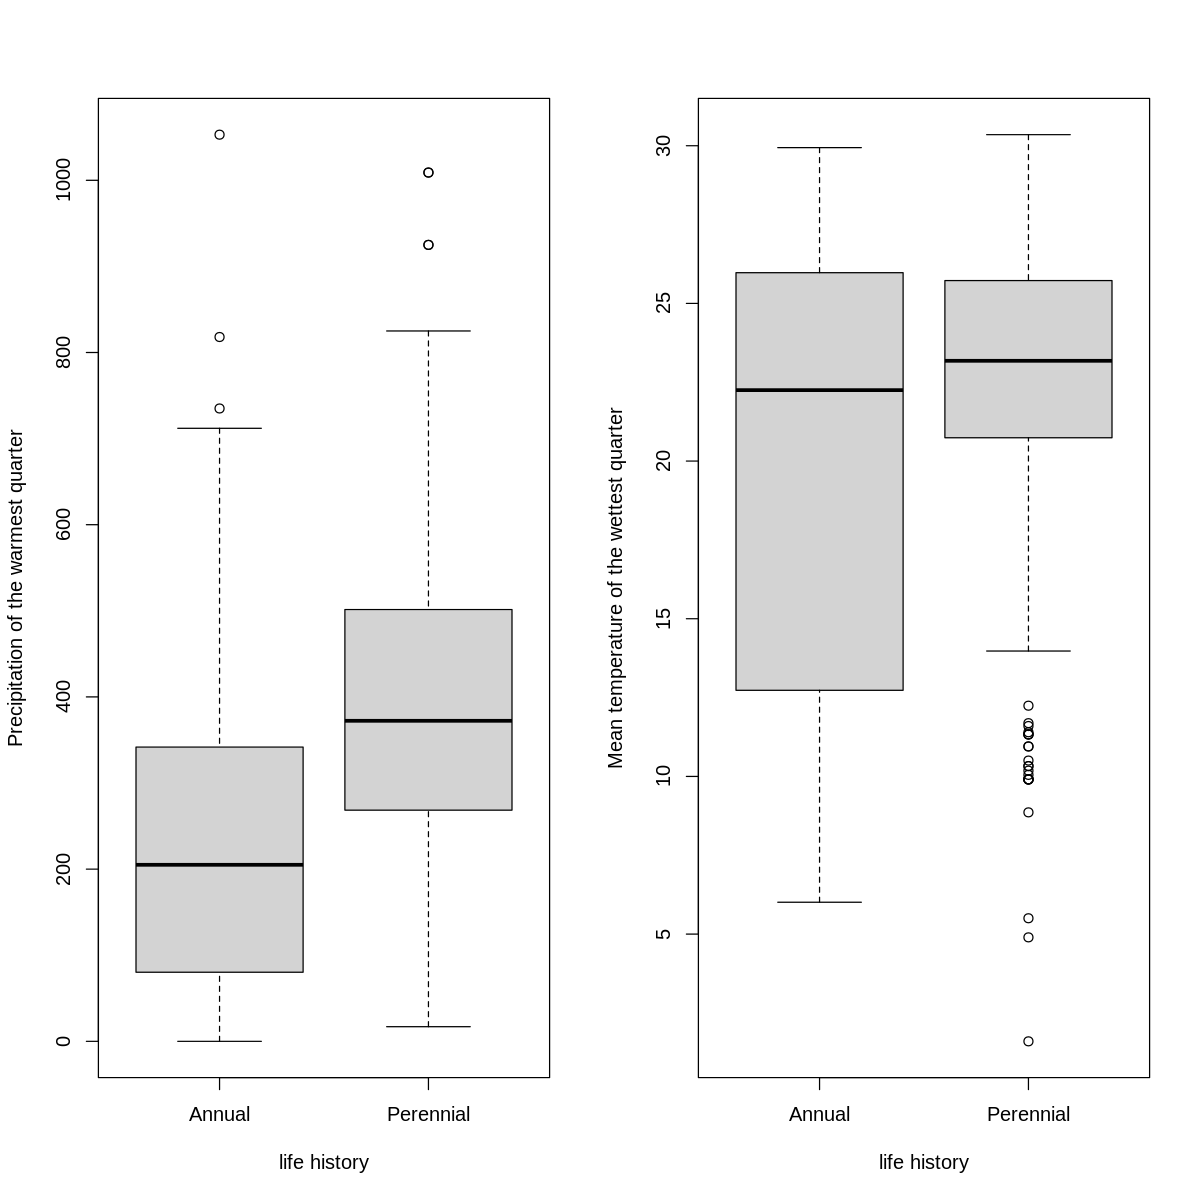

In [247]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(1,2))
boxplot(eTraits_filtered[commonID2,]$bio18_Precipitation_Warmest_Quarter_quan50~as.numeric(traitMat[commonID2,2]),
        names = c("Annual","Perennial"),xlab = "life history",ylab = "Precipitation of the warmest quarter")
boxplot(eTraits_filtered[commonID2,]$bio08_Mean_Temperature_Wettest_Quarter_quan50~as.numeric(traitMat[commonID2,2]),
        names = c("Annual","Perennial"),xlab = "life history",ylab = "Mean temperature of the wettest quarter")


In [124]:
table(as.numeric(traitMat[,2]))

Warning message in table(as.numeric(traitMat[, 2])):
“NAs introduced by coercion”



  1   2 
241 487 

In [260]:
testFile = data.table::fread("/workdir/sh2246/p_phyloGWAS/data/allOGs_withHeaders_dnds.txt",header = F,sep = "\t")

Warning message in data.table::fread("/workdir/sh2246/p_phyloGWAS/data/allOGs_withHeaders_dnds.txt", :
“Previous fread() session was not cleaned up properly. Cleaned up ok at the beginning of this fread() call.”


In [261]:
head(testFile)

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
OG0000508:ASM1935983v1:0,OG0000508:10wheat_assembly_jagger:0,347,343,4,4,0,116.50000,53.50000,243.1667,785.8333,0.4790953,0.06808059,0.1421024,0.7637295,0.07137130,0.09345101,0.9942363
OG0000508:ASM1935983v1:0,OG0000508:10wheat_assembly_jagger:1,347,343,4,4,0,118.50000,56.50000,243.8333,785.1667,0.4859877,0.07195924,0.1480680,0.7830581,0.07564936,0.09660759,0.9942363
OG0000508:ASM1935983v1:0,OG0000508:10wheat_assembly_lancer:0,347,343,4,4,0,117.50000,55.50000,243.5000,785.5000,0.4825462,0.07065563,0.1464225,0.7733448,0.07420878,0.09595821,0.9942363
OG0000508:ASM1935983v1:0,OG0000508:10wheat_assembly_stanley:0,347,343,4,4,0,116.50000,53.50000,243.1667,785.8333,0.4790953,0.06808059,0.1421024,0.7637295,0.07137130,0.09345101,0.9942363
OG0000508:ASM1935983v1:0,OG0000508:10wheat_assembly_stanley:1,347,343,4,4,0,117.50000,55.50000,243.5000,785.5000,0.4825462,0.07065563,0.1464225,0.7733448,0.07420878,0.09595821,0.9942363
OG0000508:ASM1935983v1:0,OG0000508:4AgS:0,347,336,11,11,0,77.33333,98.66667,128.8333,879.1667,0.6002587,0.11222749,0.1869652,1.2083732,0.12156866,0.10060523,0.5331412


In [262]:
hist(table(strsplit2(testFile[,1],":")[,1]))

In [265]:
numSeqPerOG = read.table("/workdir/sh2246/p_phyloGWAS/output/numSeq_allOG.txt",header = T)

In [267]:
dim(numSeqPerOG)

[1] 17886     2

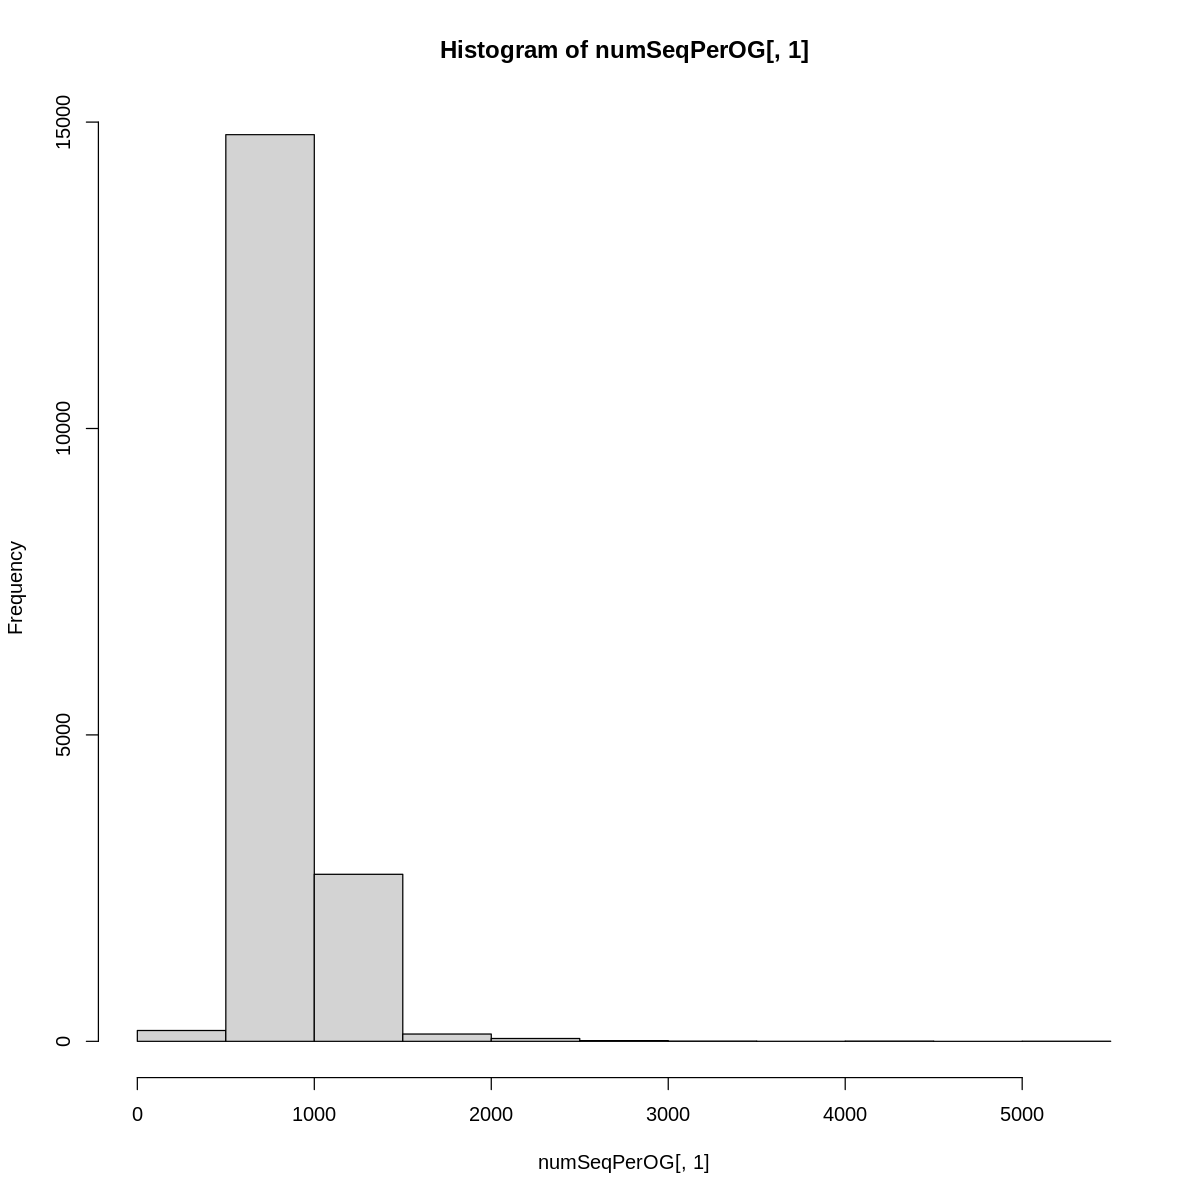

In [269]:
hist(numSeqPerOG[,1])

In [282]:
numTaxaPerOG = read.table("/workdir/sh2246/p_phyloGWAS/output/numTaxa_allOG.txt",header = F)

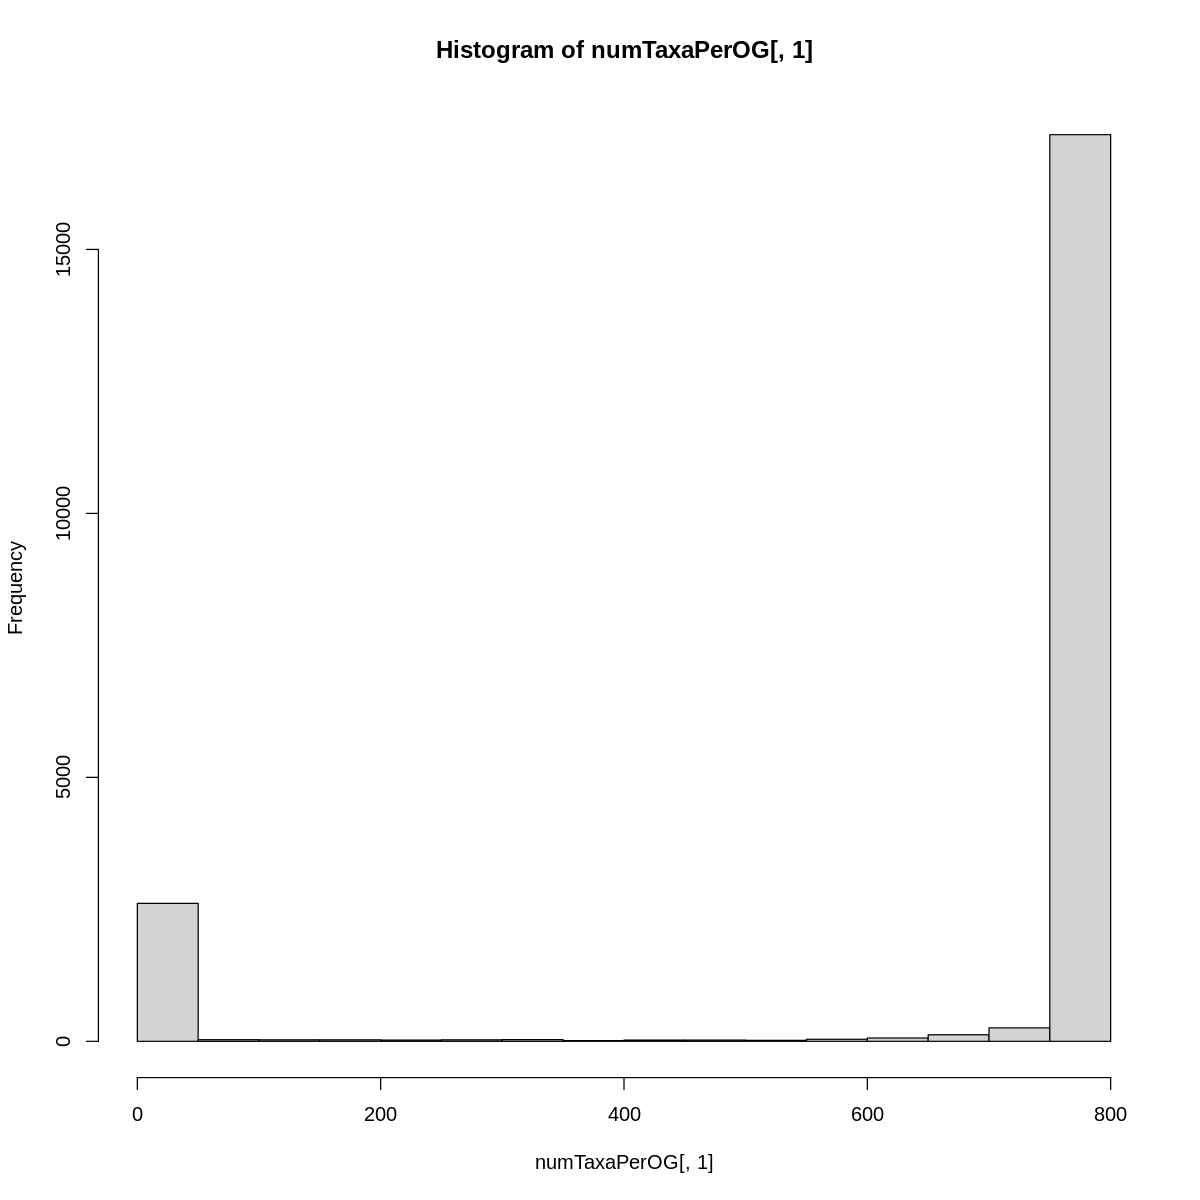

In [289]:
hist(numTaxaPerOG[,1],breaks = seq(0,800,50))

In [288]:
table(grepl("_R",numTaxaPerOG[numTaxaPerOG[,1]<50,2]))


FALSE  TRUE 
   34  2574 

In [291]:
numTaxaPerOG[numTaxaPerOG[,1]<50,]

,V1,V2
,<int>,<chr>
7760,12,OG0011273
9857,6,OG0013549
12291,8,OG0016209
14359,37,OG0018584
14616,16,OG0018913
14816,7,OG0019169
15130,19,OG0019703
15357,8,OG0020214
15384,12,OG0020251


In [86]:
setdiff(spTre.rooted$tip.label,rownames(ePCs$environmental.features))
length(setdiff(spTre.rooted$tip.label,rownames(ePCs$environmental.features)))

[1] "SRR23019235"                      "MCRTL028"                        
 [3] "AN21TSTL0183"                     "AN21TNTL0173"                    
 [5] "ASM3693692v1"                     "AN21TS37"                        
 [7] "AN21TS05"                         "MCRTL024"                        
 [9] "Zh-RIMHU001-REFERENCE-PanAnd-1.0" "Tz-DC_05_58_3A-DRAFT-PanAnd-1.0" 
[11] "AN21TSTL0206"                     "AN21TS44"                        
[13] "AN21TNTL0176"                     "AN21TS41"                        
[15] "AN21TNTL0138"                     "AN21TNTL0139"                    
[17] "AN22TNTL036"                      "AN22TSTL001"                     
[19] "AN21TSTL0205"                     "SRR20072574"                     
[21] "AN21TNTL0362"                     "AN21TNTL0178"                    
[23] "AN22TNTL165"                      "AN20T193"                        
[25] "AN22TNTL031"                      "AT20TS1MCRTL004"                 
[27] "AN22TNTL150"                      "AN21TSTL0215"                    
[29] "AN21TSTL0279"                     "AN21TSTL0036"                    
[31] "MCRTL047"                         "AN22TNTL117"                     
[33] "AN20T004"                         "AN21TS39"                        
[35] "MCRTL045"                         "AN20T021"                        
[37] "AN20T169"                         "AN21TSTL0186"                    
[39] "AN21TSTL0250"                     "AN22TNTL113"                     
[41] "AN22TNTL122"                      "Oryza_malampuzhaensis"           
[43] "SRR18907695"

[1] 43

In [62]:
setdiff(spTre.rooted$tip.label,rownames(ePCs$environmental.features))

[1] "SRR23019235"                          
 [2] "MCRTL028"                             
 [3] "AN21TSTL0183"                         
 [4] "AN21TNTL0173"                         
 [5] "ASM3693692v1"                         
 [6] "AN21TS37"                             
 [7] "Rt-Layton_Zhong169-DRAFT-PanAnd-1.0"  
 [8] "A1015002"                             
 [9] "Hp-KelloggPI404118-DRAFT-PanAnd-1.0"  
[10] "AN21TS05"                             
[11] "Et-Layton_Zhong168-DRAFT-PanAnd-1.0"  
[12] "MCRTL024"                             
[13] "Zv-TIL01-REFERENCE-PanAnd-1.0"        
[14] "Zv-TIL11-REFERENCE-PanAnd-1.0"        
[15] "Zh-RIMHU001-REFERENCE-PanAnd-1.0"     
[16] "Tz-DC_05_58_3A-DRAFT-PanAnd-1.0"      
[17] "AN21TSTL0206"                         
[18] "Td-FL_9056069_6-REFERENCE-PanAnd-2.0b"
[19] "Td-FL_9056069_6-REFERENCE-PanAnd-2.0a"
[20] "Td-KS_B6_1-REFERENCE-PanAnd-2.0b"     
[21] "Td-KS_B6_1-REFERENCE-PanAnd-2.0a"     
[22] "Td-McKain334_5-DRAFT-PanAnd-1.0"      
[23] "Rr-Malcomber3106-DRAFT-PanAnd-1.0"    
[24] "Vc-Pasquet1098-DRAFT-PanAnd-1.0"      
[25] "A1077002"                             
[26] "Ud-Pasquet1171-DRAFT-PanAnd-1.0"      
[27] "A1076001"                             
[28] "A1014002"                             
[29] "ChrysopogonNigritanus_v1.0"           
[30] "Te-Pasquet1246-DRAFT-PanAnd-1.0"      
[31] "AN21TS44"                             
[32] "Ab-Traiperm_572-DRAFT-PanAnd-1.0"     
[33] "AN21TNTL0176"                         
[34] "Sn-CAM1369-DRAFT-PanAnd-1.0"          
[35] "AN21TS41"                             
[36] "A1030002"                             
[37] "Ir-Pasquet1136-DRAFT-PanAnd-1.0"      
[38] "AN21TNTL0138"                         
[39] "AN21TNTL0139"                         
[40] "AN22TNTL036"                          
[41] "AN22TSTL001"                          
[42] "AN21TSTL0205"                         
[43] "SRR20072574"                          
[44] "A1031001"                             
[45] "A1033002"                             
[46] "AN21TNTL0362"                         
[47] "AN21TNTL0178"                         
[48] "AN22TNTL165"                          
[49] "AN20T025"                             
[50] "AN20T023"                             
[51] "AN20T024"                             
[52] "AN20T193"                             
[53] "AN22TNTL031"                          
[54] "Pi-Clark-DRAFT-PanAnd-1.0"            
[55] "A1063002"                             
[56] "AT20TS1MCRTL004"                      
[57] "AN22TNTL150"                          
[58] "AN21TSTL0215"                         
[59] "Bl-K1279B-DRAFT-PanAnd-1.0"           
[60] "AN21TSTL0279"                         
[61] "A1020001"                             
[62] "A1021002"                             
[63] "A1010002"                             
[64] "AN21TSTL0036"                         
[65] "Cr-AUB069-DRAFT-PanAnd-1.0"           
[66] "MCRTL047"                             
[67] "AN22TNTL117"                          
[68] "AN20T004"                             
[69] "AN21TS39"                             
[70] "Av-Kellogg1287_8-REFERENCE-PanAnd-1.0"
[71] "MCRTL045"                             
[72] "AN20T021"                             
[73] "AN20T169"                             
[74] "AN21TSTL0186"                         
[75] "Ss-CAM1384-DRAFT-PanAnd-1.0"          
[76] "AN21TSTL0250"                         
[77] "AN22TNTL113"                          
[78] "Ac-Pasquet1232-DRAFT-PanAnd-1.0"      
[79] "Ag-CAM1351-DRAFT-PanAnd-1.0"          
[80] "AN22TNTL122"                          
[81] "Oryza_malampuzhaensis"                
[82] "SRR18907695"

In [64]:
metadata3 = metadata[metadata[,1]%in%setdiff(spTre.rooted$tip.label,rownames(ePCs$environmental.features)),]

In [66]:
metadata3 = metadata3[!metadata3[,2]%in%c("Unknown","Omit","Hyparrhenia sp.","Andropogon sp."),]

,assemblyID,latest_name,spTaxa
,<chr>,<chr>,<chr>
36,MCRTL045,"""Andropogon"" appendiculatus","MCRTL045:""Andropogon"" appendiculatus"
39,AN22TNTL031,Andropogon aridus,AN22TNTL031:Andropogon aridus
45,AN22TNTL113,"""Andropogon"" brazzae","AN22TNTL113:""Andropogon"" brazzae"
46,Ab-Traiperm_572-DRAFT-PanAnd-1.0,Andropogon burmanicus,Ab-Traiperm_572-DRAFT-PanAnd-1.0:Andropogon burmanicus
50,Ac-Pasquet1232-DRAFT-PanAnd-1.0,Andropogon chinensis,Ac-Pasquet1232-DRAFT-PanAnd-1.0:Andropogon chinensis
56,AN22TNTL122,"""Andropogon"" durifolius","AN22TNTL122:""Andropogon"" durifolius"
57,AN20T169,Anatherum eucomum subsp. huillense,AN20T169:Anatherum eucomum subsp. huillense
58,AN20T021,Anatherum eucomum subsp. huillense,AN20T021:Anatherum eucomum subsp. huillense
64,Ag-CAM1351-DRAFT-PanAnd-1.0,Andropogon gerardii,Ag-CAM1351-DRAFT-PanAnd-1.0:Andropogon gerardii


In [72]:
metadata3[,2] = gsub("\"","", metadata3[,2])
metadata3

,assemblyID,latest_name,spTaxa
,<chr>,<chr>,<chr>
36,MCRTL045,Andropogon appendiculatus,"MCRTL045:""Andropogon"" appendiculatus"
39,AN22TNTL031,Andropogon aridus,AN22TNTL031:Andropogon aridus
45,AN22TNTL113,Andropogon brazzae,"AN22TNTL113:""Andropogon"" brazzae"
46,Ab-Traiperm_572-DRAFT-PanAnd-1.0,Andropogon burmanicus,Ab-Traiperm_572-DRAFT-PanAnd-1.0:Andropogon burmanicus
50,Ac-Pasquet1232-DRAFT-PanAnd-1.0,Andropogon chinensis,Ac-Pasquet1232-DRAFT-PanAnd-1.0:Andropogon chinensis
56,AN22TNTL122,Andropogon durifolius,"AN22TNTL122:""Andropogon"" durifolius"
57,AN20T169,Anatherum eucomum subsp. huillense,AN20T169:Anatherum eucomum subsp. huillense
58,AN20T021,Anatherum eucomum subsp. huillense,AN20T021:Anatherum eucomum subsp. huillense
64,Ag-CAM1351-DRAFT-PanAnd-1.0,Andropogon gerardii,Ag-CAM1351-DRAFT-PanAnd-1.0:Andropogon gerardii


In [73]:
metadata3 = data.frame(names = metadata3[,2],latest_name = metadata3[,2])

In [74]:
write.table(metadata3,"/workdir/sh2246/p_phyloGWAS/output/testMetadata3.txt",col.names = T,row.names = F,sep = "\t",quote = F)